
 Project: South Australia Road Crash Severity Classification

This notebook is aligned with the assessment criteria:

1. **Data enrichment and feature engineering (LO4, LO5)**
2. **Exploratory data analysis (LO1, LO3)**
3. **Building classifiers and optimisation (LO1, LO3, LO4, LO5)**
4. **Model evaluation and discussion (LO1, LO2)**
5. **Professional report writing outputs (LO6)**

Main classification target: **CSEF Severity**.

In [2]:
# ============================================================
# Cell 0: Project setup and supervisor-aligned assessment plan
# ============================================================

PROJECT_TITLE = "South Australia Road Crash Severity Classification"

# Main target variable
TARGET_COL = "csef_severity"

# Reproducibility
RANDOM_STATE = 42

# ------------------------------------------------------------
# Google Colab directory setup
# ------------------------------------------------------------
BASE_DIR = "/content"

DATA_DIR = f"{BASE_DIR}/data"
OUTPUT_DIR = f"{BASE_DIR}/road_crash_outputs"

FIG_DIR = f"{OUTPUT_DIR}/figures"
TABLE_DIR = f"{OUTPUT_DIR}/tables"
REPORT_DIR = f"{OUTPUT_DIR}/report_materials"

# New folders required for supervisor comments
OUTLIER_DIR = f"{OUTPUT_DIR}/outlier_detection"
MODEL_DIR = f"{OUTPUT_DIR}/model_results"
PCA_DIR = f"{OUTPUT_DIR}/pca_analysis"

# ------------------------------------------------------------
# Supervisor requirements to address in the notebook
# ------------------------------------------------------------
supervisor_requirements = {
    "introduction_citations": "Report needs citations for all background statements.",

    "assessment_2_comparison": (
        "Add a section explaining which research questions were already addressed "
        "in Assessment 2 and what is new in this report."
    ),

    "advanced_outlier_detection": (
        "Use Local Outlier Factor and Isolation Forest. "
        "Do not rely only on IQR."
    ),

    "hyperparameter_tuning": (
        "Report the best hyperparameter values for each tuned model."
    ),

    "feature_engineering_detail": (
        "Explain exactly how engineered features are calculated, not only what they mean."
    ),

    "additional_classifiers": (
        "Add Naive Bayes and Support Vector Machine because these were covered in the unit."
    ),

    "pca_standardisation": (
        "Include standardisation and PCA/TruncatedSVD experiment where appropriate."
    ),

    "remove_streamlit_focus": (
        "Do not include Streamlit deployment as a main part of the report. "
        "Keep focus on modelling."
    )
}

# ------------------------------------------------------------
# Notebook-to-report alignment
# ------------------------------------------------------------
assessment_alignment = {
    "Data_loading_and_cleaning": [
        "Load Crash, Units, and Casualty datasets",
        "Standardise column names",
        "Clean special missing values",
        "Convert useful columns to numeric format"
    ],

    "Feature_engineering": [
        "Create temporal features: crash_hour, month_num, season, time_period",
        "Create binary indicators: is_weekend, is_raining, is_wet_road, is_night",
        "Create speed_category",
        "Aggregate Units dataset by report_id",
        "Calculate vehicle and road-user features",
        "Document exact feature calculation rules"
    ],

    "Exploratory_data_analysis": [
        "Analyse crash severity distribution",
        "Analyse temporal, weather, road, and crash-type patterns",
        "Use LOF and Isolation Forest for advanced outlier detection"
    ],

    "Modelling": [
        "Build Dummy Baseline",
        "Build Naive Bayes",
        "Build Logistic Regression",
        "Build Support Vector Machine",
        "Build Decision Tree",
        "Build Random Forest",
        "Build PCA/TruncatedSVD-based model where suitable"
    ],

    "Model_optimisation": [
        "Apply cross-validation",
        "Use GridSearchCV or RandomizedSearchCV",
        "Save best hyperparameters",
        "Compare tuned and untuned models"
    ],

    "Evaluation": [
        "Use accuracy, balanced accuracy, precision, recall, macro F1, weighted F1",
        "Use confusion matrices",
        "Focus on minority classes: Serious Injury and Fatal",
        "Save model comparison tables and figures"
    ],

    "Report_outputs": [
        "Export report-ready tables",
        "Export figures",
        "Export hyperparameter results",
        "Export feature engineering explanation table",
        "Export outlier detection summary"
    ]
}

print("=" * 70)
print(PROJECT_TITLE)
print("=" * 70)
print("Target variable:", TARGET_COL)
print("Random state:", RANDOM_STATE)
print("Running environment: Google Colab")
print("\nMain supervisor-required upgrades:")
for i, key in enumerate(supervisor_requirements.keys(), start=1):
    print(f"{i}. {key}")

print("\nCell 0 completed. Now run Cell 1 for imports and folder creation.")

South Australia Road Crash Severity Classification
Target variable: csef_severity
Random state: 42
Running environment: Google Colab

Main supervisor-required upgrades:
1. introduction_citations
2. assessment_2_comparison
3. advanced_outlier_detection
4. hyperparameter_tuning
5. feature_engineering_detail
6. additional_classifiers
7. pca_standardisation
8. remove_streamlit_focus

Cell 0 completed. Now run Cell 1 for imports and folder creation.


In [3]:
# ============================================================
# Cell 1: Import libraries
# Google Colab + Supervisor-aligned version
# ============================================================

import os
import re
import glob
import zipfile
import shutil
import warnings
import json
import time
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Google Colab upload support
# ------------------------------------------------------------
from google.colab import files

# ------------------------------------------------------------
# Model selection and validation
# ------------------------------------------------------------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    GridSearchCV
)

# ------------------------------------------------------------
# Preprocessing and pipeline
# ------------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer

# ------------------------------------------------------------
# PCA / dimensionality reduction
# PCA is used for dense data.
# TruncatedSVD is useful when one-hot encoded data becomes sparse.
# ------------------------------------------------------------
from sklearn.decomposition import PCA, TruncatedSVD

# ------------------------------------------------------------
# Advanced outlier detection required by supervisor
# ------------------------------------------------------------
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# Classifiers required by supervisor and unit content
# ------------------------------------------------------------
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Extra helper for sparse matrix handling
# ------------------------------------------------------------
from scipy import sparse

# ------------------------------------------------------------
# Create output folders
# These variables come from Cell 0
# ------------------------------------------------------------
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Supervisor-required output folders
OUTLIER_DIR = f"{OUTPUT_DIR}/outlier_detection"
MODEL_DIR = f"{OUTPUT_DIR}/model_results"
PCA_DIR = f"{OUTPUT_DIR}/pca_analysis"

os.makedirs(OUTLIER_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PCA_DIR, exist_ok=True)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully in Google Colab.")
print("Supervisor-aligned additions included:")
print("1. LOF and Isolation Forest for advanced outlier detection")
print("2. Naive Bayes and SVM classifiers")
print("3. PCA / TruncatedSVD for dimensionality reduction")
print("4. StandardScaler for standardisation")
print("5. GridSearchCV and RandomizedSearchCV for hyperparameter tuning")
print("6. Separate output folders for outlier, PCA, and model results")

Libraries imported successfully in Google Colab.
Supervisor-aligned additions included:
1. LOF and Isolation Forest for advanced outlier detection
2. Naive Bayes and SVM classifiers
3. PCA / TruncatedSVD for dimensionality reduction
4. StandardScaler for standardisation
5. GridSearchCV and RandomizedSearchCV for hyperparameter tuning
6. Separate output folders for outlier, PCA, and model results


## 1. Data loading

Upload the dataset zip file:

`2020-2024_data_sa_crash_as_at_20250919.zip`

The zip should contain:
- `2020-2024_DATA_SA_Crash.csv`
- `2020-2024_DATA_SA_Units.csv`
- `2020-2024_DATA_SA_Casualty.csv`

In [4]:
# ============================================================
# Cell 2: Upload, extract, and verify dataset files
# Google Colab version
# ============================================================

print("=" * 70)
print("Cell 2: Dataset upload, extraction, and verification")
print("=" * 70)

# ------------------------------------------------------------
# Step 1: Check whether CSV files already exist in DATA_DIR
# This prevents uploading again if you rerun the notebook.
# ------------------------------------------------------------
existing_csv_files = glob.glob(DATA_DIR + "/**/*.csv", recursive=True)

if len(existing_csv_files) > 0:
    print("Existing CSV files found in DATA_DIR. Skipping upload.")
    for path in existing_csv_files:
        print(" -", path)

else:
    print("No CSV files found in DATA_DIR.")
    print("Please upload the dataset ZIP file or the three CSV files.")
    print("Expected files:")
    print("1. 2020-2024_DATA_SA_Crash.csv")
    print("2. 2020-2024_DATA_SA_Units.csv")
    print("3. 2020-2024_DATA_SA_Casualty.csv")

    uploaded = files.upload()

    for filename in uploaded.keys():
        source_path = f"/content/{filename}"
        target_path = os.path.join(DATA_DIR, filename)

        # Move uploaded file to DATA_DIR
        if os.path.exists(source_path):
            shutil.move(source_path, target_path)

        # Extract ZIP file if uploaded
        if filename.lower().endswith(".zip"):
            print(f"\nExtracting ZIP file: {filename}")
            with zipfile.ZipFile(target_path, "r") as zip_ref:
                zip_ref.extractall(DATA_DIR)

# ------------------------------------------------------------
# Step 2: Collect all available CSV files after upload/extraction
# ------------------------------------------------------------
csv_files = glob.glob(DATA_DIR + "/**/*.csv", recursive=True)

print("\nCSV files available after upload/extraction:")
for path in csv_files:
    print(" -", path)

# ------------------------------------------------------------
# Step 3: Verify required datasets exist
# ------------------------------------------------------------
crash_candidates = [
    f for f in csv_files
    if "crash" in os.path.basename(f).lower()
]

units_candidates = [
    f for f in csv_files
    if "unit" in os.path.basename(f).lower()
]

casualty_candidates = [
    f for f in csv_files
    if "casualty" in os.path.basename(f).lower()
]

missing_files = []

if len(crash_candidates) == 0:
    missing_files.append("Crash CSV file")

if len(units_candidates) == 0:
    missing_files.append("Units CSV file")

if len(casualty_candidates) == 0:
    missing_files.append("Casualty CSV file")

if len(missing_files) > 0:
    print("\nMissing required file(s):")
    for item in missing_files:
        print(" -", item)

    raise FileNotFoundError(
        "Dataset verification failed. Please upload the correct ZIP file or all required CSV files."
    )

# ------------------------------------------------------------
# Step 4: Store verified file paths for next cells
# ------------------------------------------------------------
crash_file = crash_candidates[0]
units_file = units_candidates[0]
casualty_file = casualty_candidates[0]

print("\nVerified dataset files:")
print("Crash file   :", crash_file)
print("Units file   :", units_file)
print("Casualty file:", casualty_file)

# ------------------------------------------------------------
# Step 5: Save dataset inventory for reproducibility/report appendix
# ------------------------------------------------------------
dataset_inventory = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "file_path": [crash_file, units_file, casualty_file],
    "file_name": [
        os.path.basename(crash_file),
        os.path.basename(units_file),
        os.path.basename(casualty_file)
    ],
    "file_size_mb": [
        round(os.path.getsize(crash_file) / (1024 * 1024), 2),
        round(os.path.getsize(units_file) / (1024 * 1024), 2),
        round(os.path.getsize(casualty_file) / (1024 * 1024), 2)
    ]
})

dataset_inventory_path = f"{TABLE_DIR}/dataset_inventory.csv"
dataset_inventory.to_csv(dataset_inventory_path, index=False)

print("\nDataset inventory saved to:")
print(dataset_inventory_path)

display(dataset_inventory)

print("\nCell 2 completed successfully.")
print("Next: Run Cell 3 to load the three CSV files into pandas DataFrames.")

Cell 2: Dataset upload, extraction, and verification
No CSV files found in DATA_DIR.
Please upload the dataset ZIP file or the three CSV files.
Expected files:
1. 2020-2024_DATA_SA_Crash.csv
2. 2020-2024_DATA_SA_Units.csv
3. 2020-2024_DATA_SA_Casualty.csv


Saving 2020-2024_data_sa_crash_as_at_20250919.zip to 2020-2024_data_sa_crash_as_at_20250919 (1).zip

Extracting ZIP file: 2020-2024_data_sa_crash_as_at_20250919 (1).zip

CSV files available after upload/extraction:
 - /content/data/2020-2024_DATA_SA_Casualty.csv
 - /content/data/2020-2024_DATA_SA_Crash.csv
 - /content/data/2020-2024_DATA_SA_Units.csv

Verified dataset files:
Crash file   : /content/data/2020-2024_DATA_SA_Crash.csv
Units file   : /content/data/2020-2024_DATA_SA_Units.csv
Casualty file: /content/data/2020-2024_DATA_SA_Casualty.csv

Dataset inventory saved to:
/content/road_crash_outputs/tables/dataset_inventory.csv


,dataset,file_path,file_name,file_size_mb
0,Crash,/content/data/2020-2024_DATA_SA_Crash.csv,2020-2024_DATA_SA_Crash.csv,21.36
1,Units,/content/data/2020-2024_DATA_SA_Units.csv,2020-2024_DATA_SA_Units.csv,17.59
2,Casualty,/content/data/2020-2024_DATA_SA_Casualty.csv,2020-2024_DATA_SA_Casualty.csv,3.04



Cell 2 completed successfully.
Next: Run Cell 3 to load the three CSV files into pandas DataFrames.


In [5]:
# ============================================================
# Cell 3: Load Crash, Units, and Casualty datasets
# Colab + supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 3: Loading datasets into pandas DataFrames")
print("=" * 70)

# ------------------------------------------------------------
# Robust CSV reader
# Some government CSV files may use different encodings.
# ------------------------------------------------------------
def read_csv_robust(path):
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]

    for enc in encodings:
        try:
            df_temp = pd.read_csv(path, encoding=enc, low_memory=False)
            print(f"Loaded successfully using encoding: {enc}")
            return df_temp
        except Exception:
            continue

    # Final fallback
    print("Using fallback CSV loading method.")
    return pd.read_csv(path, low_memory=False)


# ------------------------------------------------------------
# Load the three datasets
# crash_file, units_file, and casualty_file come from Cell 2
# ------------------------------------------------------------
crash_raw = read_csv_robust(crash_file)
units_raw = read_csv_robust(units_file)
casualty_raw = read_csv_robust(casualty_file)


# ------------------------------------------------------------
# Basic shape verification
# ------------------------------------------------------------
print("\nDataset shapes:")
print("Crash dataset   :", crash_raw.shape)
print("Units dataset   :", units_raw.shape)
print("Casualty dataset:", casualty_raw.shape)


# ------------------------------------------------------------
# Basic column verification
# ------------------------------------------------------------
print("\nNumber of columns:")
print("Crash columns   :", len(crash_raw.columns))
print("Units columns   :", len(units_raw.columns))
print("Casualty columns:", len(casualty_raw.columns))


# ------------------------------------------------------------
# Display first rows for checking
# ------------------------------------------------------------
print("\nCrash dataset preview:")
display(crash_raw.head())

print("\nUnits dataset preview:")
display(units_raw.head())

print("\nCasualty dataset preview:")
display(casualty_raw.head())


# ------------------------------------------------------------
# Save raw dataset overview for report/reproducibility
# ------------------------------------------------------------
raw_dataset_overview = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "rows": [crash_raw.shape[0], units_raw.shape[0], casualty_raw.shape[0]],
    "columns": [crash_raw.shape[1], units_raw.shape[1], casualty_raw.shape[1]],
    "purpose": [
        "Main crash-level dataset; one row represents one crash event",
        "Vehicle/unit-level dataset; multiple rows may exist for one crash",
        "Casualty-level dataset; used mainly for EDA and leakage-aware reporting"
    ]
})

raw_dataset_overview_path = f"{TABLE_DIR}/raw_dataset_overview.csv"
raw_dataset_overview.to_csv(raw_dataset_overview_path, index=False)

print("\nRaw dataset overview saved to:")
print(raw_dataset_overview_path)

display(raw_dataset_overview)


# ------------------------------------------------------------
# Important modelling design note
# ------------------------------------------------------------
print("\nImportant design note:")
print("1. Crash dataset will be the main modelling table.")
print("2. Units dataset will be aggregated by REPORT_ID before merging.")
print("3. Casualty outcome variables will not be used as predictive features.")
print("4. This prevents data leakage because casualty outcomes directly reveal crash severity.")


print("\nCell 3 completed successfully.")
print("Next: Run Cell 4 to standardise column names.")

Cell 3: Loading datasets into pandas DataFrames
Loaded successfully using encoding: utf-8
Loaded successfully using encoding: utf-8
Loaded successfully using encoding: utf-8

Dataset shapes:
Crash dataset   : (63239, 34)
Units dataset   : (134981, 18)
Casualty dataset: (23892, 12)

Number of columns:
Crash columns   : 34
Units columns   : 18
Casualty columns: 12

Crash dataset preview:


,REPORT_ID,Stats Area,Suburb,Postcode,LGA Name,Total Units,Total Cas,Total Fats,Total SI,Total MI,Year,Month,Day,Time,Area Speed,Position Type,Horizontal Align,Vertical Align,Other Feat,Road Surface,Moisture Cond,Weather Cond,DayNight,Crash Type,Unit Resp,Entity Code,CSEF Severity,Traffic Ctrls,DUI Involved,Drugs Involved,ACCLOC_X,ACCLOC_Y,UNIQUE_LOC,Crash Date Time
0,2020-1-19/09/2025,2 Metropolitan,MAWSON LAKES,5095,CITY OF SALISBURY,3,0,0,0,0,2020,January,Wednesday,12:49 am,60,T-Junction,Straight road,Slope,Not Applicable,Sealed,Dry,Not Raining,Night,Rear End,1,Driver Rider,1: PDO,No Control,NaN,NaN,1329835.02,1684326.36,1.329835e+13,1/1/2020 0:49:00
1,2020-2-19/09/2025,2 Metropolitan,WOODVILLE NORTH,5012,CITY OF CHARLES STURT,2,0,0,0,0,2020,January,Wednesday,02:00 am,60,Cross Road,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Night,Right Angle,2,Driver Rider,1: PDO,Give Way Sign,NaN,NaN,1323938.01,1677940.51,1.323938e+13,1/1/2020 2:00:00
2,2020-3-19/09/2025,2 Metropolitan,PENFIELD,5121,CITY OF PLAYFORD.,2,1,0,0,1,2020,January,Wednesday,09:40 am,90,Not Divided,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Fixed Object,1,Driver Rider,2: MI,No Control,NaN,NaN,1330196.48,1695352.21,1.330196e+13,1/1/2020 9:40:00
3,2020-4-19/09/2025,2 Metropolitan,ASHTON,5137,THE ADELAIDE HILLS COUNCIL,1,1,0,0,1,2020,January,Wednesday,12:30 pm,80,Not Divided,"CURVED, VIEW OBSCURED",Slope,Not Applicable,Sealed,Dry,Not Raining,Daylight,Left Road - Out of Control,9,Other,2: MI,No Control,NaN,NaN,1342197.77,1668507.65,1.342198e+13,1/1/2020 12:30:00
4,2020-5-19/09/2025,3 Country,PORT AUGUSTA,5700,CC PT.AUGUSTA.,2,1,0,0,1,2020,January,Wednesday,12:41 pm,60,T-Junction,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Pedestrian,2,Pedestrian,2: MI,No Control,NaN,NaN,1260584.33,1942592.34,1.260584e+13,1/1/2020 12:41:00



Units dataset preview:


,REPORT_ID,Unit No,No Of Cas,Veh Reg State,Unit Type,Veh Year,Direction Of Travel,Sex,Age,Lic State,Licence Class,Licence Type,Towing,Unit Movement,Number Occupants,Postcode,Rollover,Fire
0,2020-1-19/09/2025,1,0,SA,Motor Cars - Sedan,2011,South East,Female,021,SA,C,Full,Not Towing,Straight Ahead,2.0,5125,NaN,NaN
1,2020-1-19/09/2025,2,0,SA,Utility,2005,South East,Male,037,SA,C,Full,Not Towing,Straight Ahead,2.0,5098,NaN,NaN
2,2020-1-19/09/2025,3,0,SA,Motor Cars - Sedan,2011,South East,Female,055,SA,C,Full,Not Towing,Straight Ahead,2.0,5109,NaN,NaN
3,2020-2-19/09/2025,1,0,SA,Station Wagon,2008,North,Male,055,SA,MRR,Full,Not Towing,Straight Ahead,1.0,5011,NaN,NaN
4,2020-2-19/09/2025,2,0,SA,Motor Cars - Sedan,2003,East,Male,025,SA,C,Full,Not Towing,Right Turn,3.0,5013,NaN,NaN



Casualty dataset preview:


,REPORT_ID,UND_UNIT_NUMBER,CASUALTY_NUMBER,Casualty Type,Sex,AGE,Position In Veh,Thrown Out,Injury Extent,Seat Belt,Helmet,Hospital
0,2020-3-19/09/2025,1,1,Rider,Male,036,Rider of Motorcycle,Thrown Out,Treated at Hospital,NaN,Worn,ROYAL ADELAIDE
1,2020-4-19/09/2025,1,1,Rider,Male,044,Rider of Motorcycle,Thrown Out,Treated at Hospital,NaN,Worn,MOUNT BARKER
2,2020-5-19/09/2025,2,1,Pedestrian,Unknown,XXX,NaN,NaN,Treated at Hospital,NaN,NaN,XXXXXX
3,2020-6-19/09/2025,2,1,Pedestrian,Female,078,NaN,NaN,Fatal,NaN,NaN,NaN
4,2020-8-19/09/2025,1,1,Passenger,Female,066,Rear Seat Left Passenger,Not Thrown Out,Treated at Hospital,Fitted - Worn,NaN,ROYAL ADELAIDE



Raw dataset overview saved to:
/content/road_crash_outputs/tables/raw_dataset_overview.csv


,dataset,rows,columns,purpose
0,Crash,63239,34,Main crash-level dataset; one row represents o...
1,Units,134981,18,Vehicle/unit-level dataset; multiple rows may ...
2,Casualty,23892,12,Casualty-level dataset; used mainly for EDA an...



Important design note:
1. Crash dataset will be the main modelling table.
2. Units dataset will be aggregated by REPORT_ID before merging.
3. Casualty outcome variables will not be used as predictive features.
4. This prevents data leakage because casualty outcomes directly reveal crash severity.

Cell 3 completed successfully.
Next: Run Cell 4 to standardise column names.


In [6]:
# ============================================================
# Cell 4: Standardise column names and verify target variable
# Colab + supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 4: Standardising column names")
print("=" * 70)

# ------------------------------------------------------------
# Function to clean column names
# Example:
# "REPORT_ID" -> "report_id"
# "Total Fats" -> "total_fats"
# "CSEF Severity" -> "csef_severity"
# ------------------------------------------------------------
def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    col = col.strip("_")
    return col


# ------------------------------------------------------------
# Function to keep column names unique after cleaning
# ------------------------------------------------------------
def make_unique_columns(columns):
    seen = {}
    new_cols = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")

    return new_cols


# ------------------------------------------------------------
# Function to clean dataframe columns and save mapping
# ------------------------------------------------------------
def clean_dataframe_columns(df, dataset_name):
    df = df.copy()

    original_columns = list(df.columns)
    cleaned_columns = [clean_column_name(c) for c in original_columns]
    cleaned_columns = make_unique_columns(cleaned_columns)

    df.columns = cleaned_columns

    mapping_df = pd.DataFrame({
        "dataset": dataset_name,
        "original_column_name": original_columns,
        "cleaned_column_name": cleaned_columns
    })

    return df, mapping_df


# ------------------------------------------------------------
# Apply column cleaning to all three datasets
# ------------------------------------------------------------
crash, crash_col_mapping = clean_dataframe_columns(crash_raw, "Crash")
units, units_col_mapping = clean_dataframe_columns(units_raw, "Units")
casualty, casualty_col_mapping = clean_dataframe_columns(casualty_raw, "Casualty")


# ------------------------------------------------------------
# Combine and save column mapping for report/reproducibility
# ------------------------------------------------------------
column_mapping_all = pd.concat(
    [crash_col_mapping, units_col_mapping, casualty_col_mapping],
    ignore_index=True
)

column_mapping_path = f"{TABLE_DIR}/column_name_mapping.csv"
column_mapping_all.to_csv(column_mapping_path, index=False)

print("\nColumn name mapping saved to:")
print(column_mapping_path)


# ------------------------------------------------------------
# Display cleaned column names
# ------------------------------------------------------------
print("\nCleaned Crash columns:")
print(crash.columns.tolist())

print("\nCleaned Units columns:")
print(units.columns.tolist())

print("\nCleaned Casualty columns:")
print(casualty.columns.tolist())


# ------------------------------------------------------------
# Verify that the target variable exists
# ------------------------------------------------------------
if TARGET_COL not in crash.columns:
    print("\nTarget column was not found.")
    print("Available Crash columns:")
    print(crash.columns.tolist())
    raise KeyError(f"Target column '{TARGET_COL}' not found in Crash dataset.")

print(f"\nTarget column verified successfully: {TARGET_COL}")


# ------------------------------------------------------------
# Check key join column
# ------------------------------------------------------------
required_join_col = "report_id"

for dataset_name, df_temp in {
    "Crash": crash,
    "Units": units,
    "Casualty": casualty
}.items():
    if required_join_col not in df_temp.columns:
        raise KeyError(f"'{required_join_col}' not found in {dataset_name} dataset.")

print("Join column verified successfully: report_id exists in all datasets.")


# ------------------------------------------------------------
# Save cleaned dataset shape summary
# ------------------------------------------------------------
cleaned_dataset_overview = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "rows": [crash.shape[0], units.shape[0], casualty.shape[0]],
    "columns": [crash.shape[1], units.shape[1], casualty.shape[1]],
    "target_column_available": [
        TARGET_COL in crash.columns,
        TARGET_COL in units.columns,
        TARGET_COL in casualty.columns
    ],
    "join_column_available": [
        "report_id" in crash.columns,
        "report_id" in units.columns,
        "report_id" in casualty.columns
    ]
})

cleaned_overview_path = f"{TABLE_DIR}/cleaned_dataset_overview.csv"
cleaned_dataset_overview.to_csv(cleaned_overview_path, index=False)

print("\nCleaned dataset overview saved to:")
print(cleaned_overview_path)

display(cleaned_dataset_overview)


# ------------------------------------------------------------
# Important report note
# ------------------------------------------------------------
print("\nReport note:")
print("All column names were standardised to lowercase snake_case format.")
print("This makes preprocessing, feature engineering, and model building more reproducible.")

print("\nCell 4 completed successfully.")
print("Next: Run Cell 5 for initial data inspection and data dictionary.")

Cell 4: Standardising column names

Column name mapping saved to:
/content/road_crash_outputs/tables/column_name_mapping.csv

Cleaned Crash columns:
['report_id', 'stats_area', 'suburb', 'postcode', 'lga_name', 'total_units', 'total_cas', 'total_fats', 'total_si', 'total_mi', 'year', 'month', 'day', 'time', 'area_speed', 'position_type', 'horizontal_align', 'vertical_align', 'other_feat', 'road_surface', 'moisture_cond', 'weather_cond', 'daynight', 'crash_type', 'unit_resp', 'entity_code', 'csef_severity', 'traffic_ctrls', 'dui_involved', 'drugs_involved', 'accloc_x', 'accloc_y', 'unique_loc', 'crash_date_time']

Cleaned Units columns:
['report_id', 'unit_no', 'no_of_cas', 'veh_reg_state', 'unit_type', 'veh_year', 'direction_of_travel', 'sex', 'age', 'lic_state', 'licence_class', 'licence_type', 'towing', 'unit_movement', 'number_occupants', 'postcode', 'rollover', 'fire']

Cleaned Casualty columns:
['report_id', 'und_unit_number', 'casualty_number', 'casualty_type', 'sex', 'age', 'pos

,dataset,rows,columns,target_column_available,join_column_available
0,Crash,63239,34,True,True
1,Units,134981,18,False,True
2,Casualty,23892,12,False,True



Report note:
All column names were standardised to lowercase snake_case format.
This makes preprocessing, feature engineering, and model building more reproducible.

Cell 4 completed successfully.
Next: Run Cell 5 for initial data inspection and data dictionary.


In [7]:
# ============================================================
# Cell 5: Initial data inspection, data dictionary, and target distribution
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 5: Initial data inspection and data dictionary")
print("=" * 70)

# ------------------------------------------------------------
# Function: Create data dictionary for each dataset
# ------------------------------------------------------------
def create_data_dictionary(df, dataset_name):
    dictionary = pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isnull().sum().values,
        "missing_percent": (df.isnull().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=True).values
    })

    dictionary = dictionary.sort_values(
        by=["missing_percent", "unique_values"],
        ascending=[False, False]
    ).reset_index(drop=True)

    output_path = f"{TABLE_DIR}/{dataset_name.lower()}_data_dictionary.csv"
    dictionary.to_csv(output_path, index=False)

    print(f"{dataset_name} data dictionary saved to:")
    print(output_path)

    return dictionary


# ------------------------------------------------------------
# Create data dictionaries
# ------------------------------------------------------------
crash_dict = create_data_dictionary(crash, "Crash")
units_dict = create_data_dictionary(units, "Units")
casualty_dict = create_data_dictionary(casualty, "Casualty")


# ------------------------------------------------------------
# Display basic dataset information
# ------------------------------------------------------------
print("\nDataset shapes after column cleaning:")
dataset_shape_summary = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "rows": [crash.shape[0], units.shape[0], casualty.shape[0]],
    "columns": [crash.shape[1], units.shape[1], casualty.shape[1]]
})

display(dataset_shape_summary)

dataset_shape_summary_path = f"{TABLE_DIR}/dataset_shape_summary.csv"
dataset_shape_summary.to_csv(dataset_shape_summary_path, index=False)


# ------------------------------------------------------------
# Display top missing-value columns
# ------------------------------------------------------------
print("\nTop missing-value columns in Crash dataset:")
display(crash_dict.head(10))

print("\nTop missing-value columns in Units dataset:")
display(units_dict.head(10))

print("\nTop missing-value columns in Casualty dataset:")
display(casualty_dict.head(10))


# ------------------------------------------------------------
# Target distribution analysis
# This is important because crash severity is highly imbalanced.
# ------------------------------------------------------------
if TARGET_COL not in crash.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in crash dataset.")

target_distribution = (
    crash[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis("severity_class")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)

# Sort severity classes in logical order if possible
severity_order = ["1: PDO", "2: MI", "3: SI", "4: Fatal"]
target_distribution["severity_order"] = target_distribution["severity_class"].apply(
    lambda x: severity_order.index(x) if x in severity_order else 999
)

target_distribution = (
    target_distribution
    .sort_values("severity_order")
    .drop(columns=["severity_order"])
    .reset_index(drop=True)
)

target_distribution_path = f"{TABLE_DIR}/target_distribution_summary.csv"
target_distribution.to_csv(target_distribution_path, index=False)

print("\nTarget distribution summary:")
display(target_distribution)

print("Target distribution saved to:")
print(target_distribution_path)


# ------------------------------------------------------------
# Class imbalance summary for report writing
# ------------------------------------------------------------
majority_class = target_distribution.loc[target_distribution["count"].idxmax()]
minority_class = target_distribution.loc[target_distribution["count"].idxmin()]

imbalance_summary = pd.DataFrame({
    "item": [
        "Majority class",
        "Majority class count",
        "Majority class percentage",
        "Minority class",
        "Minority class count",
        "Minority class percentage",
        "Imbalance issue"
    ],
    "value": [
        majority_class["severity_class"],
        majority_class["count"],
        f"{majority_class['percentage']}%",
        minority_class["severity_class"],
        minority_class["count"],
        f"{minority_class['percentage']}%",
        "Accuracy alone may be misleading; macro F1, recall, and balanced accuracy are required."
    ]
})

imbalance_summary_path = f"{TABLE_DIR}/class_imbalance_summary.csv"
imbalance_summary.to_csv(imbalance_summary_path, index=False)

print("\nClass imbalance summary:")
display(imbalance_summary)

print("Class imbalance summary saved to:")
print(imbalance_summary_path)


# ------------------------------------------------------------
# Identify possible leakage variables
# These variables directly describe crash outcome severity.
# They should not be used as model input features.
# ------------------------------------------------------------
possible_leakage_columns = [
    "total_cas",
    "total_fats",
    "total_si",
    "total_mi",
    "cas_casualty_number_count",
    "cas_injury_fatal",
    "cas_injury_treated_at_hospital"
]

existing_leakage_columns = [
    col for col in possible_leakage_columns
    if col in crash.columns
]

leakage_table = pd.DataFrame({
    "column": existing_leakage_columns,
    "reason_for_exclusion": [
        "This variable is directly related to crash/casualty outcome and may reveal the target severity."
        for _ in existing_leakage_columns
    ]
})

leakage_table_path = f"{TABLE_DIR}/initial_leakage_candidate_columns.csv"
leakage_table.to_csv(leakage_table_path, index=False)

print("\nInitial leakage candidate columns found in Crash dataset:")
display(leakage_table)

print("Leakage candidate table saved to:")
print(leakage_table_path)


# ------------------------------------------------------------
# Report note
# ------------------------------------------------------------
print("\nReport note:")
print("The target variable is imbalanced, so the report should not rely on accuracy only.")
print("Macro F1-score, balanced accuracy, and minority-class recall must be emphasised.")
print("Outcome-related columns must be excluded later to prevent data leakage.")

print("\nCell 5 completed successfully.")
print("Next: Run Cell 6 to clean special missing values and remove duplicates.")

Cell 5: Initial data inspection and data dictionary
Crash data dictionary saved to:
/content/road_crash_outputs/tables/crash_data_dictionary.csv
Units data dictionary saved to:
/content/road_crash_outputs/tables/units_data_dictionary.csv
Casualty data dictionary saved to:
/content/road_crash_outputs/tables/casualty_data_dictionary.csv

Dataset shapes after column cleaning:


,dataset,rows,columns
0,Crash,63239,34
1,Units,134981,18
2,Casualty,23892,12



Top missing-value columns in Crash dataset:


,dataset,column,dtype,missing_count,missing_percent,unique_values
0,Crash,drugs_involved,object,61846,97.80,1
1,Crash,dui_involved,object,61090,96.60,1
2,Crash,lga_name,object,474,0.75,70
3,Crash,other_feat,object,30,0.05,9
4,Crash,accloc_y,float64,9,0.01,43695
5,Crash,accloc_x,float64,9,0.01,43562
6,Crash,unique_loc,float64,9,0.01,43522
7,Crash,report_id,object,0,0.00,63239
8,Crash,crash_date_time,object,0,0.00,58940
9,Crash,suburb,object,0,0.00,1496



Top missing-value columns in Units dataset:


...

Target distribution saved to:
/content/road_crash_outputs/tables/target_distribution_summary.csv

Class imbalance summary:


,item,value
0,Majority class,1: PDO
1,Majority class count,43768
2,Majority class percentage,69.21%
3,Minority class,4: Fatal
4,Minority class count,437
5,Minority class percentage,0.69%
6,Imbalance issue,"Accuracy alone may be misleading; macro F1, re..."


Class imbalance summary saved to:
/content/road_crash_outputs/tables/class_imbalance_summary.csv

Initial leakage candidate columns found in Crash dataset:


,column,reason_for_exclusion
0,total_cas,This variable is directly related to crash/cas...
1,total_fats,This variable is directly related to crash/cas...
2,total_si,This variable is directly related to crash/cas...
3,total_mi,This variable is directly related to crash/cas...


Leakage candidate table saved to:
/content/road_crash_outputs/tables/initial_leakage_candidate_columns.csv

Report note:
The target variable is imbalanced, so the report should not rely on accuracy only.
Macro F1-score, balanced accuracy, and minority-class recall must be emphasised.
Outcome-related columns must be excluded later to prevent data leakage.

Cell 5 completed successfully.
Next: Run Cell 6 to clean special missing values and remove duplicates.


## 2. Preprocessing and data enrichment

Important design choice:

- **Crash** is the main table because each row represents one crash event.
- **Units** is many rows per crash, so it is aggregated by `REPORT_ID` before merging.
- **Casualty** is also many rows per crash. It is aggregated for EDA/reporting, but casualty outcome features are excluded from predictive modelling to avoid target leakage.

In [8]:
# ============================================================
# Cell 6: Clean special missing values and remove duplicate rows
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 6: Cleaning special missing values and duplicate records")
print("=" * 70)

# ------------------------------------------------------------
# Many government/open datasets contain special missing-value
# symbols such as XXX, Unknown, blank strings, etc.
# These should be converted into real NaN values.
# ------------------------------------------------------------
SPECIAL_MISSING = [
    "XXX", "XXXX", "XXXXX", "XXXXXX",
    "XX",
    "UNKNOWN", "Unknown", "unknown",
    "NOT KNOWN", "Not Known", "not known",
    "N/A", "NA", "n/a", "na",
    "NULL", "Null", "null",
    "NONE", "None", "none",
    "NAN", "NaN", "nan",
    "", " "
]


def replace_special_missing(df):
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].replace(SPECIAL_MISSING, np.nan)

    return df


# ------------------------------------------------------------
# Store shapes before cleaning
# ------------------------------------------------------------
before_cleaning_summary = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "rows_before_cleaning": [crash.shape[0], units.shape[0], casualty.shape[0]],
    "columns": [crash.shape[1], units.shape[1], casualty.shape[1]],
    "missing_values_before": [
        crash.isnull().sum().sum(),
        units.isnull().sum().sum(),
        casualty.isnull().sum().sum()
    ],
    "duplicate_rows_before": [
        crash.duplicated().sum(),
        units.duplicated().sum(),
        casualty.duplicated().sum()
    ]
})

print("\nBefore cleaning:")
display(before_cleaning_summary)


# ------------------------------------------------------------
# Replace special missing values
# ------------------------------------------------------------
crash = replace_special_missing(crash)
units = replace_special_missing(units)
casualty = replace_special_missing(casualty)


# ------------------------------------------------------------
# Remove exact duplicate records
# ------------------------------------------------------------
crash_duplicates_before = crash.duplicated().sum()
units_duplicates_before = units.duplicated().sum()
casualty_duplicates_before = casualty.duplicated().sum()

crash = crash.drop_duplicates().copy()
units = units.drop_duplicates().copy()
casualty = casualty.drop_duplicates().copy()


# ------------------------------------------------------------
# Store shapes after cleaning
# ------------------------------------------------------------
after_cleaning_summary = pd.DataFrame({
    "dataset": ["Crash", "Units", "Casualty"],
    "rows_after_cleaning": [crash.shape[0], units.shape[0], casualty.shape[0]],
    "columns": [crash.shape[1], units.shape[1], casualty.shape[1]],
    "missing_values_after": [
        crash.isnull().sum().sum(),
        units.isnull().sum().sum(),
        casualty.isnull().sum().sum()
    ],
    "duplicate_rows_removed": [
        crash_duplicates_before,
        units_duplicates_before,
        casualty_duplicates_before
    ]
})

print("\nAfter cleaning:")
display(after_cleaning_summary)


# ------------------------------------------------------------
# Combine before and after summary
# ------------------------------------------------------------
cleaning_summary = before_cleaning_summary.merge(
    after_cleaning_summary,
    on=["dataset", "columns"],
    how="left"
)

cleaning_summary["rows_removed"] = (
    cleaning_summary["rows_before_cleaning"] -
    cleaning_summary["rows_after_cleaning"]
)

cleaning_summary_path = f"{TABLE_DIR}/data_cleaning_summary.csv"
cleaning_summary.to_csv(cleaning_summary_path, index=False)

print("\nData cleaning summary saved to:")
print(cleaning_summary_path)

display(cleaning_summary)


# ------------------------------------------------------------
# Save updated missing-value summary after cleaning
# ------------------------------------------------------------
def missing_value_summary(df, dataset_name):
    summary = pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_percent": (df.isnull().mean() * 100).round(2).values
    })

    summary = summary.sort_values(
        "missing_percent",
        ascending=False
    ).reset_index(drop=True)

    return summary


missing_summary_all = pd.concat(
    [
        missing_value_summary(crash, "Crash"),
        missing_value_summary(units, "Units"),
        missing_value_summary(casualty, "Casualty")
    ],
    ignore_index=True
)

missing_summary_path = f"{TABLE_DIR}/missing_value_summary_after_cleaning.csv"
missing_summary_all.to_csv(missing_summary_path, index=False)

print("\nMissing-value summary after cleaning saved to:")
print(missing_summary_path)

print("\nTop missing-value columns after cleaning:")
display(missing_summary_all.head(20))


# ------------------------------------------------------------
# Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Special missing-value codes such as XXX, Unknown, blank strings, and N/A were converted to NaN.")
print("Exact duplicate rows were removed to improve data quality.")
print("No modelling imputation is done here; imputation will be handled later inside the preprocessing pipeline.")

print("\nCell 6 completed successfully.")
print("Next: Run Cell 7 to convert useful columns into numeric format safely.")

Cell 6: Cleaning special missing values and duplicate records

Before cleaning:


,dataset,rows_before_cleaning,columns,missing_values_before,duplicate_rows_before
0,Crash,63239,34,123467,0
1,Units,134981,18,520909,0
2,Casualty,23892,12,35177,0



After cleaning:


,dataset,rows_after_cleaning,columns,missing_values_after,duplicate_rows_removed
0,Crash,63239,34,124996,0
1,Units,134981,18,583883,0
2,Casualty,23892,12,40291,0



Data cleaning summary saved to:
/content/road_crash_outputs/tables/data_cleaning_summary.csv


,dataset,rows_before_cleaning,columns,missing_values_before,duplicate_rows_before,rows_after_cleaning,missing_values_after,duplicate_rows_removed,rows_removed
0,Crash,63239,34,123467,0,63239,124996,0,0
1,Units,134981,18,520909,0,134981,583883,0,0
2,Casualty,23892,12,35177,0,23892,40291,0,0



Missing-value summary after cleaning saved to:
/content/road_crash_outputs/tables/missing_value_summary_after_cleaning.csv

Top missing-value columns after cleaning:


,dataset,column,missing_count,missing_percent
0,Crash,drugs_involved,61846,97.80
1,Crash,dui_involved,61090,96.60
2,Crash,other_feat,568,0.90
3,Crash,lga_name,474,0.75
4,Crash,weather_cond,399,0.63
5,Crash,vertical_align,246,0.39
6,Crash,moisture_cond,218,0.34
7,Crash,horizontal_align,111,0.18
8,Crash,road_surface,17,0.03
9,Crash,accloc_x,9,0.01



Report note:
Special missing-value codes such as XXX, Unknown, blank strings, and N/A were converted to NaN.
Exact duplicate rows were removed to improve data quality.
No modelling imputation is done here; imputation will be handled later inside the preprocessing pipeline.

Cell 6 completed successfully.
Next: Run Cell 7 to convert useful columns into numeric format safely.


In [9]:
# ============================================================
# Cell 7: Convert useful columns to numeric format safely
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 7: Safe numeric conversion")
print("=" * 70)

# ------------------------------------------------------------
# Helper function: convert selected columns to numeric
# Invalid values will become NaN.
# ------------------------------------------------------------
def to_numeric_if_exists(df, columns, dataset_name):
    df = df.copy()
    conversion_records = []

    for col in columns:
        if col in df.columns:
            before_dtype = str(df[col].dtype)
            missing_before = df[col].isnull().sum()

            df[col] = pd.to_numeric(df[col], errors="coerce")

            after_dtype = str(df[col].dtype)
            missing_after = df[col].isnull().sum()

            conversion_records.append({
                "dataset": dataset_name,
                "column": col,
                "dtype_before": before_dtype,
                "dtype_after": after_dtype,
                "missing_before": missing_before,
                "missing_after": missing_after,
                "new_missing_created": missing_after - missing_before
            })

        else:
            conversion_records.append({
                "dataset": dataset_name,
                "column": col,
                "dtype_before": "Column not found",
                "dtype_after": "Column not found",
                "missing_before": None,
                "missing_after": None,
                "new_missing_created": None
            })

    conversion_summary = pd.DataFrame(conversion_records)

    return df, conversion_summary


# ------------------------------------------------------------
# Columns expected to be numeric in Crash dataset
# ------------------------------------------------------------
crash_numeric_cols = [
    "postcode",
    "total_units",
    "total_cas",
    "total_fats",
    "total_si",
    "total_mi",
    "year",
    "area_speed",
    "unit_resp",
    "accloc_x",
    "accloc_y",
    "unique_loc"
]


# ------------------------------------------------------------
# Columns expected to be numeric in Units dataset
# ------------------------------------------------------------
unit_numeric_cols = [
    "unit_no",
    "no_of_cas",
    "veh_year",
    "age",
    "number_occupants",
    "postcode"
]


# ------------------------------------------------------------
# Columns expected to be numeric in Casualty dataset
# ------------------------------------------------------------
casualty_numeric_cols = [
    "und_unit_number",
    "casualty_number",
    "age"
]


# ------------------------------------------------------------
# Apply conversion
# ------------------------------------------------------------
crash, crash_numeric_summary = to_numeric_if_exists(
    crash,
    crash_numeric_cols,
    "Crash"
)

units, units_numeric_summary = to_numeric_if_exists(
    units,
    unit_numeric_cols,
    "Units"
)

casualty, casualty_numeric_summary = to_numeric_if_exists(
    casualty,
    casualty_numeric_cols,
    "Casualty"
)


# ------------------------------------------------------------
# Combine conversion summaries
# ------------------------------------------------------------
numeric_conversion_summary = pd.concat(
    [
        crash_numeric_summary,
        units_numeric_summary,
        casualty_numeric_summary
    ],
    ignore_index=True
)

numeric_conversion_path = f"{TABLE_DIR}/numeric_conversion_summary.csv"
numeric_conversion_summary.to_csv(numeric_conversion_path, index=False)

print("\nNumeric conversion summary saved to:")
print(numeric_conversion_path)

display(numeric_conversion_summary)


# ------------------------------------------------------------
# Check impossible or suspicious numerical ranges
# These are not removed here.
# They are only flagged for cleaning/feature engineering later.
# ------------------------------------------------------------
range_check_records = []

def add_range_check(df, dataset_name, column, expected_min=None, expected_max=None):
    if column not in df.columns:
        return

    series = df[column]

    below_min = 0
    above_max = 0

    if expected_min is not None:
        below_min = (series < expected_min).sum()

    if expected_max is not None:
        above_max = (series > expected_max).sum()

    range_check_records.append({
        "dataset": dataset_name,
        "column": column,
        "expected_min": expected_min,
        "expected_max": expected_max,
        "actual_min": series.min(),
        "actual_max": series.max(),
        "below_expected_min_count": below_min,
        "above_expected_max_count": above_max
    })


# Crash checks
add_range_check(crash, "Crash", "year", 2020, 2024)
add_range_check(crash, "Crash", "area_speed", 0, 130)
add_range_check(crash, "Crash", "total_units", 0, 50)
add_range_check(crash, "Crash", "total_cas", 0, 50)
add_range_check(crash, "Crash", "total_fats", 0, 50)
add_range_check(crash, "Crash", "total_si", 0, 50)
add_range_check(crash, "Crash", "total_mi", 0, 50)

# Units checks
add_range_check(units, "Units", "veh_year", 1900, 2025)
add_range_check(units, "Units", "age", 0, 110)
add_range_check(units, "Units", "number_occupants", 0, 100)
add_range_check(units, "Units", "no_of_cas", 0, 50)

# Casualty checks
add_range_check(casualty, "Casualty", "age", 0, 110)
add_range_check(casualty, "Casualty", "casualty_number", 1, 50)

range_check_summary = pd.DataFrame(range_check_records)

range_check_path = f"{TABLE_DIR}/numeric_range_check_summary.csv"
range_check_summary.to_csv(range_check_path, index=False)

print("\nNumeric range check summary saved to:")
print(range_check_path)

display(range_check_summary)


# ------------------------------------------------------------
# Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Important numeric variables were converted using safe conversion.")
print("Invalid numeric values were converted to NaN rather than deleted.")
print("Suspicious values were flagged but not removed at this stage.")
print("Further cleaning will be done during feature engineering and outlier detection.")

print("\nCell 7 completed successfully.")
print("Next: Run Cell 8 for crash-level feature engineering.")

Cell 7: Safe numeric conversion

Numeric conversion summary saved to:
/content/road_crash_outputs/tables/numeric_conversion_summary.csv


,dataset,column,dtype_before,dtype_after,missing_before,missing_after,new_missing_created
0,Crash,postcode,int64,int64,0,0,0
1,Crash,total_units,int64,int64,0,0,0
2,Crash,total_cas,int64,int64,0,0,0
3,Crash,total_fats,int64,int64,0,0,0
4,Crash,total_si,int64,int64,0,0,0
5,Crash,total_mi,int64,int64,0,0,0
6,Crash,year,int64,int64,0,0,0
7,Crash,area_speed,int64,int64,0,0,0
8,Crash,unit_resp,int64,int64,0,0,0
9,Crash,accloc_x,float64,float64,9,9,0



Numeric range check summary saved to:
/content/road_crash_outputs/tables/numeric_range_check_summary.csv


,dataset,column,expected_min,expected_max,actual_min,actual_max,below_expected_min_count,above_expected_max_count
0,Crash,year,2020,2024,2020.0,2024.0,0,0
1,Crash,area_speed,0,130,5.0,110.0,0,0
2,Crash,total_units,0,50,1.0,15.0,0,0
3,Crash,total_cas,0,50,0.0,11.0,0,0
4,Crash,total_fats,0,50,0.0,3.0,0,0
5,Crash,total_si,0,50,0.0,7.0,0,0
6,Crash,total_mi,0,50,0.0,11.0,0,0
7,Units,veh_year,1900,2025,1900.0,2024.0,0,0
8,Units,age,0,110,1.0,504.0,0,3
9,Units,number_occupants,0,100,0.0,130.0,0,2



Report note:
Important numeric variables were converted using safe conversion.
Invalid numeric values were converted to NaN rather than deleted.
Suspicious values were flagged but not removed at this stage.
Further cleaning will be done during feature engineering and outlier detection.

Cell 7 completed successfully.
Next: Run Cell 8 for crash-level feature engineering.


In [10]:
# ============================================================
# Cell 8: Crash-level feature engineering
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 8: Crash-level feature engineering")
print("=" * 70)

df_crash = crash.copy()

# ------------------------------------------------------------
# 1. Parse crash date-time
# ------------------------------------------------------------
if "crash_date_time" in df_crash.columns:
    df_crash["crash_datetime_parsed"] = pd.to_datetime(
        df_crash["crash_date_time"],
        errors="coerce",
        dayfirst=True
    )

# ------------------------------------------------------------
# 2. Extract crash hour from time column
# Example: 02:30 pm -> 14
# ------------------------------------------------------------
if "time" in df_crash.columns:
    time_parsed = pd.to_datetime(
        df_crash["time"].astype(str).str.upper(),
        format="%I:%M %p",
        errors="coerce"
    )
    df_crash["crash_hour"] = time_parsed.dt.hour

# ------------------------------------------------------------
# 3. Convert month name into month number
# ------------------------------------------------------------
month_map = {
    "january": 1,
    "february": 2,
    "march": 3,
    "april": 4,
    "may": 5,
    "june": 6,
    "july": 7,
    "august": 8,
    "september": 9,
    "october": 10,
    "november": 11,
    "december": 12
}

if "month" in df_crash.columns:
    df_crash["month_num"] = (
        df_crash["month"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(month_map)
    )

# ------------------------------------------------------------
# 4. Create season variable
# South Australia is in the Southern Hemisphere:
# Summer: Dec-Feb, Autumn: Mar-May, Winter: Jun-Aug, Spring: Sep-Nov
# ------------------------------------------------------------
def get_season(month_num):
    if pd.isna(month_num):
        return np.nan
    elif month_num in [12, 1, 2]:
        return "Summer"
    elif month_num in [3, 4, 5]:
        return "Autumn"
    elif month_num in [6, 7, 8]:
        return "Winter"
    elif month_num in [9, 10, 11]:
        return "Spring"
    else:
        return np.nan

if "month_num" in df_crash.columns:
    df_crash["season"] = df_crash["month_num"].apply(get_season)

# ------------------------------------------------------------
# 5. Weekend indicator
# Saturday and Sunday = 1, otherwise = 0
# ------------------------------------------------------------
if "day" in df_crash.columns:
    df_crash["is_weekend"] = (
        df_crash["day"]
        .astype(str)
        .str.strip()
        .isin(["Saturday", "Sunday"])
        .astype(int)
    )

# ------------------------------------------------------------
# 6. Time period grouping
# This simplifies raw hour into interpretable time blocks.
# ------------------------------------------------------------
def get_time_period(hour):
    if pd.isna(hour):
        return np.nan
    elif 0 <= hour <= 5:
        return "Late night"
    elif 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 17:
        return "Afternoon"
    elif 18 <= hour <= 23:
        return "Evening/Night"
    else:
        return np.nan

if "crash_hour" in df_crash.columns:
    df_crash["time_period"] = df_crash["crash_hour"].apply(get_time_period)

# ------------------------------------------------------------
# 7. Speed category
# This improves interpretability compared with raw speed only.
# ------------------------------------------------------------
if "area_speed" in df_crash.columns:
    df_crash["speed_category"] = pd.cut(
        df_crash["area_speed"],
        bins=[-1, 50, 60, 80, 110, 200],
        labels=["<=50", "51-60", "61-80", "81-110", ">110"]
    )

# ------------------------------------------------------------
# 8. Binary road/environment risk indicators
# ------------------------------------------------------------
if "weather_cond" in df_crash.columns:
    df_crash["is_raining"] = (
        df_crash["weather_cond"]
        .astype(str)
        .str.contains("rain", case=False, na=False)
        .astype(int)
    )

if "moisture_cond" in df_crash.columns:
    df_crash["is_wet_road"] = (
        df_crash["moisture_cond"]
        .astype(str)
        .str.contains("wet|slippery", case=False, na=False)
        .astype(int)
    )

if "daynight" in df_crash.columns:
    df_crash["is_night"] = (
        df_crash["daynight"]
        .astype(str)
        .str.contains("night", case=False, na=False)
        .astype(int)
    )

# ------------------------------------------------------------
# 9. DUI and drug involvement fields
# Missing values are treated as "Not recorded", not automatically "No".
# This avoids making unsupported assumptions.
# ------------------------------------------------------------
for col in ["dui_involved", "drugs_involved"]:
    if col in df_crash.columns:
        df_crash[col] = df_crash[col].fillna("Not recorded")

# ------------------------------------------------------------
# 10. Create report-ready feature engineering explanation table
# This directly addresses supervisor comment:
# "Feature engineering needs more detail."
# ------------------------------------------------------------
feature_engineering_table = pd.DataFrame({
    "engineered_feature": [
        "crash_datetime_parsed",
        "crash_hour",
        "month_num",
        "season",
        "is_weekend",
        "time_period",
        "speed_category",
        "is_raining",
        "is_wet_road",
        "is_night",
        "dui_involved",
        "drugs_involved"
    ],
    "source_column": [
        "crash_date_time",
        "time",
        "month",
        "month_num",
        "day",
        "crash_hour",
        "area_speed",
        "weather_cond",
        "moisture_cond",
        "daynight",
        "dui_involved",
        "drugs_involved"
    ],
    "calculation_rule": [
        "Converted original crash date-time text into pandas datetime format using day-first parsing.",
        "Extracted hour value from crash time; for example, 02:30 PM becomes 14.",
        "Mapped month names to numbers from 1 to 12.",
        "Mapped months into Southern Hemisphere seasons: Dec-Feb Summer, Mar-May Autumn, Jun-Aug Winter, Sep-Nov Spring.",
        "Assigned 1 if day is Saturday or Sunday; otherwise assigned 0.",
        "Grouped crash_hour into Late night, Morning, Afternoon, and Evening/Night.",
        "Grouped area_speed into <=50, 51-60, 61-80, 81-110, and >110.",
        "Assigned 1 if weather condition text contains rain; otherwise assigned 0.",
        "Assigned 1 if moisture condition contains wet or slippery; otherwise assigned 0.",
        "Assigned 1 if daynight column contains night; otherwise assigned 0.",
        "Missing values were labelled as Not recorded instead of assuming no DUI involvement.",
        "Missing values were labelled as Not recorded instead of assuming no drug involvement."
    ],
    "reason_for_creation": [
        "Allows time-based analysis and reproducible temporal processing.",
        "Captures hourly crash-risk patterns.",
        "Supports seasonal and monthly trend analysis.",
        "Captures seasonal driving and environmental variation.",
        "Captures difference between weekday and weekend travel patterns.",
        "Improves interpretability compared with raw hour values.",
        "Makes speed effects easier to interpret in modelling and reporting.",
        "Captures rain-related environmental risk.",
        "Captures wet-road risk conditions.",
        "Captures low-light or night-time crash risk.",
        "Preserves information while avoiding unsupported assumptions.",
        "Preserves information while avoiding unsupported assumptions."
    ]
})

feature_engineering_path = f"{TABLE_DIR}/crash_level_feature_engineering_explanation.csv"
feature_engineering_table.to_csv(feature_engineering_path, index=False)

print("\nCrash-level feature engineering explanation saved to:")
print(feature_engineering_path)

display(feature_engineering_table)

# ------------------------------------------------------------
# 11. Save feature summary
# ------------------------------------------------------------
new_crash_features = [
    "crash_datetime_parsed",
    "crash_hour",
    "month_num",
    "season",
    "is_weekend",
    "time_period",
    "speed_category",
    "is_raining",
    "is_wet_road",
    "is_night"
]

existing_new_crash_features = [
    col for col in new_crash_features
    if col in df_crash.columns
]

crash_feature_summary = pd.DataFrame({
    "feature": existing_new_crash_features,
    "dtype": [str(df_crash[col].dtype) for col in existing_new_crash_features],
    "missing_count": [df_crash[col].isnull().sum() for col in existing_new_crash_features],
    "missing_percent": [
        round(df_crash[col].isnull().mean() * 100, 2)
        for col in existing_new_crash_features
    ],
    "unique_values": [
        df_crash[col].nunique(dropna=True)
        for col in existing_new_crash_features
    ]
})

crash_feature_summary_path = f"{TABLE_DIR}/crash_engineered_feature_summary.csv"
crash_feature_summary.to_csv(crash_feature_summary_path, index=False)

print("\nCrash engineered feature summary saved to:")
print(crash_feature_summary_path)

display(crash_feature_summary)

# ------------------------------------------------------------
# 12. Preview updated crash dataframe
# ------------------------------------------------------------
print("\nCrash-level feature engineering completed.")
print("Original Crash shape:", crash.shape)
print("Engineered Crash shape:", df_crash.shape)

display(df_crash.head())

print("\nCell 8 completed successfully.")
print("Next: Run Cell 9 for Units dataset aggregation and vehicle-level feature engineering.")

Cell 8: Crash-level feature engineering

Crash-level feature engineering explanation saved to:
/content/road_crash_outputs/tables/crash_level_feature_engineering_explanation.csv


,engineered_feature,source_column,calculation_rule,reason_for_creation
0,crash_datetime_parsed,crash_date_time,Converted original crash date-time text into p...,Allows time-based analysis and reproducible te...
1,crash_hour,time,Extracted hour value from crash time; for exam...,Captures hourly crash-risk patterns.
2,month_num,month,Mapped month names to numbers from 1 to 12.,Supports seasonal and monthly trend analysis.
3,season,month_num,Mapped months into Southern Hemisphere seasons...,Captures seasonal driving and environmental va...
4,is_weekend,day,Assigned 1 if day is Saturday or Sunday; other...,Captures difference between weekday and weeken...
5,time_period,crash_hour,"Grouped crash_hour into Late night, Morning, A...",Improves interpretability compared with raw ho...
6,speed_category,area_speed,"Grouped area_speed into <=50, 51-60, 61-80, 81...",Makes speed effects easier to interpret in mod...
7,is_raining,weather_cond,Assigned 1 if weather condition text contains ...,Captures rain-related environmental risk.
8,is_wet_road,moisture_cond,Assigned 1 if moisture condition contains wet ...,Captures wet-road risk conditions.
9,is_night,daynight,Assigned 1 if daynight column contains night; ...,Captures low-light or night-time crash risk.



Crash engineered feature summary saved to:
/content/road_crash_outputs/tables/crash_engineered_feature_summary.csv


,feature,dtype,missing_count,missing_percent,unique_values
0,crash_datetime_parsed,datetime64[ns],0,0.0,58940
1,crash_hour,int32,0,0.0,24
2,month_num,int64,0,0.0,12
3,season,object,0,0.0,4
4,is_weekend,int64,0,0.0,2
5,time_period,object,0,0.0,4
6,speed_category,category,0,0.0,4
7,is_raining,int64,0,0.0,2
8,is_wet_road,int64,0,0.0,2
9,is_night,int64,0,0.0,2



Crash-level feature engineering completed.
Original Crash shape: (63239, 34)
Engineered Crash shape: (63239, 44)


,report_id,stats_area,suburb,postcode,lga_name,total_units,total_cas,total_fats,total_si,total_mi,year,month,day,time,area_speed,position_type,horizontal_align,vertical_align,other_feat,road_surface,moisture_cond,weather_cond,daynight,crash_type,unit_resp,entity_code,csef_severity,traffic_ctrls,dui_involved,drugs_involved,accloc_x,accloc_y,unique_loc,crash_date_time,crash_datetime_parsed,crash_hour,month_num,season,is_weekend,time_period,speed_category,is_raining,is_wet_road,is_night
0,2020-1-19/09/2025,2 Metropolitan,MAWSON LAKES,5095,CITY OF SALISBURY,3,0,0,0,0,2020,January,Wednesday,12:49 am,60,T-Junction,Straight road,Slope,Not Applicable,Sealed,Dry,Not Raining,Night,Rear End,1,Driver Rider,1: PDO,No Control,Not recorded,Not recorded,1329835.02,1684326.36,1.329835e+13,1/1/2020 0:49:00,2020-01-01 00:49:00,0,1,Summer,0,Late night,51-60,1,0,1
1,2020-2-19/09/2025,2 Metropolitan,WOODVILLE NORTH,5012,CITY OF CHARLES STURT,2,0,0,0,0,2020,January,Wednesday,02:00 am,60,Cross Road,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Night,Right Angle,2,Driver Rider,1: PDO,Give Way Sign,Not recorded,Not recorded,1323938.01,1677940.51,1.323938e+13,1/1/2020 2:00:00,2020-01-01 02:00:00,2,1,Summer,0,Late night,51-60,1,0,1
2,2020-3-19/09/2025,2 Metropolitan,PENFIELD,5121,CITY OF PLAYFORD.,2,1,0,0,1,2020,January,Wednesday,09:40 am,90,Not Divided,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Fixed Object,1,Driver Rider,2: MI,No Control,Not recorded,Not recorded,1330196.48,1695352.21,1.330196e+13,1/1/2020 9:40:00,2020-01-01 09:40:00,9,1,Summer,0,Morning,81-110,1,0,0
3,2020-4-19/09/2025,2 Metropolitan,ASHTON,5137,THE ADELAIDE HILLS COUNCIL,1,1,0,0,1,2020,January,Wednesday,12:30 pm,80,Not Divided,"CURVED, VIEW OBSCURED",Slope,Not Applicable,Sealed,Dry,Not Raining,Daylight,Left Road - Out of Control,9,Other,2: MI,No Control,Not recorded,Not recorded,1342197.77,1668507.65,1.342198e+13,1/1/2020 12:30:00,2020-01-01 12:30:00,12,1,Summer,0,Afternoon,61-80,1,0,0
4,2020-5-19/09/2025,3 Country,PORT AUGUSTA,5700,CC PT.AUGUSTA.,2,1,0,0,1,2020,January,Wednesday,12:41 pm,60,T-Junction,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Pedestrian,2,Pedestrian,2: MI,No Control,Not recorded,Not recorded,1260584.33,1942592.34,1.260584e+13,1/1/2020 12:41:00,2020-01-01 12:41:00,12,1,Summer,0,Afternoon,51-60,1,0,0



Cell 8 completed successfully.
Next: Run Cell 9 for Units dataset aggregation and vehicle-level feature engineering.


In [11]:
# ============================================================
# Cell 9: Units dataset aggregation and vehicle-level feature engineering
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 9: Units dataset aggregation and vehicle-level feature engineering")
print("=" * 70)

df_units = units.copy()

# ------------------------------------------------------------
# Why aggregation is needed:
# Units dataset has multiple rows per crash.
# The modelling dataset must have one row per crash.
# Therefore, Units data is aggregated by report_id.
# ------------------------------------------------------------

print("Original Units shape:", df_units.shape)
print("Unique crash report IDs in Units:", df_units["report_id"].nunique())

# ------------------------------------------------------------
# 1. Clean impossible or unrealistic numeric values
# These are converted to NaN, not deleted.
# ------------------------------------------------------------

if "veh_year" in df_units.columns:
    max_crash_year = int(df_crash["year"].max()) if "year" in df_crash.columns else 2024
    df_units.loc[
        (df_units["veh_year"] < 1900) |
        (df_units["veh_year"] > max_crash_year + 1),
        "veh_year"
    ] = np.nan

if "age" in df_units.columns:
    df_units.loc[
        (df_units["age"] < 0) |
        (df_units["age"] > 110),
        "age"
    ] = np.nan

if "number_occupants" in df_units.columns:
    df_units.loc[
        (df_units["number_occupants"] < 0) |
        (df_units["number_occupants"] > 100),
        "number_occupants"
    ] = np.nan


# ------------------------------------------------------------
# 2. Helper function for mode aggregation
# Used for categorical variables.
# ------------------------------------------------------------
def safe_mode(series):
    series = series.dropna()

    if len(series) == 0:
        return np.nan

    return series.mode().iloc[0]


# ------------------------------------------------------------
# 3. Numeric aggregation
# IMPORTANT:
# no_of_cas is not included in model-safe aggregation because it is
# outcome-related and may create data leakage.
# ------------------------------------------------------------
unit_agg_dict = {}

if "unit_no" in df_units.columns:
    unit_agg_dict["unit_no"] = "count"

if "age" in df_units.columns:
    unit_agg_dict["age"] = ["mean", "median", "min", "max"]

if "veh_year" in df_units.columns:
    unit_agg_dict["veh_year"] = ["mean", "min", "max"]

if "number_occupants" in df_units.columns:
    unit_agg_dict["number_occupants"] = ["sum", "mean", "max"]

units_agg = df_units.groupby("report_id").agg(unit_agg_dict)

units_agg.columns = [
    "unit_" + "_".join(col).strip("_") if isinstance(col, tuple) else "unit_" + col
    for col in units_agg.columns
]

units_agg = units_agg.reset_index()


# ------------------------------------------------------------
# 4. Separate outcome-related unit aggregation for EDA only
# This should NOT be used as a modelling feature.
# ------------------------------------------------------------
if "no_of_cas" in df_units.columns:
    units_outcome_agg = (
        df_units
        .groupby("report_id")["no_of_cas"]
        .sum()
        .reset_index()
        .rename(columns={"no_of_cas": "unit_no_of_cas_sum"})
    )

    units_outcome_agg_path = f"{TABLE_DIR}/units_outcome_aggregation_for_eda_only.csv"
    units_outcome_agg.to_csv(units_outcome_agg_path, index=False)

    print("\nOutcome-related Units aggregation saved for EDA only:")
    print(units_outcome_agg_path)


# ------------------------------------------------------------
# 5. Categorical aggregation using most frequent value per crash
# ------------------------------------------------------------
categorical_unit_cols = [
    "unit_type",
    "veh_reg_state",
    "direction_of_travel",
    "sex",
    "lic_state",
    "licence_type",
    "licence_class",
    "towing",
    "unit_movement",
    "rollover",
    "fire"
]

for col in categorical_unit_cols:
    if col in df_units.columns:
        mode_df = (
            df_units
            .groupby("report_id")[col]
            .agg(safe_mode)
            .reset_index()
            .rename(columns={col: f"unit_main_{col}"})
        )

        units_agg = units_agg.merge(mode_df, on="report_id", how="left")


# ------------------------------------------------------------
# 6. Count important road-user / vehicle-type indicators
# These features are useful for crash severity prediction.
# ------------------------------------------------------------
if "unit_type" in df_units.columns:
    temp_units = df_units.copy()

    temp_units["unit_is_motorcycle"] = (
        temp_units["unit_type"]
        .astype(str)
        .str.contains("motorcycle", case=False, na=False)
        .astype(int)
    )

    temp_units["unit_is_pedestrian"] = (
        temp_units["unit_type"]
        .astype(str)
        .str.contains("pedestrian", case=False, na=False)
        .astype(int)
    )

    temp_units["unit_is_bicycle"] = (
        temp_units["unit_type"]
        .astype(str)
        .str.contains("pedal|bicycle|cycle", case=False, na=False)
        .astype(int)
    )

    temp_units["unit_is_heavy_vehicle"] = (
        temp_units["unit_type"]
        .astype(str)
        .str.contains("truck|bus|semi|heavy|rigid", case=False, na=False)
        .astype(int)
    )

    unit_type_counts = (
        temp_units
        .groupby("report_id")[
            [
                "unit_is_motorcycle",
                "unit_is_pedestrian",
                "unit_is_bicycle",
                "unit_is_heavy_vehicle"
            ]
        ]
        .sum()
        .reset_index()
    )

    units_agg = units_agg.merge(unit_type_counts, on="report_id", how="left")


# ------------------------------------------------------------
# 7. Create binary indicators from counted road-user features
# ------------------------------------------------------------
count_indicator_cols = [
    "unit_is_motorcycle",
    "unit_is_pedestrian",
    "unit_is_bicycle",
    "unit_is_heavy_vehicle"
]

for col in count_indicator_cols:
    if col in units_agg.columns:
        units_agg[f"has_{col.replace('unit_is_', '')}"] = (units_agg[col] > 0).astype(int)


# ------------------------------------------------------------
# 8. Calculate approximate vehicle age features
# Vehicle age = crash year - vehicle year
# This is calculated after merging with crash year.
# Here, we prepare vehicle year summary only.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 9. Save Units feature engineering explanation table
# This directly supports the supervisor's feature-engineering comment.
# ------------------------------------------------------------
units_feature_engineering_table = pd.DataFrame({
    "engineered_feature": [
        "unit_unit_no_count",
        "unit_age_mean / median / min / max",
        "unit_veh_year_mean / min / max",
        "unit_number_occupants_sum / mean / max",
        "unit_main_unit_type",
        "unit_main_sex",
        "unit_main_licence_type",
        "unit_main_unit_movement",
        "unit_is_motorcycle",
        "unit_is_pedestrian",
        "unit_is_bicycle",
        "unit_is_heavy_vehicle",
        "has_motorcycle",
        "has_pedestrian",
        "has_bicycle",
        "has_heavy_vehicle"
    ],
    "source_column": [
        "unit_no",
        "age",
        "veh_year",
        "number_occupants",
        "unit_type",
        "sex",
        "licence_type",
        "unit_movement",
        "unit_type",
        "unit_type",
        "unit_type",
        "unit_type",
        "unit_is_motorcycle",
        "unit_is_pedestrian",
        "unit_is_bicycle",
        "unit_is_heavy_vehicle"
    ],
    "calculation_rule": [
        "Counted the number of unit rows for each report_id.",
        "Calculated mean, median, minimum, and maximum age of unit-level persons/drivers per crash.",
        "Calculated mean, minimum, and maximum vehicle year per crash.",
        "Calculated total, mean, and maximum number of occupants per crash.",
        "Selected the most frequent unit_type within each crash.",
        "Selected the most frequent sex value within each crash.",
        "Selected the most frequent licence_type within each crash.",
        "Selected the most frequent unit_movement within each crash.",
        "Counted units where unit_type contains motorcycle.",
        "Counted units where unit_type contains pedestrian.",
        "Counted units where unit_type contains pedal, bicycle, or cycle.",
        "Counted units where unit_type contains truck, bus, semi, heavy, or rigid.",
        "Assigned 1 if at least one motorcycle unit was involved; otherwise 0.",
        "Assigned 1 if at least one pedestrian unit was involved; otherwise 0.",
        "Assigned 1 if at least one bicycle unit was involved; otherwise 0.",
        "Assigned 1 if at least one heavy vehicle unit was involved; otherwise 0."
    ],
    "reason_for_creation": [
        "Represents the number of vehicles/units involved in the crash.",
        "Captures age-related road-user patterns.",
        "Supports later calculation of vehicle age.",
        "Captures crash exposure through occupant involvement.",
        "Summarises vehicle type information while keeping one row per crash.",
        "Summarises sex distribution in a simple crash-level form.",
        "Summarises licensing information for crash-level modelling.",
        "Captures the main movement pattern before the crash.",
        "Motorcycle involvement may be linked with higher injury risk.",
        "Pedestrian involvement may be linked with higher injury risk.",
        "Bicycle involvement may be linked with higher injury risk.",
        "Heavy vehicle involvement may affect crash severity.",
        "Simple interpretable indicator for motorcycle involvement.",
        "Simple interpretable indicator for pedestrian involvement.",
        "Simple interpretable indicator for bicycle involvement.",
        "Simple interpretable indicator for heavy vehicle involvement."
    ],
    "model_use": [
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed",
        "Allowed"
    ]
})

units_feature_engineering_path = f"{TABLE_DIR}/units_feature_engineering_explanation.csv"
units_feature_engineering_table.to_csv(units_feature_engineering_path, index=False)

print("\nUnits feature engineering explanation saved to:")
print(units_feature_engineering_path)

display(units_feature_engineering_table)


# ------------------------------------------------------------
# 10. Save leakage note for excluded unit-level outcome variable
# ------------------------------------------------------------
unit_leakage_note = pd.DataFrame({
    "excluded_column": ["no_of_cas"],
    "reason": [
        "This variable counts casualties at unit level and is directly related to crash outcome, so it is excluded from modelling to prevent data leakage."
    ],
    "allowed_for": ["EDA/reporting only"]
})

unit_leakage_note_path = f"{TABLE_DIR}/units_leakage_exclusion_note.csv"
unit_leakage_note.to_csv(unit_leakage_note_path, index=False)

print("\nUnits leakage exclusion note saved to:")
print(unit_leakage_note_path)

display(unit_leakage_note)


# ------------------------------------------------------------
# 11. Save aggregated Units features
# ------------------------------------------------------------
units_agg_path = f"{TABLE_DIR}/units_aggregated_model_safe_features.csv"
units_agg.to_csv(units_agg_path, index=False)

print("\nModel-safe Units aggregated features saved to:")
print(units_agg_path)

print("\nAggregated Units shape:", units_agg.shape)
display(units_agg.head())


# ------------------------------------------------------------
# 12. Units aggregation summary
# ------------------------------------------------------------
units_aggregation_summary = pd.DataFrame({
    "item": [
        "Original Units rows",
        "Unique report_id values in Units",
        "Aggregated Units rows",
        "Aggregation level",
        "Outcome-related unit variable excluded from modelling"
    ],
    "value": [
        df_units.shape[0],
        df_units["report_id"].nunique(),
        units_agg.shape[0],
        "One row per crash report_id",
        "no_of_cas"
    ]
})

units_aggregation_summary_path = f"{TABLE_DIR}/units_aggregation_summary.csv"
units_aggregation_summary.to_csv(units_aggregation_summary_path, index=False)

print("\nUnits aggregation summary saved to:")
print(units_aggregation_summary_path)

display(units_aggregation_summary)


print("\nCell 9 completed successfully.")
print("Next: Run Cell 10 for Casualty dataset aggregation for EDA/reporting only.")

Cell 9: Units dataset aggregation and vehicle-level feature engineering
Original Units shape: (134981, 18)
Unique crash report IDs in Units: 63239

Outcome-related Units aggregation saved for EDA only:
/content/road_crash_outputs/tables/units_outcome_aggregation_for_eda_only.csv

Units feature engineering explanation saved to:
/content/road_crash_outputs/tables/units_feature_engineering_explanation.csv


,engineered_feature,source_column,calculation_rule,reason_for_creation,model_use
0,unit_unit_no_count,unit_no,Counted the number of unit rows for each repor...,Represents the number of vehicles/units involv...,Allowed
1,unit_age_mean / median / min / max,age,"Calculated mean, median, minimum, and maximum ...",Captures age-related road-user patterns.,Allowed
2,unit_veh_year_mean / min / max,veh_year,"Calculated mean, minimum, and maximum vehicle ...",Supports later calculation of vehicle age.,Allowed
3,unit_number_occupants_sum / mean / max,number_occupants,"Calculated total, mean, and maximum number of ...",Captures crash exposure through occupant invol...,Allowed
4,unit_main_unit_type,unit_type,Selected the most frequent unit_type within ea...,Summarises vehicle type information while keep...,Allowed
5,unit_main_sex,sex,Selected the most frequent sex value within ea...,Summarises sex distribution in a simple crash-...,Allowed
6,unit_main_licence_type,licence_type,Selected the most frequent licence_type within...,Summarises licensing information for crash-lev...,Allowed
7,unit_main_unit_movement,unit_movement,Selected the most frequent unit_movement withi...,Captures the main movement pattern before the ...,Allowed
8,unit_is_motorcycle,unit_type,Counted units where unit_type contains motorcy...,Motorcycle involvement may be linked with high...,Allowed
9,unit_is_pedestrian,unit_type,Counted units where unit_type contains pedestr...,Pedestrian involvement may be linked with high...,Allowed



Units leakage exclusion note saved to:
/content/road_crash_outputs/tables/units_leakage_exclusion_note.csv


,excluded_column,reason,allowed_for
0,no_of_cas,This variable counts casualties at unit level ...,EDA/reporting only



Model-safe Units aggregated features saved to:
/content/road_crash_outputs/tables/units_aggregated_model_safe_features.csv

Aggregated Units shape: (63239, 31)


,report_id,unit_unit_no_count,unit_age_mean,unit_age_median,unit_age_min,unit_age_max,unit_veh_year_mean,unit_veh_year_min,unit_veh_year_max,unit_number_occupants_sum,unit_number_occupants_mean,unit_number_occupants_max,unit_main_unit_type,unit_main_veh_reg_state,unit_main_direction_of_travel,unit_main_sex,unit_main_lic_state,unit_main_licence_type,unit_main_licence_class,unit_main_towing,unit_main_unit_movement,unit_main_rollover,unit_main_fire,unit_is_motorcycle,unit_is_pedestrian,unit_is_bicycle,unit_is_heavy_vehicle,has_motorcycle,has_pedestrian,has_bicycle,has_heavy_vehicle
0,2020-1-19/09/2025,3,37.666667,37.0,21.0,55.0,2009.000000,2005.0,2011.0,6.0,2.000000,2.0,Motor Cars - Sedan,SA,South East,Female,SA,Full,C,Not Towing,Straight Ahead,NaN,NaN,0,0,0,0,0,0,0,0
1,2020-10-19/09/2025,2,23.000000,23.0,23.0,23.0,2007.000000,2007.0,2007.0,2.0,1.000000,1.0,Motor Cycle,SA,North,Male,SA,Full,CR,Not Towing,Right Turn,NaN,NaN,0,0,1,0,0,0,1,0
2,2020-100-19/09/2025,3,44.666667,47.0,34.0,53.0,2010.666667,2008.0,2012.0,5.0,1.666667,2.0,Motor Cars - Sedan,SA,South,Male,SA,Full,C,Not Towing,Stopped on Carriageway,NaN,NaN,0,0,0,0,0,0,0,0
3,2020-1000-19/09/2025,2,36.000000,36.0,21.0,51.0,2009.000000,2008.0,2010.0,3.0,1.500000,2.0,Motor Cars - Sedan,SA,East,Female,SA,Full,C,Not Towing,Stopped on Carriageway,NaN,NaN,0,0,0,0,0,0,0,0
4,2020-10000-19/09/2025,7,26.000000,26.0,26.0,26.0,2014.500000,2013.0,2016.0,7.0,1.000000,1.0,Motor Vehicle - Type Unknown,SA,South,Male,SA,Full,C,Not Towing,Stopped on Carriageway,NaN,NaN,0,0,0,0,0,0,0,0



Units aggregation summary saved to:
/content/road_crash_outputs/tables/units_aggregation_summary.csv


,item,value
0,Original Units rows,134981
1,Unique report_id values in Units,63239
2,Aggregated Units rows,63239
3,Aggregation level,One row per crash report_id
4,Outcome-related unit variable excluded from mo...,no_of_cas



Cell 9 completed successfully.
Next: Run Cell 10 for Casualty dataset aggregation for EDA/reporting only.


In [12]:
# ============================================================
# Cell 10: Casualty dataset aggregation for EDA/reporting only
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 10: Casualty dataset aggregation for EDA/reporting only")
print("=" * 70)

df_cas = casualty.copy()

print("Original Casualty shape:", df_cas.shape)
print("Unique crash report IDs in Casualty:", df_cas["report_id"].nunique())

# ------------------------------------------------------------
# Important leakage rule:
# Casualty variables describe injury outcome after the crash.
# Therefore, casualty features are useful for EDA/reporting,
# but they must NOT be used as model input features.
# ------------------------------------------------------------

print("\nImportant leakage warning:")
print("Casualty variables will be aggregated for EDA/reporting only.")
print("They will not be used in predictive modelling.")


# ------------------------------------------------------------
# 1. Clean unrealistic casualty age values
# ------------------------------------------------------------
if "age" in df_cas.columns:
    df_cas.loc[
        (df_cas["age"] < 0) |
        (df_cas["age"] > 110),
        "age"
    ] = np.nan


# ------------------------------------------------------------
# 2. Basic casualty-level aggregation
# ------------------------------------------------------------
cas_agg_dict = {}

if "casualty_number" in df_cas.columns:
    cas_agg_dict["casualty_number"] = "count"

if "age" in df_cas.columns:
    cas_agg_dict["age"] = ["mean", "median", "min", "max"]

casualty_agg_eda = df_cas.groupby("report_id").agg(cas_agg_dict)

casualty_agg_eda.columns = [
    "cas_" + "_".join(col).strip("_") if isinstance(col, tuple) else "cas_" + col
    for col in casualty_agg_eda.columns
]

casualty_agg_eda = casualty_agg_eda.reset_index()


# ------------------------------------------------------------
# 3. Categorical count aggregation for EDA
# These are useful for explaining crash outcomes,
# but not allowed as predictive modelling features.
# ------------------------------------------------------------
eda_count_columns = [
    ("sex", "cas_sex"),
    ("casualty_type", "cas_type"),
    ("injury_extent", "cas_injury"),
    ("position_in_veh", "cas_position"),
    ("thrown_out", "cas_thrown_out"),
    ("seat_belt", "cas_seat_belt"),
    ("helmet", "cas_helmet")
]

for col, prefix in eda_count_columns:
    if col in df_cas.columns:
        counts = pd.crosstab(df_cas["report_id"], df_cas[col])
        counts.columns = [f"{prefix}_{clean_column_name(c)}" for c in counts.columns]
        counts = counts.reset_index()

        casualty_agg_eda = casualty_agg_eda.merge(
            counts,
            on="report_id",
            how="left"
        )


# ------------------------------------------------------------
# 4. Most frequent casualty category per crash for EDA
# ------------------------------------------------------------
eda_mode_columns = [
    "casualty_type",
    "sex",
    "injury_extent",
    "position_in_veh",
    "seat_belt",
    "helmet"
]

for col in eda_mode_columns:
    if col in df_cas.columns:
        mode_df = (
            df_cas
            .groupby("report_id")[col]
            .agg(safe_mode)
            .reset_index()
            .rename(columns={col: f"cas_main_{col}"})
        )

        casualty_agg_eda = casualty_agg_eda.merge(
            mode_df,
            on="report_id",
            how="left"
        )


# ------------------------------------------------------------
# 5. Fill missing count columns with 0
# ------------------------------------------------------------
for col in casualty_agg_eda.columns:
    if col.startswith("cas_") and pd.api.types.is_numeric_dtype(casualty_agg_eda[col]):
        casualty_agg_eda[col] = casualty_agg_eda[col].fillna(0)


# ------------------------------------------------------------
# 6. Save casualty aggregation output
# ------------------------------------------------------------
casualty_agg_path = f"{TABLE_DIR}/casualty_aggregated_features_for_eda_only.csv"
casualty_agg_eda.to_csv(casualty_agg_path, index=False)

print("\nCasualty aggregation for EDA saved to:")
print(casualty_agg_path)

print("\nAggregated Casualty shape:", casualty_agg_eda.shape)
display(casualty_agg_eda.head())


# ------------------------------------------------------------
# 7. Casualty feature engineering explanation table
# ------------------------------------------------------------
casualty_feature_engineering_table = pd.DataFrame({
    "engineered_feature": [
        "cas_casualty_number_count",
        "cas_age_mean / median / min / max",
        "cas_type_*",
        "cas_sex_*",
        "cas_injury_*",
        "cas_position_*",
        "cas_thrown_out_*",
        "cas_seat_belt_*",
        "cas_helmet_*",
        "cas_main_casualty_type",
        "cas_main_sex",
        "cas_main_injury_extent"
    ],
    "source_column": [
        "casualty_number",
        "age",
        "casualty_type",
        "sex",
        "injury_extent",
        "position_in_veh",
        "thrown_out",
        "seat_belt",
        "helmet",
        "casualty_type",
        "sex",
        "injury_extent"
    ],
    "calculation_rule": [
        "Counted number of casualty rows for each report_id.",
        "Calculated mean, median, minimum, and maximum casualty age for each crash.",
        "Counted each casualty type within each crash.",
        "Counted casualty sex categories within each crash.",
        "Counted injury extent categories within each crash.",
        "Counted casualty position categories within each crash.",
        "Counted thrown-out status categories within each crash.",
        "Counted seat-belt status categories within each crash.",
        "Counted helmet status categories within each crash.",
        "Selected most frequent casualty type within each crash.",
        "Selected most frequent casualty sex category within each crash.",
        "Selected most frequent injury extent within each crash."
    ],
    "reason_for_creation": [
        "Supports descriptive analysis of casualty involvement.",
        "Supports EDA of casualty age patterns.",
        "Shows which road-user groups are injured in crashes.",
        "Supports demographic outcome reporting.",
        "Directly describes crash outcome severity for reporting.",
        "Describes where casualties were located.",
        "Supports analysis of severe crash circumstances.",
        "Supports safety behaviour reporting.",
        "Supports motorcycle/cyclist safety behaviour reporting.",
        "Summarises the main casualty type for each crash.",
        "Summarises the main casualty sex category for each crash.",
        "Summarises the main injury outcome for each crash."
    ],
    "model_use": [
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only",
        "Not allowed - EDA only"
    ]
})

casualty_feature_engineering_path = f"{TABLE_DIR}/casualty_feature_engineering_explanation_eda_only.csv"
casualty_feature_engineering_table.to_csv(casualty_feature_engineering_path, index=False)

print("\nCasualty feature engineering explanation saved to:")
print(casualty_feature_engineering_path)

display(casualty_feature_engineering_table)


# ------------------------------------------------------------
# 8. Leakage exclusion note
# ------------------------------------------------------------
casualty_leakage_note = pd.DataFrame({
    "dataset": ["Casualty"],
    "excluded_from_modelling": ["All casualty-derived variables"],
    "reason": [
        "Casualty variables describe injury outcomes after the crash and may directly reveal crash severity. "
        "Using them in model training would create data leakage."
    ],
    "allowed_for": ["EDA, descriptive reporting, and explanation only"]
})

casualty_leakage_note_path = f"{TABLE_DIR}/casualty_leakage_exclusion_note.csv"
casualty_leakage_note.to_csv(casualty_leakage_note_path, index=False)

print("\nCasualty leakage exclusion note saved to:")
print(casualty_leakage_note_path)

display(casualty_leakage_note)


# ------------------------------------------------------------
# 9. Casualty aggregation summary
# ------------------------------------------------------------
casualty_aggregation_summary = pd.DataFrame({
    "item": [
        "Original Casualty rows",
        "Unique report_id values in Casualty",
        "Aggregated Casualty rows",
        "Aggregation level",
        "Use in report",
        "Use in modelling"
    ],
    "value": [
        df_cas.shape[0],
        df_cas["report_id"].nunique(),
        casualty_agg_eda.shape[0],
        "One row per crash report_id",
        "EDA and descriptive reporting",
        "Excluded to prevent data leakage"
    ]
})

casualty_aggregation_summary_path = f"{TABLE_DIR}/casualty_aggregation_summary.csv"
casualty_aggregation_summary.to_csv(casualty_aggregation_summary_path, index=False)

print("\nCasualty aggregation summary saved to:")
print(casualty_aggregation_summary_path)

display(casualty_aggregation_summary)


print("\nCell 10 completed successfully.")
print("Next: Run Cell 11 to merge model-safe Crash and Units features.")

Cell 10: Casualty dataset aggregation for EDA/reporting only
Original Casualty shape: (23892, 12)
Unique crash report IDs in Casualty: 19471

Important leakage warning:
Casualty variables will be aggregated for EDA/reporting only.
They will not be used in predictive modelling.

Casualty aggregation for EDA saved to:
/content/road_crash_outputs/tables/casualty_aggregated_features_for_eda_only.csv

Aggregated Casualty shape: (19471, 47)


,report_id,cas_casualty_number_count,cas_age_mean,cas_age_median,cas_age_min,cas_age_max,cas_sex_female,cas_sex_male,cas_type_driver,cas_type_passenger,cas_type_pedestrian,cas_type_rider,cas_injury_admitted_to_hospital,cas_injury_by_private,cas_injury_fatal,cas_injury_treated_at_hospital,cas_position_back_open_utility_or_truck,cas_position_back_of_enclosed_van,cas_position_child_nursed_in_front_seat,cas_position_driver,cas_position_front_seat_left_passenger,cas_position_front_seat_middle_passenger,cas_position_occupant_of_a_unit_being_towed,cas_position_other,cas_position_passenger_of_motorcycle,cas_position_passenger_on_multi_passenger_vehicle,cas_position_rear_seat_left_passenger,cas_position_rear_seat_middle_passenger,cas_position_rear_seat_right_passenger,cas_position_rider_of_motorcycle,cas_thrown_out_not_thrown_out,cas_thrown_out_thrown_out,cas_seat_belt_child_restraint_not_worn,cas_seat_belt_child_restraint_worn,cas_seat_belt_fitted_not_worn,cas_seat_belt_fitted_unknown_if_worn,cas_seat_belt_fitted_worn,cas_seat_belt_not_applicable,cas_seat_belt_not_fitted,cas_helmet_not_worn,cas_helmet_worn,cas_main_casualty_type,cas_main_sex,cas_main_injury_extent,cas_main_position_in_veh,cas_main_seat_belt,cas_main_helmet
0,2020-100-19/09/2025,1,34.000000,34.0,34.0,34.0,0.0,1.0,1,0,0,0,0,1,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Driver,Male,By Private,Driver,Fitted - Worn,NaN
1,2020-1000-19/09/2025,1,51.000000,51.0,51.0,51.0,1.0,0.0,1,0,0,0,0,1,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Driver,Female,By Private,Driver,Fitted - Worn,NaN
2,2020-10002-19/09/2025,3,34.333333,21.0,21.0,61.0,0.0,3.0,2,1,0,0,0,0,0,3,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,Driver,Male,Treated at Hospital,Driver,Fitted - Worn,NaN
3,2020-10004-19/09/2025,1,50.000000,50.0,50.0,50.0,1.0,0.0,1,0,0,0,0,0,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Driver,Female,Treated at Hospital,Driver,Fitted - Worn,NaN
4,2020-10005-19/09/2025,6,19.000000,19.0,17.0,21.0,1.0,5.0,2,4,0,0,0,0,0,6,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,Passenger,Male,Treated at Hospital,Driver,Fitted - Worn,NaN



Casualty feature engineering explanation saved to:
/content/road_crash_outputs/tables/casualty_feature_engineering_explanation_eda_only.csv


,engineered_feature,source_column,calculation_rule,reason_for_creation,model_use
0,cas_casualty_number_count,casualty_number,Counted number of casualty rows for each repor...,Supports descriptive analysis of casualty invo...,Not allowed - EDA only
1,cas_age_mean / median / min / max,age,"Calculated mean, median, minimum, and maximum ...",Supports EDA of casualty age patterns.,Not allowed - EDA only
2,cas_type_*,casualty_type,Counted each casualty type within each crash.,Shows which road-user groups are injured in cr...,Not allowed - EDA only
3,cas_sex_*,sex,Counted casualty sex categories within each cr...,Supports demographic outcome reporting.,Not allowed - EDA only
4,cas_injury_*,injury_extent,Counted injury extent categories within each c...,Directly describes crash outcome severity for ...,Not allowed - EDA only
5,cas_position_*,position_in_veh,Counted casualty position categories within ea...,Describes where casualties were located.,Not allowed - EDA only
6,cas_thrown_out_*,thrown_out,Counted thrown-out status categories within ea...,Supports analysis of severe crash circumstances.,Not allowed - EDA only
7,cas_seat_belt_*,seat_belt,Counted seat-belt status categories within eac...,Supports safety behaviour reporting.,Not allowed - EDA only
8,cas_helmet_*,helmet,Counted helmet status categories within each c...,Supports motorcycle/cyclist safety behaviour r...,Not allowed - EDA only
9,cas_main_casualty_type,casualty_type,Selected most frequent casualty type within ea...,Summarises the main casualty type for each crash.,Not allowed - EDA only



Casualty leakage exclusion note saved to:
/content/road_crash_outputs/tables/casualty_leakage_exclusion_note.csv


,dataset,excluded_from_modelling,reason,allowed_for
0,Casualty,All casualty-derived variables,Casualty variables describe injury outcomes af...,"EDA, descriptive reporting, and explanation only"



Casualty aggregation summary saved to:
/content/road_crash_outputs/tables/casualty_aggregation_summary.csv


,item,value
0,Original Casualty rows,23892
1,Unique report_id values in Casualty,19471
2,Aggregated Casualty rows,19471
3,Aggregation level,One row per crash report_id
4,Use in report,EDA and descriptive reporting
5,Use in modelling,Excluded to prevent data leakage



Cell 10 completed successfully.
Next: Run Cell 11 to merge model-safe Crash and Units features.


In [13]:
# ============================================================
# Cell 11: Merge model-safe Crash and Units features
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 11: Merge model-safe Crash and Units features")
print("=" * 70)

# ------------------------------------------------------------
# Important rule:
# Modelling dataset = Crash features + model-safe Units features only.
# Casualty-derived features are excluded from modelling to prevent leakage.
# ------------------------------------------------------------

print("Crash engineered shape:", df_crash.shape)
print("Units aggregated model-safe shape:", units_agg.shape)

# ------------------------------------------------------------
# 1. Start with crash-level engineered dataset
# ------------------------------------------------------------
df_model = df_crash.copy()

print("\nBefore merging Units features:")
print("df_model shape:", df_model.shape)

# ------------------------------------------------------------
# 2. Merge model-safe Units features
# ------------------------------------------------------------
df_model = df_model.merge(
    units_agg,
    on="report_id",
    how="left"
)

print("\nAfter merging Units features:")
print("df_model shape:", df_model.shape)


# ------------------------------------------------------------
# 3. Create vehicle-age features after merge
# Vehicle age = crash year - vehicle year
# ------------------------------------------------------------
if "year" in df_model.columns and "unit_veh_year_mean" in df_model.columns:
    df_model["unit_vehicle_age_mean"] = (
        df_model["year"] - df_model["unit_veh_year_mean"]
    )

    df_model.loc[
        (df_model["unit_vehicle_age_mean"] < 0) |
        (df_model["unit_vehicle_age_mean"] > 100),
        "unit_vehicle_age_mean"
    ] = np.nan

if "year" in df_model.columns and "unit_veh_year_min" in df_model.columns:
    df_model["unit_vehicle_age_max"] = (
        df_model["year"] - df_model["unit_veh_year_min"]
    )

    df_model.loc[
        (df_model["unit_vehicle_age_max"] < 0) |
        (df_model["unit_vehicle_age_max"] > 100),
        "unit_vehicle_age_max"
    ] = np.nan

if "year" in df_model.columns and "unit_veh_year_max" in df_model.columns:
    df_model["unit_vehicle_age_min"] = (
        df_model["year"] - df_model["unit_veh_year_max"]
    )

    df_model.loc[
        (df_model["unit_vehicle_age_min"] < 0) |
        (df_model["unit_vehicle_age_min"] > 100),
        "unit_vehicle_age_min"
    ] = np.nan


# ------------------------------------------------------------
# 4. Fill missing count-like unit indicators with 0
# These are safe because absence after merge means no recorded unit of that type.
# ------------------------------------------------------------
count_like_cols = [
    col for col in df_model.columns
    if col.startswith("unit_is_") or col.startswith("has_")
]

for col in count_like_cols:
    if pd.api.types.is_numeric_dtype(df_model[col]):
        df_model[col] = df_model[col].fillna(0)


# ------------------------------------------------------------
# 5. Create EDA-only merged dataset separately
# This includes casualty features only for descriptive reporting.
# It must NOT be used for model training.
# ------------------------------------------------------------
df_eda = df_model.merge(
    casualty_agg_eda,
    on="report_id",
    how="left"
)

print("\nEDA-only merged dataset shape:")
print(df_eda.shape)


# ------------------------------------------------------------
# 6. Save vehicle-age feature explanation
# ------------------------------------------------------------
vehicle_age_feature_table = pd.DataFrame({
    "engineered_feature": [
        "unit_vehicle_age_mean",
        "unit_vehicle_age_max",
        "unit_vehicle_age_min"
    ],
    "source_columns": [
        "year, unit_veh_year_mean",
        "year, unit_veh_year_min",
        "year, unit_veh_year_max"
    ],
    "calculation_rule": [
        "Crash year minus mean vehicle year for the crash.",
        "Crash year minus minimum vehicle year. This represents the oldest vehicle age in the crash.",
        "Crash year minus maximum vehicle year. This represents the newest vehicle age in the crash."
    ],
    "reason_for_creation": [
        "Captures average vehicle age involved in the crash.",
        "Captures whether very old vehicles were involved.",
        "Captures the newest vehicle age involved in the crash."
    ],
    "model_use": [
        "Allowed",
        "Allowed",
        "Allowed"
    ]
})

vehicle_age_feature_path = f"{TABLE_DIR}/vehicle_age_feature_engineering_explanation.csv"
vehicle_age_feature_table.to_csv(vehicle_age_feature_path, index=False)

print("\nVehicle-age feature explanation saved to:")
print(vehicle_age_feature_path)

display(vehicle_age_feature_table)


# ------------------------------------------------------------
# 7. Create merge summary table
# ------------------------------------------------------------
merge_summary = pd.DataFrame({
    "dataset": [
        "Crash engineered dataset",
        "Units aggregated model-safe dataset",
        "Final model-safe merged dataset",
        "EDA-only merged dataset"
    ],
    "rows": [
        df_crash.shape[0],
        units_agg.shape[0],
        df_model.shape[0],
        df_eda.shape[0]
    ],
    "columns": [
        df_crash.shape[1],
        units_agg.shape[1],
        df_model.shape[1],
        df_eda.shape[1]
    ],
    "use": [
        "Base crash-level features",
        "Vehicle/unit-level model-safe features",
        "Used for machine learning model training and testing",
        "Used only for EDA/reporting; not used in model training"
    ]
})

merge_summary_path = f"{TABLE_DIR}/dataset_merge_summary.csv"
merge_summary.to_csv(merge_summary_path, index=False)

print("\nDataset merge summary saved to:")
print(merge_summary_path)

display(merge_summary)


# ------------------------------------------------------------
# 8. Save merged datasets
# ------------------------------------------------------------
model_safe_dataset_path = f"{TABLE_DIR}/model_safe_merged_crash_units_dataset.csv"
eda_dataset_path = f"{TABLE_DIR}/eda_only_merged_crash_units_casualty_dataset.csv"

df_model.to_csv(model_safe_dataset_path, index=False)
df_eda.to_csv(eda_dataset_path, index=False)

print("\nModel-safe merged dataset saved to:")
print(model_safe_dataset_path)

print("\nEDA-only merged dataset saved to:")
print(eda_dataset_path)


# ------------------------------------------------------------
# 9. Leakage protection note
# ------------------------------------------------------------
merge_leakage_note = pd.DataFrame({
    "rule": [
        "Casualty-derived variables are excluded from df_model.",
        "Crash outcome count variables will be removed before modelling.",
        "df_eda is for descriptive analysis only."
    ],
    "reason": [
        "Casualty variables directly describe injury outcomes and can reveal severity.",
        "Variables such as total_cas, total_fats, total_si, and total_mi are direct outcome variables.",
        "It contains casualty-derived features and should not be used for machine learning training."
    ]
})

merge_leakage_note_path = f"{TABLE_DIR}/merge_leakage_protection_note.csv"
merge_leakage_note.to_csv(merge_leakage_note_path, index=False)

print("\nMerge leakage protection note saved to:")
print(merge_leakage_note_path)

display(merge_leakage_note)


# ------------------------------------------------------------
# 10. Preview final datasets
# ------------------------------------------------------------
print("\nPreview of model-safe dataset:")
display(df_model.head())

print("\nPreview of EDA-only dataset:")
display(df_eda.head())

print("\nCell 11 completed successfully.")
print("Next: Run Cell 12 to create final modelling feature list and remove leakage columns.")

Cell 11: Merge model-safe Crash and Units features
Crash engineered shape: (63239, 44)
Units aggregated model-safe shape: (63239, 31)

Before merging Units features:
df_model shape: (63239, 44)

After merging Units features:
df_model shape: (63239, 74)

EDA-only merged dataset shape:
(63239, 123)

Vehicle-age feature explanation saved to:
/content/road_crash_outputs/tables/vehicle_age_feature_engineering_explanation.csv


,engineered_feature,source_columns,calculation_rule,reason_for_creation,model_use
0,unit_vehicle_age_mean,"year, unit_veh_year_mean",Crash year minus mean vehicle year for the crash.,Captures average vehicle age involved in the c...,Allowed
1,unit_vehicle_age_max,"year, unit_veh_year_min",Crash year minus minimum vehicle year. This re...,Captures whether very old vehicles were involved.,Allowed
2,unit_vehicle_age_min,"year, unit_veh_year_max",Crash year minus maximum vehicle year. This re...,Captures the newest vehicle age involved in th...,Allowed



Dataset merge summary saved to:
/content/road_crash_outputs/tables/dataset_merge_summary.csv


,dataset,rows,columns,use
0,Crash engineered dataset,63239,44,Base crash-level features
1,Units aggregated model-safe dataset,63239,31,Vehicle/unit-level model-safe features
2,Final model-safe merged dataset,63239,77,Used for machine learning model training and t...
3,EDA-only merged dataset,63239,123,Used only for EDA/reporting; not used in model...



Model-safe merged dataset saved to:
/content/road_crash_outputs/tables/model_safe_merged_crash_units_dataset.csv

EDA-only merged dataset saved to:
/content/road_crash_outputs/tables/eda_only_merged_crash_units_casualty_dataset.csv

Merge leakage protection note saved to:
/content/road_crash_outputs/tables/merge_leakage_protection_note.csv


...


Preview of model-safe dataset:


,report_id,stats_area,suburb,postcode,lga_name,total_units,total_cas,total_fats,total_si,total_mi,year,month,day,time,area_speed,position_type,horizontal_align,vertical_align,other_feat,road_surface,moisture_cond,weather_cond,daynight,crash_type,unit_resp,entity_code,csef_severity,traffic_ctrls,dui_involved,drugs_involved,accloc_x,accloc_y,unique_loc,crash_date_time,crash_datetime_parsed,crash_hour,month_num,season,is_weekend,time_period,speed_category,is_raining,is_wet_road,is_night,unit_unit_no_count,unit_age_mean,unit_age_median,unit_age_min,unit_age_max,unit_veh_year_mean,unit_veh_year_min,unit_veh_year_max,unit_number_occupants_sum,unit_number_occupants_mean,unit_number_occupants_max,unit_main_unit_type,unit_main_veh_reg_state,unit_main_direction_of_travel,unit_main_sex,unit_main_lic_state,unit_main_licence_type,unit_main_licence_class,unit_main_towing,unit_main_unit_movement,unit_main_rollover,unit_main_fire,unit_is_motorcycle,unit_is_pedestrian,unit_is_bicycle,unit_is_heavy_vehicle,has_motorcycle,has_pedestrian,has_bicycle,has_heavy_vehicle,unit_vehicle_age_mean,unit_vehicle_age_max,unit_vehicle_age_min
0,2020-1-19/09/2025,2 Metropolitan,MAWSON LAKES,5095,CITY OF SALISBURY,3,0,0,0,0,2020,January,Wednesday,12:49 am,60,T-Junction,Straight road,Slope,Not Applicable,Sealed,Dry,Not Raining,Night,Rear End,1,Driver Rider,1: PDO,No Control,Not recorded,Not recorded,1329835.02,1684326.36,1.329835e+13,1/1/2020 0:49:00,2020-01-01 00:49:00,0,1,Summer,0,Late night,51-60,1,0,1,3,37.666667,37.0,21.0,55.0,2009.0,2005.0,2011.0,6.0,2.0,2.0,Motor Cars - Sedan,SA,South East,Female,SA,Full,C,Not Towing,Straight Ahead,NaN,NaN,0,0,0,0,0,0,0,0,11.0,15.0,9.0
1,2020-2-19/09/2025,2 Metropolitan,WOODVILLE NORTH,5012,CITY OF CHARLES STURT,2,0,0,0,0,2020,January,Wednesday,02:00 am,60,Cross Road,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Night,Right Angle,2,Driver Rider,1: PDO,Give Way Sign,Not recorded,Not recorded,1323938.01,1677940.51,1.323938e+13,1/1/2020 2:00:00,2020-01-01 02:00:00,2,1,Summer,0,Late night,51-60,1,0,1,2,40.000000,40.0,25.0,55.0,2005.5,2003.0,2008.0,4.0,2.0,3.0,Motor Cars - Sedan,SA,East,Male,SA,Full,C,Not Towing,Right Turn,NaN,NaN,0,0,0,0,0,0,0,0,14.5,17.0,12.0
2,2020-3-19/09/2025,2 Metropolitan,PENFIELD,5121,CITY OF PLAYFORD.,2,1,0,0,1,2020,January,Wednesday,09:40 am,90,Not Divided,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Fixed Object,1,Driver Rider,2: MI,No Control,Not recorded,Not recorded,1330196.48,1695352.21,1.330196e+13,1/1/2020 9:40:00,2020-01-01 09:40:00,9,1,Summer,0,Morning,81-110,1,0,0,2,36.000000,36.0,36.0,36.0,NaN,NaN,NaN,1.0,1.0,1.0,Motor Cycle,NSW,North East,Male,NSW,Full,C,Not Towing,Straight Ahead,NaN,NaN,0,0,1,0,0,0,1,0,NaN,NaN,NaN
3,2020-4-19/09/2025,2 Metropolitan,ASHTON,5137,THE ADELAIDE HILLS COUNCIL,1,1,0,0,1,2020,January,Wednesday,12:30 pm,80,Not Divided,"CURVED, VIEW OBSCURED",Slope,Not Applicable,Sealed,Dry,Not Raining,Daylight,Left Road - Out of Control,9,Other,2: MI,No Control,Not recorded,Not recorded,1342197.77,1668507.65,1.342198e+13,1/1/2020 12:30:00,2020-01-01 12:30:00,12,1,Summer,0,Afternoon,61-80,1,0,0,1,44.000000,44.0,44.0,44.0,2012.0,2012.0,2012.0,1.0,1.0,1.0,Motor Cycle,SA,East,Male,SA,Full,CR,Not Towing,Swerving,NaN,NaN,0,0,1,0,0,0,1,0,8.0,8.0,8.0
4,2020-5-19/09/2025,3 Country,PORT AUGUSTA,5700,CC PT.AUGUSTA.,2,1,0,0,1,2020,January,Wednesday,12:41 pm,60,T-Junction,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit Pedestrian,2,Pedestrian,2: MI,No Control,Not recorded,Not recorded,1260584.33,1942592.34,1.260584e+13,1/1/2020 12:41:00,2020-01-01 12:41:00,12,1,Summer,0,Afternoon,51-60,1,0,0,2,33.000000,33.0,33.0,33.0,2004.0,2004.0,2004.0,1.0,1.0,1.0,Motor Cars - Sedan,SA,North East,Male,NaN,NaN,NaN,Not Towing,Crossing without Control,NaN,NaN,0,1,0,0,0,1,0,0,16.0,16.0,16.0



Preview of EDA-only dataset:


,report_id,stats_area,suburb,postcode,lga_name,total_units,total_cas,total_fats,total_si,total_mi,year,month,day,time,area_speed,position_type,horizontal_align,vertical_align,other_feat,road_surface,moisture_cond,weather_cond,daynight,crash_type,unit_resp,entity_code,csef_severity,traffic_ctrls,dui_involved,drugs_involved,accloc_x,accloc_y,unique_loc,crash_date_time,crash_datetime_parsed,crash_hour,month_num,season,is_weekend,time_period,speed_category,is_raining,is_wet_road,is_night,unit_unit_no_count,unit_age_mean,unit_age_median,unit_age_min,unit_age_max,unit_veh_year_mean,unit_veh_year_min,unit_veh_year_max,unit_number_occupants_sum,unit_number_occupants_mean,unit_number_occupants_max,unit_main_unit_type,unit_main_veh_reg_state,unit_main_direction_of_travel,unit_main_sex,unit_main_lic_state,unit_main_licence_type,unit_main_licence_class,unit_main_towing,unit_main_unit_movement,unit_main_rollover,unit_main_fire,unit_is_motorcycle,unit_is_pedestrian,unit_is_bicycle,unit_is_heavy_vehicle,has_motorcycle,has_pedestrian,has_bicycle,has_heavy_vehicle,unit_vehicle_age_mean,unit_vehicle_age_max,unit_vehicle_age_min,cas_casualty_number_count,cas_age_mean,cas_age_median,cas_age_min,cas_age_max,cas_sex_female,cas_sex_male,cas_type_driver,cas_type_passenger,cas_type_pedestrian,cas_type_rider,cas_injury_admitted_to_hospital,cas_injury_by_private,cas_injury_fatal,cas_injury_treated_at_hospital,cas_position_back_open_utility_or_truck,cas_position_back_of_enclosed_van,cas_position_child_nursed_in_front_seat,cas_position_driver,cas_position_front_seat_left_passenger,cas_position_front_seat_middle_passenger,cas_position_occupant_of_a_unit_being_towed,cas_position_other,cas_position_passenger_of_motorcycle,cas_position_passenger_on_multi_passenger_vehicle,cas_position_rear_seat_left_passenger,cas_position_rear_seat_middle_passenger,cas_position_rear_seat_right_passenger,cas_position_rider_of_motorcycle,cas_thrown_out_not_thrown_out,cas_thrown_out_thrown_out,cas_seat_belt_child_restraint_not_worn,cas_seat_belt_child_restraint_worn,cas_seat_belt_fitted_not_worn,cas_seat_belt_fitted_unknown_if_worn,cas_seat_belt_fitted_worn,cas_seat_belt_not_applicable,cas_seat_belt_not_fitted,cas_helmet_not_worn,cas_helmet_worn,cas_main_casualty_type,cas_main_sex,cas_main_injury_extent,cas_main_position_in_veh,cas_main_seat_belt,cas_main_helmet
0,2020-1-19/09/2025,2 Metropolitan,MAWSON LAKES,5095,CITY OF SALISBURY,3,0,0,0,0,2020,January,Wednesday,12:49 am,60,T-Junction,Straight road,Slope,Not Applicable,Sealed,Dry,Not Raining,Night,Rear End,1,Driver Rider,1: PDO,No Control,Not recorded,Not recorded,1329835.02,1684326.36,1.329835e+13,1/1/2020 0:49:00,2020-01-01 00:49:00,0,1,Summer,0,Late night,51-60,1,0,1,3,37.666667,37.0,21.0,55.0,2009.0,2005.0,2011.0,6.0,2.0,2.0,Motor Cars - Sedan,SA,South East,Female,SA,Full,C,Not Towing,Straight Ahead,NaN,NaN,0,0,0,0,0,0,0,0,11.0,15.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-2-19/09/2025,2 Metropolitan,WOODVILLE NORTH,5012,CITY OF CHARLES STURT,2,0,0,0,0,2020,January,Wednesday,02:00 am,60,Cross Road,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Night,Right Angle,2,Driver Rider,1: PDO,Give Way Sign,Not recorded,Not recorded,1323938.01,1677940.51,1.323938e+13,1/1/2020 2:00:00,2020-01-01 02:00:00,2,1,Summer,0,Late night,51-60,1,0,1,2,40.000000,40.0,25.0,55.0,2005.5,2003.0,2008.0,4.0,2.0,3.0,Motor Cars - Sedan,SA,East,Male,SA,Full,C,Not Towing,Right Turn,NaN,NaN,0,0,0,0,0,0,0,0,14.5,17.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-3-19/09/2025,2 Metropolitan,PENFIELD,5121,CITY OF PLAYFORD.,2,1,0,0,1,2020,January,Wednesday,09:40 am,90,Not Divided,Straight road,Level,Not Applicable,Sealed,Dry,Not Raining,Daylight,Hit F


Cell 11 completed successfully.
Next: Run Cell 12 to create final modelling feature list and remove leakage columns.


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# Cell 12: Create final modelling dataset and remove leakage columns
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 12: Final modelling dataset and leakage removal")
print("=" * 70)

# ------------------------------------------------------------
# Start from model-safe merged dataset from Cell 11
# ------------------------------------------------------------
df_model_ready = df_model.copy()

print("Initial model-safe dataset shape:", df_model_ready.shape)

# ------------------------------------------------------------
# 1. Remove rows with missing target
# ------------------------------------------------------------
target_missing_count = df_model_ready[TARGET_COL].isnull().sum()

if target_missing_count > 0:
    print(f"Removing {target_missing_count} rows with missing target values.")
    df_model_ready = df_model_ready.dropna(subset=[TARGET_COL]).copy()

print("Shape after target check:", df_model_ready.shape)


# ------------------------------------------------------------
# 2. Define leakage / non-predictive columns
# These columns must not be used as model inputs.
# ------------------------------------------------------------

# Direct crash outcome variables
outcome_leakage_cols = [
    "total_cas",
    "total_fats",
    "total_si",
    "total_mi"
]

# Identifier and raw timestamp columns
identifier_or_raw_cols = [
    "report_id",
    "unique_loc",
    "crash_date_time",
    "crash_datetime_parsed",
    "time"
]

# Exact coordinate columns can cause overfitting to location points
# and are difficult to interpret in this assignment context.
location_coordinate_cols = [
    "accloc_x",
    "accloc_y"
]

# Any casualty-derived variables accidentally present must be excluded
casualty_derived_cols = [
    col for col in df_model_ready.columns
    if col.startswith("cas_")
]

# Any unit outcome variable accidentally present must be excluded
unit_outcome_cols = [
    col for col in df_model_ready.columns
    if "no_of_cas" in col
]

# Target column itself must not be inside X
target_cols = [TARGET_COL]

# Combine all excluded columns
excluded_columns = (
    outcome_leakage_cols
    + identifier_or_raw_cols
    + location_coordinate_cols
    + casualty_derived_cols
    + unit_outcome_cols
    + target_cols
)

# Keep only columns that actually exist
excluded_columns = [
    col for col in excluded_columns
    if col in df_model_ready.columns
]

# ------------------------------------------------------------
# 3. Create X and y
# ------------------------------------------------------------
X = df_model_ready.drop(columns=excluded_columns).copy()
y = df_model_ready[TARGET_COL].copy()

print("\nFinal X shape:", X.shape)
print("Final y length:", len(y))

# ------------------------------------------------------------
# 4. Remove unsupported datetime columns if any remain
# ------------------------------------------------------------
datetime_cols = [
    col for col in X.columns
    if pd.api.types.is_datetime64_any_dtype(X[col])
]

if len(datetime_cols) > 0:
    print("\nRemoving remaining datetime columns:")
    print(datetime_cols)
    X = X.drop(columns=datetime_cols)

# ------------------------------------------------------------
# 5. Convert category dtype to object for sklearn compatibility
# ------------------------------------------------------------
for col in X.columns:
    if str(X[col].dtype) == "category":
        X[col] = X[col].astype("object")

# ------------------------------------------------------------
# 6. Identify numeric and categorical features
# ------------------------------------------------------------
numeric_features = [
    col for col in X.columns
    if pd.api.types.is_numeric_dtype(X[col])
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# ------------------------------------------------------------
# 7. Encode target labels for models and later ROC/PCA work
# ------------------------------------------------------------
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

class_mapping = pd.DataFrame({
    "encoded_label": range(len(target_encoder.classes_)),
    "original_label": target_encoder.classes_
})

class_mapping_path = f"{TABLE_DIR}/target_label_encoding_mapping.csv"
class_mapping.to_csv(class_mapping_path, index=False)

print("\nTarget label encoding mapping saved to:")
print(class_mapping_path)

display(class_mapping)

# ------------------------------------------------------------
# 8. Save excluded columns table for report
# ------------------------------------------------------------
excluded_columns_table = pd.DataFrame({
    "excluded_column": excluded_columns,
    "reason": [
        (
            "Target variable"
            if col == TARGET_COL
            else "Direct crash outcome variable / data leakage risk"
            if col in outcome_leakage_cols
            else "Identifier or raw timestamp column"
            if col in identifier_or_raw_cols
            else "Exact coordinate column removed to reduce overfitting and improve interpretability"
            if col in location_coordinate_cols
            else "Casualty-derived variable excluded to prevent outcome leakage"
            if col in casualty_derived_cols
            else "Unit-level casualty count excluded to prevent outcome leakage"
            if col in unit_outcome_cols
            else "Excluded from model inputs"
        )
        for col in excluded_columns
    ]
})

excluded_columns_path = f"{TABLE_DIR}/excluded_columns_for_leakage_prevention.csv"
excluded_columns_table.to_csv(excluded_columns_path, index=False)

print("\nExcluded columns table saved to:")
print(excluded_columns_path)

display(excluded_columns_table)

# ------------------------------------------------------------
# 9. Save final feature list
# ------------------------------------------------------------
feature_list_table = pd.DataFrame({
    "feature": X.columns,
    "feature_type": [
        "numeric" if col in numeric_features else "categorical"
        for col in X.columns
    ],
    "missing_count": [X[col].isnull().sum() for col in X.columns],
    "missing_percent": [
        round(X[col].isnull().mean() * 100, 2)
        for col in X.columns
    ],
    "unique_values": [
        X[col].nunique(dropna=True)
        for col in X.columns
    ]
})

feature_list_path = f"{TABLE_DIR}/final_modelling_feature_list.csv"
feature_list_table.to_csv(feature_list_path, index=False)

print("\nFinal modelling feature list saved to:")
print(feature_list_path)

display(feature_list_table.head(30))

# ------------------------------------------------------------
# 10. Save final modelling dataset copy
# This includes X features and target label.
# ------------------------------------------------------------
final_modelling_dataset = X.copy()
final_modelling_dataset[TARGET_COL] = y.values
final_modelling_dataset["target_encoded"] = y_encoded

final_modelling_dataset_path = f"{TABLE_DIR}/final_modelling_dataset_no_leakage.csv"
final_modelling_dataset.to_csv(final_modelling_dataset_path, index=False)

print("\nFinal modelling dataset saved to:")
print(final_modelling_dataset_path)

# ------------------------------------------------------------
# 11. Summary table
# ------------------------------------------------------------
final_dataset_summary = pd.DataFrame({
    "item": [
        "Rows used for modelling",
        "Input features after leakage removal",
        "Numeric features",
        "Categorical features",
        "Excluded leakage/non-predictive columns",
        "Target variable"
    ],
    "value": [
        X.shape[0],
        X.shape[1],
        len(numeric_features),
        len(categorical_features),
        len(excluded_columns),
        TARGET_COL
    ]
})

final_dataset_summary_path = f"{TABLE_DIR}/final_modelling_dataset_summary.csv"
final_dataset_summary.to_csv(final_dataset_summary_path, index=False)

print("\nFinal modelling dataset summary saved to:")
print(final_dataset_summary_path)

display(final_dataset_summary)

# ------------------------------------------------------------
# Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Direct outcome variables, identifiers, raw timestamps, coordinates, and casualty-derived variables were excluded.")
print("This ensures that the model uses only pre-crash/contextual predictors and avoids data leakage.")
print("The final dataset is ready for EDA, outlier detection, preprocessing, and model training.")

print("\nCell 12 completed successfully.")
print("Next: Run Cell 13 to handle rare categories and create the preprocessing pipeline.")

Cell 12: Final modelling dataset and leakage removal
Initial model-safe dataset shape: (63239, 77)
Shape after target check: (63239, 77)

Final X shape: (63239, 65)
Final y length: 63239

Number of numeric features: 33
Number of categorical features: 32

Target label encoding mapping saved to:
/content/road_crash_outputs/tables/target_label_encoding_mapping.csv


,encoded_label,original_label
0,0,1: PDO
1,1,2: MI
2,2,3: SI
3,3,4: Fatal



Excluded columns table saved to:
/content/road_crash_outputs/tables/excluded_columns_for_leakage_prevention.csv


,excluded_column,reason
0,total_cas,Direct crash outcome variable / data leakage risk
1,total_fats,Direct crash outcome variable / data leakage risk
2,total_si,Direct crash outcome variable / data leakage risk
3,total_mi,Direct crash outcome variable / data leakage risk
4,report_id,Identifier or raw timestamp column
5,unique_loc,Identifier or raw timestamp column
6,crash_date_time,Identifier or raw timestamp column
7,crash_datetime_parsed,Identifier or raw timestamp column
8,time,Identifier or raw timestamp column
9,accloc_x,Exact coordinate column removed to reduce over...



Final modelling feature list saved to:
/content/road_crash_outputs/tables/final_modelling_feature_list.csv


,feature,feature_type,missing_count,missing_percent,unique_values
0,stats_area,categorical,0,0.00,3
1,suburb,categorical,0,0.00,1496
2,postcode,numeric,0,0.00,340
3,lga_name,categorical,474,0.75,70
4,total_units,numeric,0,0.00,12
5,year,numeric,0,0.00,5
6,month,categorical,0,0.00,12
7,day,categorical,0,0.00,7
8,area_speed,numeric,0,0.00,14
9,position_type,categorical,0,0.00,16



Final modelling dataset saved to:
/content/road_crash_outputs/tables/final_modelling_dataset_no_leakage.csv

Final modelling dataset summary saved to:
/content/road_crash_outputs/tables/final_modelling_dataset_summary.csv


,item,value
0,Rows used for modelling,63239
1,Input features after leakage removal,65
2,Numeric features,33
3,Categorical features,32
4,Excluded leakage/non-predictive columns,12
5,Target variable,csef_severity



Report note:
Direct outcome variables, identifiers, raw timestamps, coordinates, and casualty-derived variables were excluded.
This ensures that the model uses only pre-crash/contextual predictors and avoids data leakage.
The final dataset is ready for EDA, outlier detection, preprocessing, and model training.

Cell 12 completed successfully.
Next: Run Cell 13 to handle rare categories and create the preprocessing pipeline.


In [19]:
# ============================================================
# Cell 13: Rare category handling and preprocessing pipeline
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 13: Rare category handling and preprocessing pipeline")
print("=" * 70)

from sklearn.base import BaseEstimator, TransformerMixin

# ------------------------------------------------------------
# Why this cell is important:
# 1. Categorical variables may contain many rare levels.
# 2. Rare levels can create many sparse one-hot columns.
# 3. Numeric variables need imputation and standardisation.
# 4. All preprocessing should be inside a pipeline to avoid leakage.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Custom rare-category grouper
# This groups infrequent categorical levels into "Other_Rare".
# It is fitted only on training data when used inside a pipeline.
# ------------------------------------------------------------
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_frequency=0.01, rare_label="Other_Rare"):
        self.min_frequency = min_frequency
        self.rare_label = rare_label
        self.frequent_categories_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()

        self.frequent_categories_ = {}

        for col in X_df.columns:
            value_freq = X_df[col].value_counts(normalize=True, dropna=False)
            frequent_values = value_freq[value_freq >= self.min_frequency].index.tolist()
            self.frequent_categories_[col] = frequent_values

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()

        for col in X_df.columns:
            frequent_values = self.frequent_categories_.get(col, [])
            X_df[col] = X_df[col].where(
                X_df[col].isin(frequent_values),
                self.rare_label
            )

        return X_df.values


# ------------------------------------------------------------
# 2. OneHotEncoder compatibility for different sklearn versions
# Colab sklearn versions may differ.
# ------------------------------------------------------------
def create_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


# ------------------------------------------------------------
# 3. Numeric preprocessing pipeline
# - Median imputation handles missing numeric values.
# - StandardScaler standardises values.
# Supervisor specifically asked for standardisation/PCA clarity.
# ------------------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# ------------------------------------------------------------
# 4. Categorical preprocessing pipeline
# - Most frequent imputation handles missing categorical values.
# - RareCategoryGrouper groups low-frequency categories.
# - OneHotEncoder converts categories to model-ready numeric format.
# ------------------------------------------------------------
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare_grouper", RareCategoryGrouper(min_frequency=0.01)),
        ("onehot", create_one_hot_encoder())
    ]
)


# ------------------------------------------------------------
# 5. Full preprocessing pipeline
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 6. Save preprocessing explanation table for report
# ------------------------------------------------------------
preprocessing_explanation = pd.DataFrame({
    "preprocessing_step": [
        "Numeric missing-value imputation",
        "Numeric standardisation",
        "Categorical missing-value imputation",
        "Rare category grouping",
        "One-hot encoding",
        "ColumnTransformer pipeline",
        "Leakage prevention"
    ],
    "method_used": [
        "SimpleImputer(strategy='median')",
        "StandardScaler()",
        "SimpleImputer(strategy='most_frequent')",
        "RareCategoryGrouper(min_frequency=0.01)",
        "OneHotEncoder(handle_unknown='ignore')",
        "Separate numeric and categorical preprocessing branches",
        "Preprocessing fitted only inside training pipeline"
    ],
    "reason": [
        "Median is robust to extreme numeric values.",
        "Required for scale-sensitive models such as Logistic Regression and SVM.",
        "Keeps categorical variables usable without deleting rows.",
        "Reduces sparse high-dimensional features caused by very rare categories.",
        "Converts categorical variables into numeric model inputs without creating artificial order.",
        "Keeps preprocessing reproducible and consistent across models.",
        "Avoids learning preprocessing information from the test set."
    ],
    "supervisor_requirement_addressed": [
        "Feature engineering and preprocessing detail",
        "Standardisation requirement",
        "Feature engineering and preprocessing detail",
        "Feature engineering detail and modelling stability",
        "Proper machine learning preprocessing",
        "Professional modelling workflow",
        "Data leakage prevention"
    ]
})

preprocessing_explanation_path = f"{TABLE_DIR}/preprocessing_pipeline_explanation.csv"
preprocessing_explanation.to_csv(preprocessing_explanation_path, index=False)

print("\nPreprocessing explanation saved to:")
print(preprocessing_explanation_path)

display(preprocessing_explanation)


# ------------------------------------------------------------
# 7. Save feature type summary
# ------------------------------------------------------------
feature_type_summary = pd.DataFrame({
    "feature_type": ["Numeric", "Categorical", "Total"],
    "number_of_features": [
        len(numeric_features),
        len(categorical_features),
        len(numeric_features) + len(categorical_features)
    ]
})

feature_type_summary_path = f"{TABLE_DIR}/feature_type_summary_before_encoding.csv"
feature_type_summary.to_csv(feature_type_summary_path, index=False)

print("\nFeature type summary saved to:")
print(feature_type_summary_path)

display(feature_type_summary)


# ------------------------------------------------------------
# 8. Save detailed numeric and categorical feature lists
# ------------------------------------------------------------
numeric_feature_table = pd.DataFrame({
    "numeric_feature": numeric_features
})

categorical_feature_table = pd.DataFrame({
    "categorical_feature": categorical_features
})

numeric_feature_path = f"{TABLE_DIR}/numeric_features_used_for_modelling.csv"
categorical_feature_path = f"{TABLE_DIR}/categorical_features_used_for_modelling.csv"

numeric_feature_table.to_csv(numeric_feature_path, index=False)
categorical_feature_table.to_csv(categorical_feature_path, index=False)

print("\nNumeric feature list saved to:")
print(numeric_feature_path)

print("\nCategorical feature list saved to:")
print(categorical_feature_path)

print("\nNumeric features:")
display(numeric_feature_table)

print("\nCategorical features:")
display(categorical_feature_table)


# ------------------------------------------------------------
# 9. Quick pipeline test on a small sample
# This checks that preprocessing works before model training.
# ------------------------------------------------------------
sample_size = min(1000, X.shape[0])
X_sample = X.sample(n=sample_size, random_state=RANDOM_STATE)

X_sample_processed = preprocessor.fit_transform(X_sample)

print("\nPreprocessing test completed successfully.")
print("Original sample shape:", X_sample.shape)
print("Processed sample shape:", X_sample_processed.shape)

if sparse.issparse(X_sample_processed):
    print("Processed output type: Sparse matrix")
else:
    print("Processed output type: Dense array")


# ------------------------------------------------------------
# 10. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Rare categories are handled inside the preprocessing pipeline, not manually after viewing the test set.")
print("Numeric features are imputed and standardised.")
print("Categorical features are imputed, rare-grouped, and one-hot encoded.")
print("This pipeline supports Logistic Regression, SVM, Decision Tree, Random Forest, and PCA/SVD-based experiments.")

print("\nCell 13 completed successfully.")
print("Next: Run Cell 14 for exploratory data analysis: class distribution and severity imbalance.")

Cell 13: Rare category handling and preprocessing pipeline

Preprocessing explanation saved to:
/content/road_crash_outputs/tables/preprocessing_pipeline_explanation.csv


,preprocessing_step,method_used,reason,supervisor_requirement_addressed
0,Numeric missing-value imputation,SimpleImputer(strategy='median'),Median is robust to extreme numeric values.,Feature engineering and preprocessing detail
1,Numeric standardisation,StandardScaler(),Required for scale-sensitive models such as Lo...,Standardisation requirement
2,Categorical missing-value imputation,SimpleImputer(strategy='most_frequent'),Keeps categorical variables usable without del...,Feature engineering and preprocessing detail
3,Rare category grouping,RareCategoryGrouper(min_frequency=0.01),Reduces sparse high-dimensional features cause...,Feature engineering detail and modelling stabi...
4,One-hot encoding,OneHotEncoder(handle_unknown='ignore'),Converts categorical variables into numeric mo...,Proper machine learning preprocessing
5,ColumnTransformer pipeline,Separate numeric and categorical preprocessing...,Keeps preprocessing reproducible and consisten...,Professional modelling workflow
6,Leakage prevention,Preprocessing fitted only inside training pipe...,Avoids learning preprocessing information from...,Data leakage prevention



Feature type summary saved to:
/content/road_crash_outputs/tables/feature_type_summary_before_encoding.csv


,feature_type,number_of_features
0,Numeric,33
1,Categorical,32
2,Total,65



Numeric feature list saved to:
/content/road_crash_outputs/tables/numeric_features_used_for_modelling.csv

Categorical feature list saved to:
/content/road_crash_outputs/tables/categorical_features_used_for_modelling.csv

Numeric features:


,numeric_feature
0,postcode
1,total_units
2,year
3,area_speed
4,unit_resp
5,crash_hour
6,month_num
7,is_weekend
8,is_raining
9,is_wet_road



Categorical features:


,categorical_feature
0,stats_area
1,suburb
2,lga_name
3,month
4,day
5,position_type
6,horizontal_align
7,vertical_align
8,other_feat
9,road_surface



Preprocessing test completed successfully.
Original sample shape: (1000, 65)
Processed sample shape: (1000, 213)
Processed output type: Dense array

Report note:
Rare categories are handled inside the preprocessing pipeline, not manually after viewing the test set.
Numeric features are imputed and standardised.
Categorical features are imputed, rare-grouped, and one-hot encoded.
This pipeline supports Logistic Regression, SVM, Decision Tree, Random Forest, and PCA/SVD-based experiments.

Cell 13 completed successfully.
Next: Run Cell 14 for exploratory data analysis: class distribution and severity imbalance.


## 3. Exploratory data analysis

This section creates visualisations for:
- class distribution,
- temporal patterns,
- weather/lighting/speed/crash type relationships,
- correlation patterns,
- potential outliers.

Cell 14: EDA - Crash severity distribution and class imbalance

Crash severity distribution saved to:
/content/road_crash_outputs/tables/eda_severity_distribution.csv


,severity_class,count,percentage
0,1: PDO,43768,69.21
1,2: MI,15711,24.84
2,3: SI,3323,5.25
3,4: Fatal,437,0.69



Class imbalance report table saved to:
/content/road_crash_outputs/tables/eda_class_imbalance_report_table.csv


,item,value
0,Total crash records,63239
1,Majority class,1: PDO
2,Majority class count,43768
3,Majority class percentage,69.21%
4,Minority class,4: Fatal
5,Minority class count,437
6,Minority class percentage,0.69%
7,Majority-to-minority imbalance ratio,100.16:1
8,Serious Injury + Fatal count,3760
9,Serious Injury + Fatal percentage,5.95%


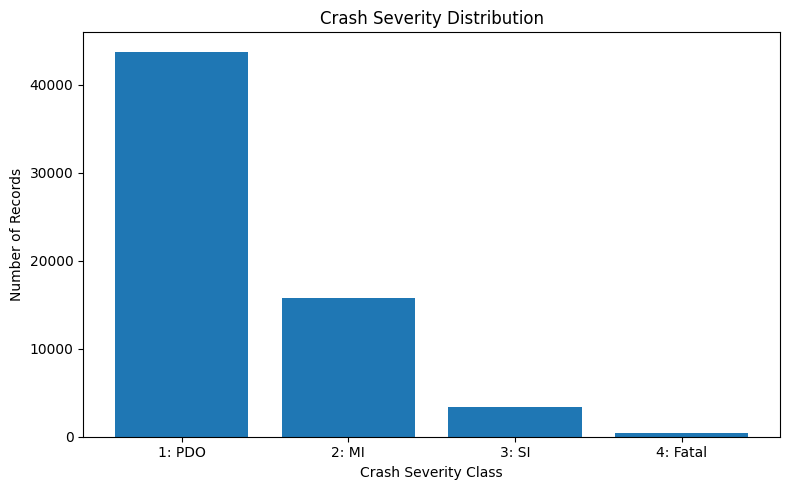


Severity count figure saved to:
/content/road_crash_outputs/figures/fig_eda_crash_severity_distribution_count.png


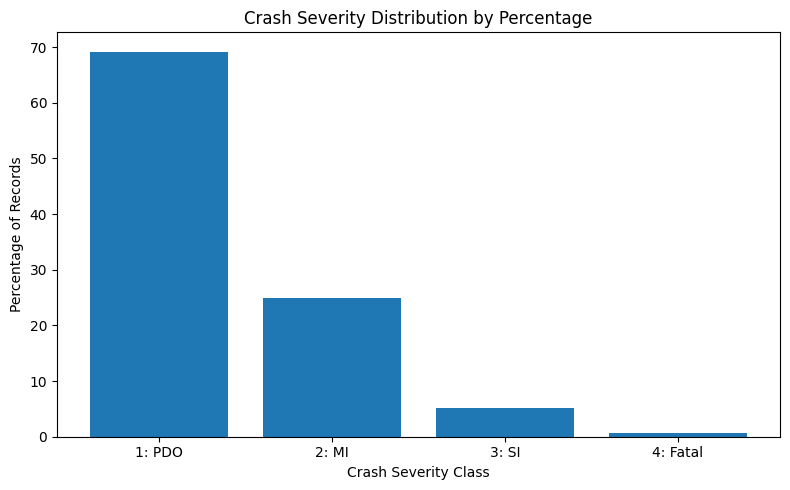


Severity percentage figure saved to:
/content/road_crash_outputs/figures/fig_eda_crash_severity_distribution_percentage.png

Report-ready interpretation saved to:
/content/road_crash_outputs/report_materials/eda_severity_distribution_interpretation.csv


,section,report_ready_interpretation
0,Crash severity distribution and class imbalance,The crash severity distribution shows a strong...



Report note:
This figure and table should be used in the EDA section.
Mention clearly that the dataset is highly imbalanced.
Explain that this is why macro F1-score, balanced accuracy, and recall are used later.

Cell 14 completed successfully.
Next: Run Cell 15 for temporal crash severity patterns.


In [20]:
# ============================================================
# Cell 14: EDA - Crash severity distribution and class imbalance
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 14: EDA - Crash severity distribution and class imbalance")
print("=" * 70)

# ------------------------------------------------------------
# This cell directly supports the report section:
# "Crash Severity Distribution and Class Imbalance"
#
# It also supports the modelling decision:
# Accuracy alone is not enough because the target classes are imbalanced.
# ------------------------------------------------------------

eda_target_df = df_model_ready.copy()

if TARGET_COL not in eda_target_df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in df_model_ready.")


# ------------------------------------------------------------
# 1. Create target distribution table
# ------------------------------------------------------------
severity_distribution = (
    eda_target_df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis("severity_class")
    .reset_index(name="count")
)

severity_distribution["percentage"] = (
    severity_distribution["count"] /
    severity_distribution["count"].sum() * 100
).round(2)

# Logical severity order
severity_order = ["1: PDO", "2: MI", "3: SI", "4: Fatal"]

severity_distribution["severity_order"] = severity_distribution["severity_class"].apply(
    lambda x: severity_order.index(x) if x in severity_order else 999
)

severity_distribution = (
    severity_distribution
    .sort_values("severity_order")
    .drop(columns=["severity_order"])
    .reset_index(drop=True)
)

severity_distribution_path = f"{TABLE_DIR}/eda_severity_distribution.csv"
severity_distribution.to_csv(severity_distribution_path, index=False)

print("\nCrash severity distribution saved to:")
print(severity_distribution_path)

display(severity_distribution)


# ------------------------------------------------------------
# 2. Create class imbalance summary
# ------------------------------------------------------------
majority_row = severity_distribution.loc[severity_distribution["count"].idxmax()]
minority_row = severity_distribution.loc[severity_distribution["count"].idxmin()]

imbalance_ratio = round(
    majority_row["count"] / minority_row["count"],
    2
)

minority_total = severity_distribution[
    severity_distribution["severity_class"].isin(["3: SI", "4: Fatal"])
]["count"].sum()

minority_total_percent = round(
    minority_total / severity_distribution["count"].sum() * 100,
    2
)

class_imbalance_report_table = pd.DataFrame({
    "item": [
        "Total crash records",
        "Majority class",
        "Majority class count",
        "Majority class percentage",
        "Minority class",
        "Minority class count",
        "Minority class percentage",
        "Majority-to-minority imbalance ratio",
        "Serious Injury + Fatal count",
        "Serious Injury + Fatal percentage",
        "Main modelling implication"
    ],
    "value": [
        severity_distribution["count"].sum(),
        majority_row["severity_class"],
        majority_row["count"],
        f"{majority_row['percentage']}%",
        minority_row["severity_class"],
        minority_row["count"],
        f"{minority_row['percentage']}%",
        f"{imbalance_ratio}:1",
        minority_total,
        f"{minority_total_percent}%",
        "Accuracy alone is misleading; macro F1, balanced accuracy, and minority-class recall are required."
    ]
})

class_imbalance_report_path = f"{TABLE_DIR}/eda_class_imbalance_report_table.csv"
class_imbalance_report_table.to_csv(class_imbalance_report_path, index=False)

print("\nClass imbalance report table saved to:")
print(class_imbalance_report_path)

display(class_imbalance_report_table)


# ------------------------------------------------------------
# 3. Plot severity distribution by count
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(
    severity_distribution["severity_class"].astype(str),
    severity_distribution["count"]
)
plt.title("Crash Severity Distribution")
plt.xlabel("Crash Severity Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()

severity_count_fig_path = f"{FIG_DIR}/fig_eda_crash_severity_distribution_count.png"
plt.savefig(severity_count_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSeverity count figure saved to:")
print(severity_count_fig_path)


# ------------------------------------------------------------
# 4. Plot severity distribution by percentage
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(
    severity_distribution["severity_class"].astype(str),
    severity_distribution["percentage"]
)
plt.title("Crash Severity Distribution by Percentage")
plt.xlabel("Crash Severity Class")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.tight_layout()

severity_percent_fig_path = f"{FIG_DIR}/fig_eda_crash_severity_distribution_percentage.png"
plt.savefig(severity_percent_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSeverity percentage figure saved to:")
print(severity_percent_fig_path)


# ------------------------------------------------------------
# 5. Create report-ready written interpretation
# ------------------------------------------------------------
eda_severity_interpretation = pd.DataFrame({
    "section": ["Crash severity distribution and class imbalance"],
    "report_ready_interpretation": [
        (
            f"The crash severity distribution shows a strong class imbalance. "
            f"The largest class is {majority_row['severity_class']} with "
            f"{majority_row['count']} records ({majority_row['percentage']}%), "
            f"whereas the smallest class is {minority_row['severity_class']} with "
            f"{minority_row['count']} records ({minority_row['percentage']}%). "
            f"The majority-to-minority imbalance ratio is approximately {imbalance_ratio}:1. "
            f"Serious Injury and Fatal crashes together account for only "
            f"{minority_total_percent}% of the dataset. Therefore, simple accuracy is not "
            f"sufficient for model evaluation. Macro F1-score, balanced accuracy, and "
            f"minority-class recall are more suitable because they give more attention to "
            f"rare but high-impact severity classes."
        )
    ]
})

eda_severity_interpretation_path = f"{REPORT_DIR}/eda_severity_distribution_interpretation.csv"
eda_severity_interpretation.to_csv(eda_severity_interpretation_path, index=False)

print("\nReport-ready interpretation saved to:")
print(eda_severity_interpretation_path)

display(eda_severity_interpretation)


# ------------------------------------------------------------
# 6. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("This figure and table should be used in the EDA section.")
print("Mention clearly that the dataset is highly imbalanced.")
print("Explain that this is why macro F1-score, balanced accuracy, and recall are used later.")

print("\nCell 14 completed successfully.")
print("Next: Run Cell 15 for temporal crash severity patterns.")

Cell 15: EDA - Temporal crash severity patterns

Saved count table: /content/road_crash_outputs/tables/eda_temporal_year_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_temporal_year_severity_percentage_table.csv

Severity count by year:


csef_severity,1: PDO,2: MI,3: SI,4: Fatal
year,,,,
2020,7566,3259,624,85
2021,8793,3546,716,94
2022,8806,2907,575,68
2023,9335,2910,712,109
2024,9268,3089,696,81



Severity percentage by year:


csef_severity,1: PDO,2: MI,3: SI,4: Fatal
year,,,,
2020,65.60,28.26,5.41,0.74
2021,66.87,26.97,5.45,0.71
2022,71.27,23.53,4.65,0.55
2023,71.44,22.27,5.45,0.83
2024,70.56,23.52,5.30,0.62



Saved count table: /content/road_crash_outputs/tables/eda_temporal_month_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_temporal_month_severity_percentage_table.csv

Severity count by month:


...

csef_severity,1: PDO,2: MI,3: SI,4: Fatal
crash_hour,,,,
0,74.49,13.99,10.20,1.31
1,75.59,15.73,7.59,1.08
2,72.62,14.81,9.74,2.84
3,72.58,15.05,9.68,2.69
4,70.99,16.54,11.70,0.76
5,72.78,19.08,7.69,0.44
6,70.75,23.22,5.21,0.81
7,70.56,24.63,4.34,0.47
8,68.95,27.98,2.76,0.32



Saved count table: /content/road_crash_outputs/tables/eda_temporal_time_period_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_temporal_time_period_severity_percentage_table.csv

Severity count by time period:


csef_severity,1: PDO,2: MI,3: SI,4: Fatal
time_period,,,,
Late night,2328,506,294,45
Morning,13435,5144,879,103
Afternoon,19745,7349,1359,166
Evening/Night,8260,2712,791,123



Severity percentage by time period:


csef_severity,1: PDO,2: MI,3: SI,4: Fatal
time_period,,,,
Late night,73.37,15.95,9.27,1.42
Morning,68.68,26.30,4.49,0.53
Afternoon,68.99,25.68,4.75,0.58
Evening/Night,69.49,22.82,6.65,1.03


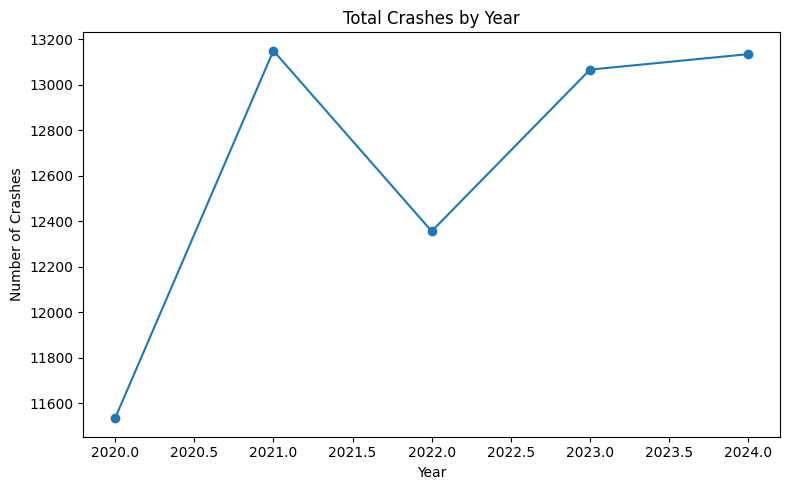


Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_year.png


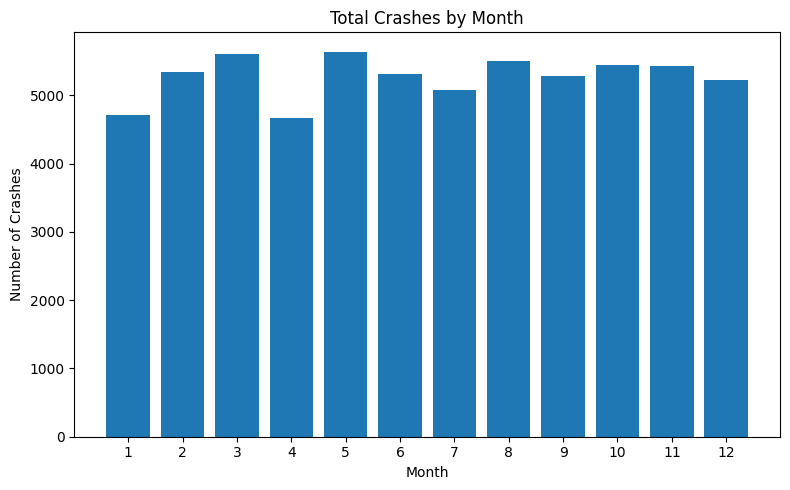


Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_month.png


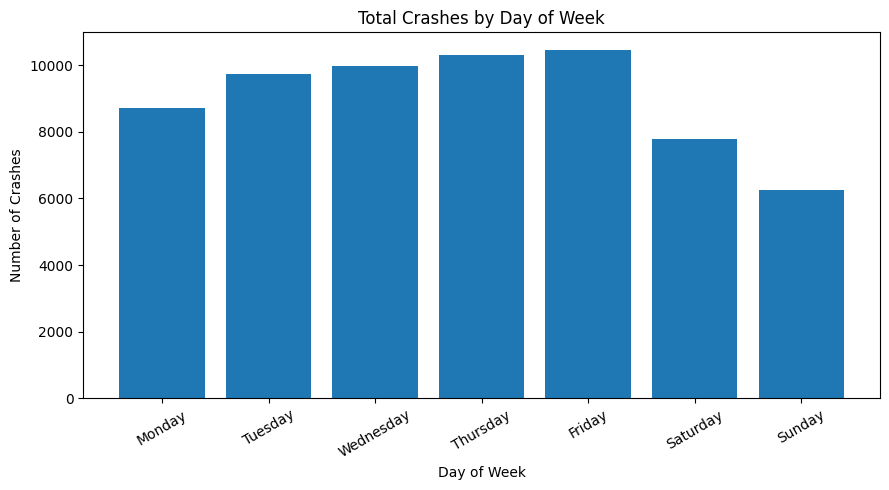


Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_day.png


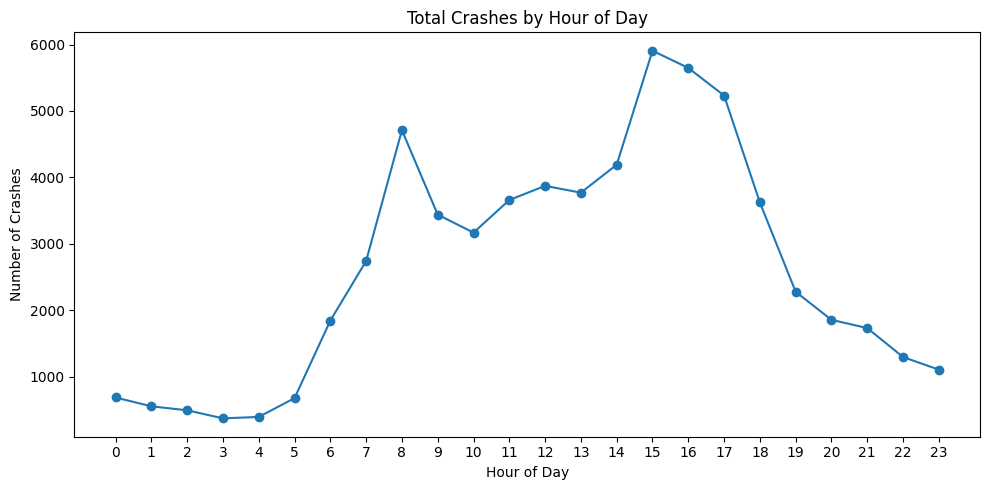


Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_hour.png

Serious/Fatal percentage by time period saved to:
/content/road_crash_outputs/tables/eda_time_period_serious_fatal_percentage.csv


,time_period,serious_or_fatal_percentage
0,Late night,10.68
1,Morning,5.02
2,Afternoon,5.33
3,Evening/Night,7.69


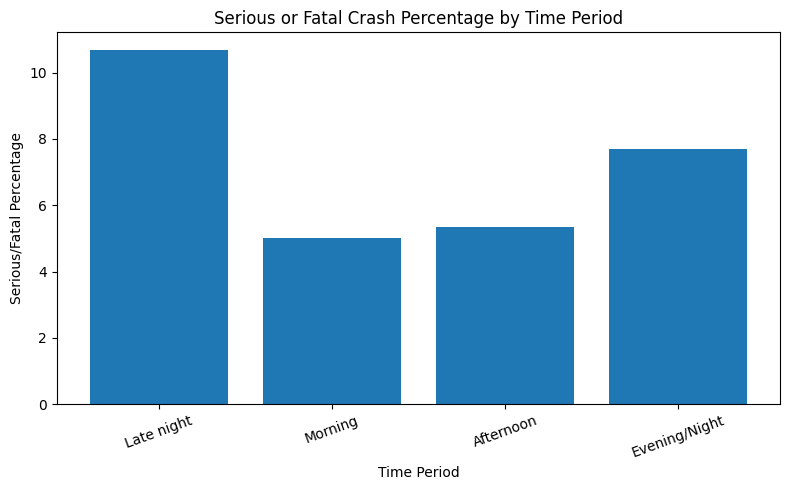


Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_time_period.png

Report-ready temporal interpretation saved to:
/content/road_crash_outputs/report_materials/eda_temporal_patterns_interpretation.csv


,section,report_ready_interpretation
0,Temporal crash severity patterns,Temporal analysis was conducted to examine cra...



Cell 15 completed successfully.
Next: Run Cell 16 for environmental and road condition EDA.


In [21]:
# ============================================================
# Cell 15: EDA - Temporal crash severity patterns
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 15: EDA - Temporal crash severity patterns")
print("=" * 70)

# ------------------------------------------------------------
# This cell supports the report section:
# "Temporal Patterns in Crash Severity"
#
# It analyses whether crash severity changes by:
# 1. Year
# 2. Month
# 3. Day of week
# 4. Hour of day
# 5. Time period
# ------------------------------------------------------------

eda_temporal_df = df_model_ready.copy()

# ------------------------------------------------------------
# Helper function to create count and percentage tables
# ------------------------------------------------------------
def create_severity_crosstab(df, group_col, output_prefix):
    if group_col not in df.columns:
        print(f"Column not found: {group_col}")
        return None, None

    count_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL]
    )

    percentage_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL],
        normalize="index"
    ) * 100

    percentage_table = percentage_table.round(2)

    count_path = f"{TABLE_DIR}/{output_prefix}_severity_count_table.csv"
    percentage_path = f"{TABLE_DIR}/{output_prefix}_severity_percentage_table.csv"

    count_table.to_csv(count_path)
    percentage_table.to_csv(percentage_path)

    print(f"\nSaved count table: {count_path}")
    print(f"Saved percentage table: {percentage_path}")

    return count_table, percentage_table


# ------------------------------------------------------------
# 1. Severity by year
# ------------------------------------------------------------
year_count_table, year_percentage_table = create_severity_crosstab(
    eda_temporal_df,
    "year",
    "eda_temporal_year"
)

if year_count_table is not None:
    print("\nSeverity count by year:")
    display(year_count_table)

    print("\nSeverity percentage by year:")
    display(year_percentage_table)


# ------------------------------------------------------------
# 2. Severity by month
# ------------------------------------------------------------
month_col = "month_num" if "month_num" in eda_temporal_df.columns else "month"

month_count_table, month_percentage_table = create_severity_crosstab(
    eda_temporal_df,
    month_col,
    "eda_temporal_month"
)

if month_count_table is not None:
    print("\nSeverity count by month:")
    display(month_count_table)

    print("\nSeverity percentage by month:")
    display(month_percentage_table)


# ------------------------------------------------------------
# 3. Severity by day of week
# ------------------------------------------------------------
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

if "day" in eda_temporal_df.columns:
    eda_temporal_df["day"] = pd.Categorical(
        eda_temporal_df["day"],
        categories=day_order,
        ordered=True
    )

day_count_table, day_percentage_table = create_severity_crosstab(
    eda_temporal_df,
    "day",
    "eda_temporal_day"
)

if day_count_table is not None:
    print("\nSeverity count by day:")
    display(day_count_table)

    print("\nSeverity percentage by day:")
    display(day_percentage_table)


# ------------------------------------------------------------
# 4. Severity by crash hour
# ------------------------------------------------------------
hour_count_table, hour_percentage_table = create_severity_crosstab(
    eda_temporal_df,
    "crash_hour",
    "eda_temporal_hour"
)

if hour_count_table is not None:
    print("\nSeverity count by crash hour:")
    display(hour_count_table)

    print("\nSeverity percentage by crash hour:")
    display(hour_percentage_table)


# ------------------------------------------------------------
# 5. Severity by time period
# ------------------------------------------------------------
time_period_order = [
    "Late night",
    "Morning",
    "Afternoon",
    "Evening/Night"
]

if "time_period" in eda_temporal_df.columns:
    eda_temporal_df["time_period"] = pd.Categorical(
        eda_temporal_df["time_period"],
        categories=time_period_order,
        ordered=True
    )

time_period_count_table, time_period_percentage_table = create_severity_crosstab(
    eda_temporal_df,
    "time_period",
    "eda_temporal_time_period"
)

if time_period_count_table is not None:
    print("\nSeverity count by time period:")
    display(time_period_count_table)

    print("\nSeverity percentage by time period:")
    display(time_period_percentage_table)


# ------------------------------------------------------------
# 6. Plot total crashes by year
# ------------------------------------------------------------
if "year" in eda_temporal_df.columns:
    year_total = (
        eda_temporal_df
        .groupby("year")
        .size()
        .reset_index(name="count")
        .sort_values("year")
    )

    plt.figure(figsize=(8, 5))
    plt.plot(year_total["year"], year_total["count"], marker="o")
    plt.title("Total Crashes by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Crashes")
    plt.tight_layout()

    year_fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_year.png"
    plt.savefig(year_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure:", year_fig_path)


# ------------------------------------------------------------
# 7. Plot total crashes by month
# ------------------------------------------------------------
if month_col in eda_temporal_df.columns:
    month_total = (
        eda_temporal_df
        .groupby(month_col)
        .size()
        .reset_index(name="count")
        .sort_values(month_col)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(month_total[month_col].astype(str), month_total["count"])
    plt.title("Total Crashes by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Crashes")
    plt.tight_layout()

    month_fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_month.png"
    plt.savefig(month_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure:", month_fig_path)


# ------------------------------------------------------------
# 8. Plot total crashes by day of week
# ------------------------------------------------------------
if "day" in eda_temporal_df.columns:
    day_total = (
        eda_temporal_df
        .groupby("day", observed=False)
        .size()
        .reset_index(name="count")
    )

    plt.figure(figsize=(9, 5))
    plt.bar(day_total["day"].astype(str), day_total["count"])
    plt.title("Total Crashes by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Number of Crashes")
    plt.xticks(rotation=30)
    plt.tight_layout()

    day_fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_day.png"
    plt.savefig(day_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure:", day_fig_path)


# ------------------------------------------------------------
# 9. Plot total crashes by hour
# ------------------------------------------------------------
if "crash_hour" in eda_temporal_df.columns:
    hour_total = (
        eda_temporal_df
        .groupby("crash_hour")
        .size()
        .reset_index(name="count")
        .sort_values("crash_hour")
    )

    plt.figure(figsize=(10, 5))
    plt.plot(hour_total["crash_hour"], hour_total["count"], marker="o")
    plt.title("Total Crashes by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Crashes")
    plt.xticks(range(0, 24))
    plt.tight_layout()

    hour_fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_hour.png"
    plt.savefig(hour_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure:", hour_fig_path)


# ------------------------------------------------------------
# 10. Plot serious/fatal percentage by time period
# ------------------------------------------------------------
if "time_period" in eda_temporal_df.columns:
    serious_fatal_labels = ["3: SI", "4: Fatal"]

    time_risk = (
        eda_temporal_df
        .groupby("time_period", observed=False)[TARGET_COL]
        .apply(lambda x: x.isin(serious_fatal_labels).mean() * 100)
        .reset_index(name="serious_or_fatal_percentage")
    )

    time_risk["serious_or_fatal_percentage"] = (
        time_risk["serious_or_fatal_percentage"].round(2)
    )

    time_risk_path = f"{TABLE_DIR}/eda_time_period_serious_fatal_percentage.csv"
    time_risk.to_csv(time_risk_path, index=False)

    print("\nSerious/Fatal percentage by time period saved to:")
    print(time_risk_path)
    display(time_risk)

    plt.figure(figsize=(8, 5))
    plt.bar(
        time_risk["time_period"].astype(str),
        time_risk["serious_or_fatal_percentage"]
    )
    plt.title("Serious or Fatal Crash Percentage by Time Period")
    plt.xlabel("Time Period")
    plt.ylabel("Serious/Fatal Percentage")
    plt.xticks(rotation=20)
    plt.tight_layout()

    time_risk_fig_path = f"{FIG_DIR}/fig_eda_serious_fatal_percentage_by_time_period.png"
    plt.savefig(time_risk_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure:", time_risk_fig_path)


# ------------------------------------------------------------
# 11. Report-ready interpretation
# ------------------------------------------------------------
highest_day = None
highest_hour = None

if "day" in eda_temporal_df.columns:
    day_counts = eda_temporal_df["day"].value_counts()
    if len(day_counts) > 0:
        highest_day = day_counts.idxmax()

if "crash_hour" in eda_temporal_df.columns:
    hour_counts = eda_temporal_df["crash_hour"].value_counts()
    if len(hour_counts) > 0:
        highest_hour = int(hour_counts.idxmax())

interpretation_text = (
    "Temporal analysis was conducted to examine crash severity patterns across year, "
    "month, day of week, hour of day, and broad time period. The output tables show both "
    "raw crash counts and row-wise severity percentages. This is important because a time "
    "period with many crashes does not always have the highest proportion of serious or "
    "fatal crashes. "
)

if highest_day is not None:
    interpretation_text += f"The highest total crash frequency was observed on {highest_day}. "

if highest_hour is not None:
    interpretation_text += f"The highest hourly crash frequency was observed around hour {highest_hour}. "

interpretation_text += (
    "These temporal patterns support the use of engineered variables such as crash_hour, "
    "is_weekend, season, and time_period in the predictive models."
)

temporal_interpretation = pd.DataFrame({
    "section": ["Temporal crash severity patterns"],
    "report_ready_interpretation": [interpretation_text]
})

temporal_interpretation_path = f"{REPORT_DIR}/eda_temporal_patterns_interpretation.csv"
temporal_interpretation.to_csv(temporal_interpretation_path, index=False)

print("\nReport-ready temporal interpretation saved to:")
print(temporal_interpretation_path)

display(temporal_interpretation)


print("\nCell 15 completed successfully.")
print("Next: Run Cell 16 for environmental and road condition EDA.")

Cell 16: EDA - Environmental and road condition patterns

Available environmental/road condition columns:
['weather_cond', 'moisture_cond', 'road_surface', 'daynight', 'is_raining', 'is_wet_road', 'is_night']

Saved count table: /content/road_crash_outputs/tables/eda_environment_weather_cond_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_environment_weather_cond_severity_percentage_table.csv

Saved Serious/Fatal risk table: /content/road_crash_outputs/tables/eda_environment_weather_cond_serious_fatal_risk_table.csv

Serious/Fatal risk by weather_cond:


,weather_cond,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
2,NaN,399,48,12.03,True
0,Not Raining,57251,3448,6.02,True
1,Raining,5589,264,4.72,True



Saved count table: /content/road_crash_outputs/tables/eda_environment_moisture_cond_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_environment_moisture_cond_severity_percentage_table.csv

Saved Serious/Fatal risk table: /content/road_crash_outputs/tables/eda_environment_moisture_cond_serious_fatal_risk_table.csv

Serious/Fatal risk by moisture_cond:


,moisture_cond,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
2,NaN,218,27,12.39,True
0,Dry,54768,3337,6.09,True
1,Wet,8253,396,4.80,True



Saved count table: /content/road_crash_outputs/tables/eda_environment_road_surface_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_environment_road_surface_severity_percentage_table.csv

Saved Serious/Fatal risk table: /content/road_crash_outputs/tables/eda_environment_road_surface_serious_fatal_risk_table.csv

Serious/Fatal risk by road_surface:


...

,is_raining,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
0,0,399,48,12.03,True
1,1,62840,3712,5.91,True



Saved count table: /content/road_crash_outputs/tables/eda_environment_is_wet_road_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_environment_is_wet_road_severity_percentage_table.csv

Saved Serious/Fatal risk table: /content/road_crash_outputs/tables/eda_environment_is_wet_road_serious_fatal_risk_table.csv

Serious/Fatal risk by is_wet_road:


,is_wet_road,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
0,0,54986,3364,6.12,True
1,1,8253,396,4.80,True



Saved count table: /content/road_crash_outputs/tables/eda_environment_is_night_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_environment_is_night_severity_percentage_table.csv

Saved Serious/Fatal risk table: /content/road_crash_outputs/tables/eda_environment_is_night_serious_fatal_risk_table.csv

Serious/Fatal risk by is_night:


,is_night,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
1,1,14807,1197,8.08,True
0,0,48432,2563,5.29,True


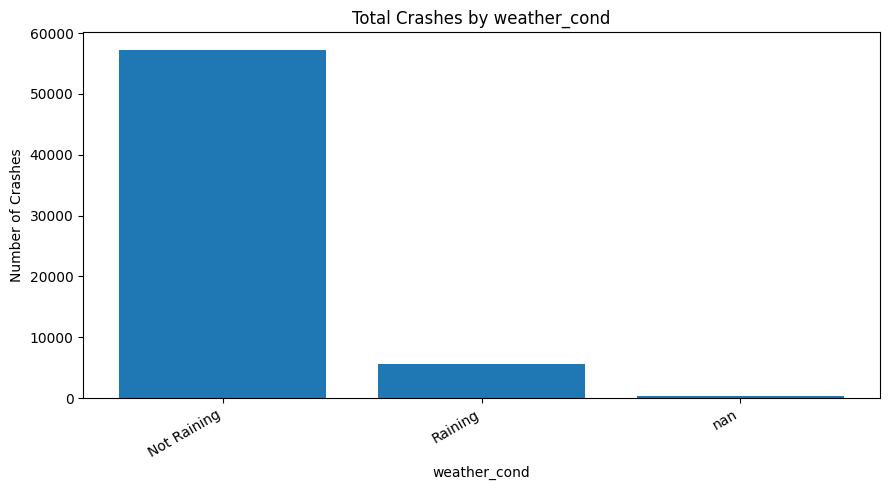

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_weather_cond.png


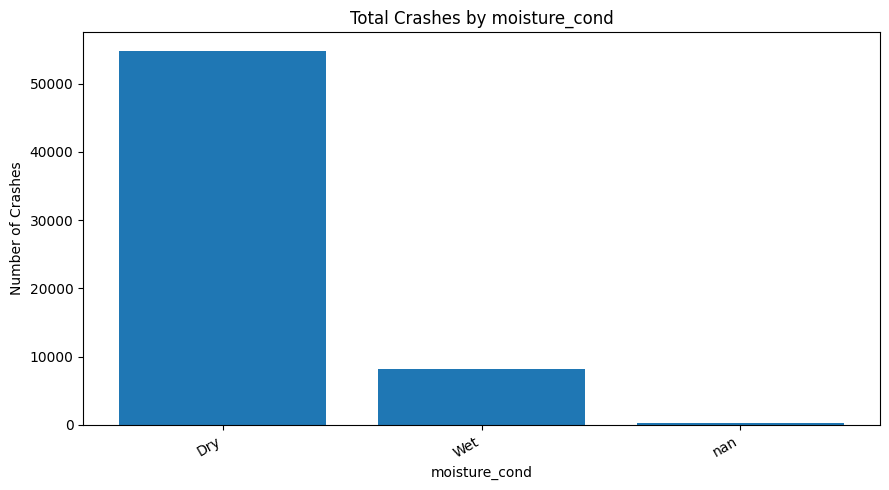

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_moisture_cond.png


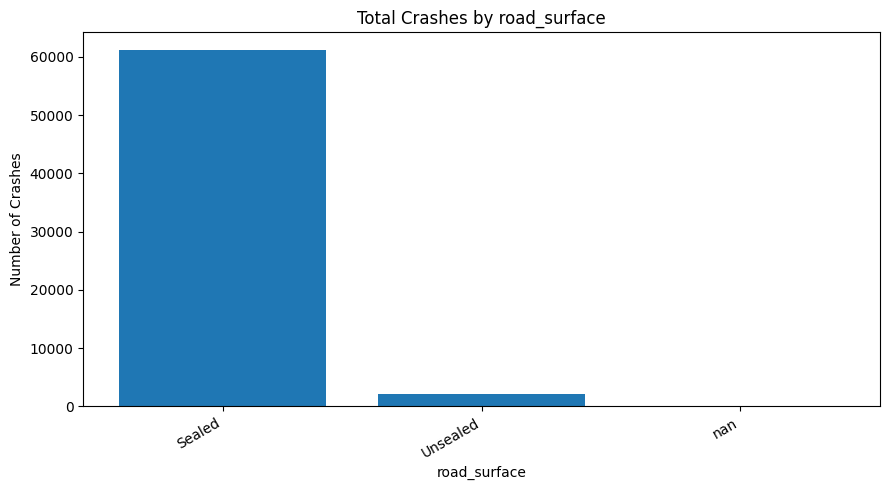

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_road_surface.png


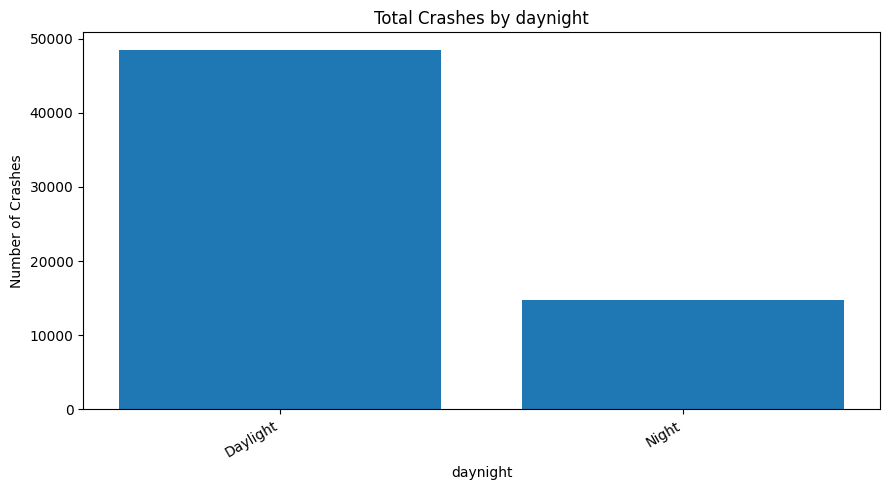

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_daynight.png


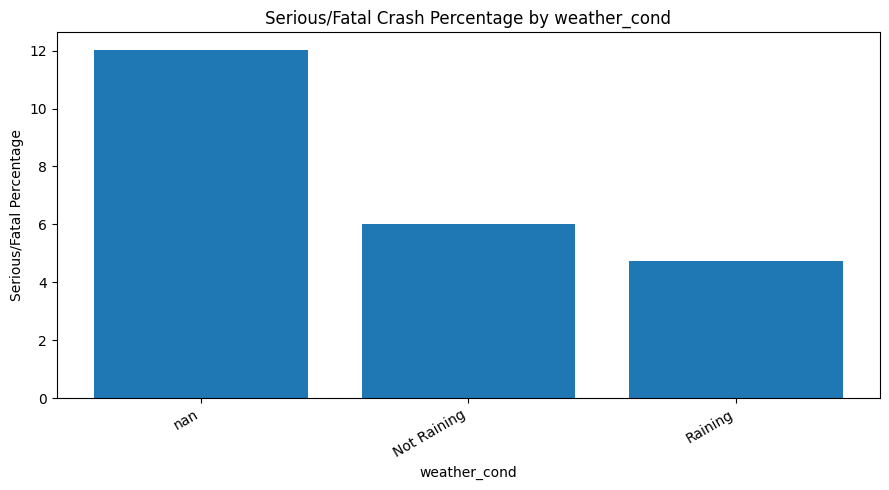

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_weather_cond.png


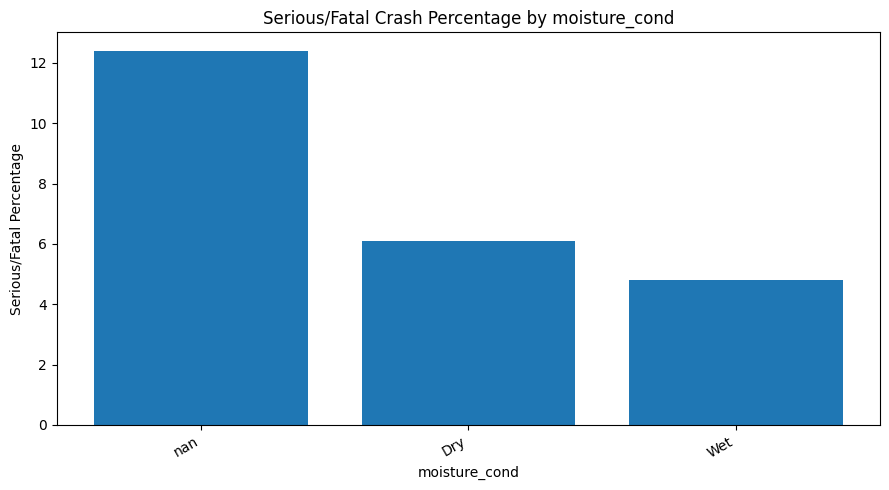

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_moisture_cond.png


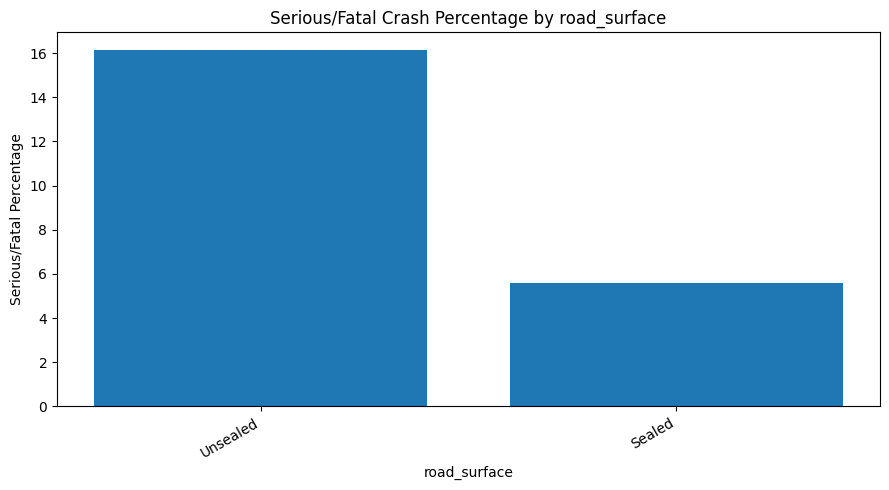

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_road_surface.png


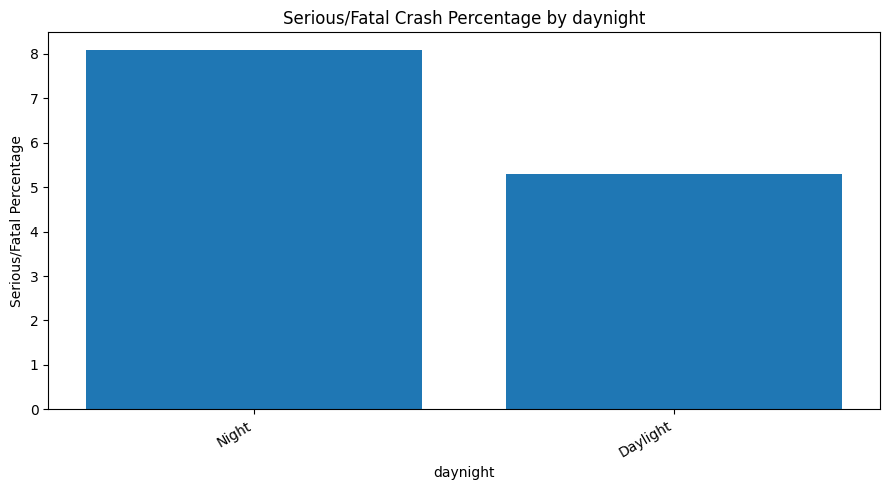

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_daynight.png

Binary environmental risk summary saved to:
/content/road_crash_outputs/tables/eda_binary_environmental_risk_summary.csv


,variable,is_raining,total_records,serious_fatal_count,serious_fatal_percentage
0,is_raining,0.0,399,48,12.03
1,is_raining,1.0,62840,3712,5.91
2,is_wet_road,NaN,54986,3364,6.12
3,is_wet_road,NaN,8253,396,4.80
4,is_night,NaN,48432,2563,5.29
5,is_night,NaN,14807,1197,8.08



Highest-risk environmental condition table saved to:
/content/road_crash_outputs/tables/eda_highest_risk_environmental_conditions.csv


,variable,highest_risk_category,total_records,serious_fatal_count,serious_fatal_percentage
0,weather_cond,NaN,399,48,12.03
1,moisture_cond,NaN,218,27,12.39
2,road_surface,Unsealed,2070,334,16.14
3,daynight,Night,14807,1197,8.08
4,is_raining,0,399,48,12.03
5,is_wet_road,0,54986,3364,6.12
6,is_night,1,14807,1197,8.08



Report-ready environmental interpretation saved to:
/content/road_crash_outputs/report_materials/eda_environmental_road_condition_interpretation.csv


,section,report_ready_interpretation
0,Environmental and road condition patterns,Environmental and road condition analysis was ...



Report note:
Use these outputs in the Environmental and Road Condition Analysis section.
Mention both count patterns and Serious/Fatal percentage patterns.
Avoid saying a condition is more dangerous only because it has more total crashes.
Focus on Serious/Fatal percentage for severity risk interpretation.

Cell 16 completed successfully.
Next: Run Cell 17 for crash type and traffic characteristic analysis.


In [22]:
# ============================================================
# Cell 16: EDA - Environmental and road condition patterns
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 16: EDA - Environmental and road condition patterns")
print("=" * 70)

# ------------------------------------------------------------
# This cell supports the report section:
# "Environmental and Road Condition Analysis"
#
# It analyses severity patterns by:
# 1. Weather condition
# 2. Moisture condition
# 3. Road surface
# 4. Day/night condition
# 5. Wet road indicator
# 6. Rain indicator
# 7. Night indicator
# ------------------------------------------------------------

eda_env_df = df_model_ready.copy()

serious_fatal_labels = ["3: SI", "4: Fatal"]

# ------------------------------------------------------------
# Helper function 1:
# Create severity count and percentage tables
# ------------------------------------------------------------
def create_env_severity_tables(df, group_col, output_prefix):
    if group_col not in df.columns:
        print(f"Column not found: {group_col}")
        return None, None

    count_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL]
    )

    percentage_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL],
        normalize="index"
    ) * 100

    percentage_table = percentage_table.round(2)

    count_path = f"{TABLE_DIR}/{output_prefix}_severity_count_table.csv"
    percentage_path = f"{TABLE_DIR}/{output_prefix}_severity_percentage_table.csv"

    count_table.to_csv(count_path)
    percentage_table.to_csv(percentage_path)

    print(f"\nSaved count table: {count_path}")
    print(f"Saved percentage table: {percentage_path}")

    return count_table, percentage_table


# ------------------------------------------------------------
# Helper function 2:
# Calculate Serious/Fatal percentage by group
# ------------------------------------------------------------
def calculate_serious_fatal_risk(df, group_col, output_prefix, min_count=50):
    if group_col not in df.columns:
        print(f"Column not found: {group_col}")
        return None

    risk_table = (
        df
        .groupby(group_col, dropna=False)[TARGET_COL]
        .agg(
            total_records="count",
            serious_fatal_count=lambda x: x.isin(serious_fatal_labels).sum(),
            serious_fatal_percentage=lambda x: x.isin(serious_fatal_labels).mean() * 100
        )
        .reset_index()
    )

    risk_table["serious_fatal_percentage"] = (
        risk_table["serious_fatal_percentage"].round(2)
    )

    risk_table["included_in_risk_interpretation"] = (
        risk_table["total_records"] >= min_count
    )

    risk_table = risk_table.sort_values(
        ["included_in_risk_interpretation", "serious_fatal_percentage"],
        ascending=[False, False]
    )

    risk_path = f"{TABLE_DIR}/{output_prefix}_serious_fatal_risk_table.csv"
    risk_table.to_csv(risk_path, index=False)

    print(f"\nSaved Serious/Fatal risk table: {risk_path}")

    return risk_table


# ------------------------------------------------------------
# 1. Environmental and road condition variables
# ------------------------------------------------------------
environmental_columns = [
    "weather_cond",
    "moisture_cond",
    "road_surface",
    "daynight",
    "is_raining",
    "is_wet_road",
    "is_night"
]

available_environmental_columns = [
    col for col in environmental_columns
    if col in eda_env_df.columns
]

print("\nAvailable environmental/road condition columns:")
print(available_environmental_columns)


# ------------------------------------------------------------
# 2. Create count, percentage, and risk tables for each variable
# ------------------------------------------------------------
environmental_summary_tables = {}

for col in available_environmental_columns:
    output_prefix = f"eda_environment_{col}"

    count_table, percentage_table = create_env_severity_tables(
        eda_env_df,
        col,
        output_prefix
    )

    risk_table = calculate_serious_fatal_risk(
        eda_env_df,
        col,
        output_prefix,
        min_count=50
    )

    environmental_summary_tables[col] = {
        "count_table": count_table,
        "percentage_table": percentage_table,
        "risk_table": risk_table
    }

    print(f"\nSerious/Fatal risk by {col}:")
    display(risk_table)


# ------------------------------------------------------------
# 3. Plot total crashes by selected environmental variables
# ------------------------------------------------------------
plot_columns = [
    "weather_cond",
    "moisture_cond",
    "road_surface",
    "daynight"
]

for col in plot_columns:
    if col in eda_env_df.columns:
        plot_data = (
            eda_env_df
            .groupby(col, dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )

        plt.figure(figsize=(9, 5))
        plt.bar(
            plot_data[col].astype(str),
            plot_data["count"]
        )
        plt.title(f"Total Crashes by {col}")
        plt.xlabel(col)
        plt.ylabel("Number of Crashes")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_{col}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved figure:", fig_path)


# ------------------------------------------------------------
# 4. Plot Serious/Fatal percentage for selected variables
# ------------------------------------------------------------
for col in plot_columns:
    if col in eda_env_df.columns:
        risk_table = environmental_summary_tables[col]["risk_table"]

        if risk_table is not None:
            plot_risk = risk_table[
                risk_table["included_in_risk_interpretation"] == True
            ].copy()

            if len(plot_risk) > 0:
                plt.figure(figsize=(9, 5))
                plt.bar(
                    plot_risk[col].astype(str),
                    plot_risk["serious_fatal_percentage"]
                )
                plt.title(f"Serious/Fatal Crash Percentage by {col}")
                plt.xlabel(col)
                plt.ylabel("Serious/Fatal Percentage")
                plt.xticks(rotation=30, ha="right")
                plt.tight_layout()

                fig_path = f"{FIG_DIR}/fig_eda_serious_fatal_percentage_by_{col}.png"
                plt.savefig(fig_path, dpi=300, bbox_inches="tight")
                plt.show()

                print("Saved figure:", fig_path)


# ------------------------------------------------------------
# 5. Compare binary engineered risk indicators
# ------------------------------------------------------------
binary_risk_cols = [
    "is_raining",
    "is_wet_road",
    "is_night"
]

binary_risk_summary_list = []

for col in binary_risk_cols:
    if col in eda_env_df.columns:
        temp = (
            eda_env_df
            .groupby(col)[TARGET_COL]
            .agg(
                total_records="count",
                serious_fatal_count=lambda x: x.isin(serious_fatal_labels).sum(),
                serious_fatal_percentage=lambda x: x.isin(serious_fatal_labels).mean() * 100
            )
            .reset_index()
        )

        temp["variable"] = col
        temp["serious_fatal_percentage"] = temp["serious_fatal_percentage"].round(2)

        binary_risk_summary_list.append(temp)

if len(binary_risk_summary_list) > 0:
    binary_risk_summary = pd.concat(
        binary_risk_summary_list,
        ignore_index=True
    )

    binary_risk_summary = binary_risk_summary[
        [
            "variable",
            binary_risk_summary.columns[0],
            "total_records",
            "serious_fatal_count",
            "serious_fatal_percentage"
        ]
    ]

    binary_risk_summary_path = f"{TABLE_DIR}/eda_binary_environmental_risk_summary.csv"
    binary_risk_summary.to_csv(binary_risk_summary_path, index=False)

    print("\nBinary environmental risk summary saved to:")
    print(binary_risk_summary_path)

    display(binary_risk_summary)


# ------------------------------------------------------------
# 6. Identify highest-risk environmental condition per variable
# ------------------------------------------------------------
highest_risk_records = []

for col in available_environmental_columns:
    risk_table = environmental_summary_tables[col]["risk_table"]

    if risk_table is not None:
        valid_risk_table = risk_table[
            risk_table["included_in_risk_interpretation"] == True
        ].copy()

        if len(valid_risk_table) > 0:
            top_row = valid_risk_table.sort_values(
                "serious_fatal_percentage",
                ascending=False
            ).iloc[0]

            highest_risk_records.append({
                "variable": col,
                "highest_risk_category": top_row[col],
                "total_records": top_row["total_records"],
                "serious_fatal_count": top_row["serious_fatal_count"],
                "serious_fatal_percentage": top_row["serious_fatal_percentage"]
            })

highest_risk_environment_table = pd.DataFrame(highest_risk_records)

highest_risk_environment_path = f"{TABLE_DIR}/eda_highest_risk_environmental_conditions.csv"
highest_risk_environment_table.to_csv(highest_risk_environment_path, index=False)

print("\nHighest-risk environmental condition table saved to:")
print(highest_risk_environment_path)

display(highest_risk_environment_table)


# ------------------------------------------------------------
# 7. Report-ready interpretation
# ------------------------------------------------------------
interpretation_parts = []

interpretation_parts.append(
    "Environmental and road condition analysis was conducted to examine how crash severity varies across weather, road moisture, road surface, and day/night conditions. "
    "Both crash counts and Serious/Fatal percentages were calculated because high-frequency conditions do not always represent the highest severity risk."
)

if "weather_cond" in highest_risk_environment_table["variable"].values:
    row = highest_risk_environment_table[
        highest_risk_environment_table["variable"] == "weather_cond"
    ].iloc[0]

    interpretation_parts.append(
        f"For weather condition, the highest Serious/Fatal percentage among sufficiently represented groups was observed for '{row['highest_risk_category']}' "
        f"with {row['serious_fatal_percentage']}% Serious/Fatal crashes."
    )

if "moisture_cond" in highest_risk_environment_table["variable"].values:
    row = highest_risk_environment_table[
        highest_risk_environment_table["variable"] == "moisture_cond"
    ].iloc[0]

    interpretation_parts.append(
        f"For moisture condition, the highest Serious/Fatal percentage was observed for '{row['highest_risk_category']}' "
        f"with {row['serious_fatal_percentage']}% Serious/Fatal crashes."
    )

if "daynight" in highest_risk_environment_table["variable"].values:
    row = highest_risk_environment_table[
        highest_risk_environment_table["variable"] == "daynight"
    ].iloc[0]

    interpretation_parts.append(
        f"For day/night condition, '{row['highest_risk_category']}' showed a Serious/Fatal percentage of {row['serious_fatal_percentage']}%."
    )

interpretation_parts.append(
    "These findings justify the inclusion of engineered features such as is_raining, is_wet_road, and is_night in the modelling dataset."
)

environment_interpretation = pd.DataFrame({
    "section": ["Environmental and road condition patterns"],
    "report_ready_interpretation": [" ".join(interpretation_parts)]
})

environment_interpretation_path = f"{REPORT_DIR}/eda_environmental_road_condition_interpretation.csv"
environment_interpretation.to_csv(environment_interpretation_path, index=False)

print("\nReport-ready environmental interpretation saved to:")
print(environment_interpretation_path)

display(environment_interpretation)


# ------------------------------------------------------------
# 8. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Use these outputs in the Environmental and Road Condition Analysis section.")
print("Mention both count patterns and Serious/Fatal percentage patterns.")
print("Avoid saying a condition is more dangerous only because it has more total crashes.")
print("Focus on Serious/Fatal percentage for severity risk interpretation.")

print("\nCell 16 completed successfully.")
print("Next: Run Cell 17 for crash type and traffic characteristic analysis.")

Cell 17: EDA - Crash type and traffic characteristic analysis

Available crash type and traffic characteristic columns:
['crash_type', 'traffic_ctrls', 'speed_category', 'area_speed', 'position_type', 'horizontal_align', 'vertical_align', 'entity_code', 'unit_resp', 'unit_main_unit_type', 'unit_main_unit_movement', 'has_motorcycle', 'has_pedestrian', 'has_bicycle', 'has_heavy_vehicle']

Saved count table: /content/road_crash_outputs/tables/eda_traffic_crash_type_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_traffic_crash_type_severity_percentage_table.csv

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_traffic_crash_type_serious_fatal_percentage.csv

Serious/Fatal percentage by crash_type:


,crash_type,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
11,Roll Over,2812,637,22.65,True
0,Head On,1127,243,21.56,True
5,Hit Pedestrian,1933,400,20.69,True
2,Hit Fixed Object,10298,953,9.25,True
1,Hit Animal,938,55,5.86,True
3,Hit Object on Road,261,14,5.36,True
10,Right Turn,5419,285,5.26,True
7,Other,515,25,4.85,True
9,Right Angle,12924,593,4.59,True
6,Left Road - Out of Control,513,19,3.70,True



Saved count table: /content/road_crash_outputs/tables/eda_traffic_traffic_ctrls_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_traffic_traffic_ctrls_severity_percentage_table.csv

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_traffic_traffic_ctrls_serious_fatal_percentage.csv

Serious/Fatal percentage by traffic_ctrls:


,traffic_ctrls,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
1,No Control,42195,2872,6.81,True
0,Give Way Sign,4842,300,6.20,True
8,Stop Sign,2258,103,4.56,True
3,Rail Xing - Boom,57,2,3.51,True
9,Traffic Signals,11169,386,3.46,True
7,Roundabout,2634,91,3.45,True
5,Rail Xing - No Control,2,1,50.00,False
4,Rail Xing - Flashing,14,3,21.43,False
2,Other,33,2,6.06,False
6,Rail Xing-Traffic Signals,35,0,0.00,False



Saved count table: /content/road_crash_outputs/tables/eda_traffic_speed_category_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_traffic_speed_category_severity_percentage_table.csv

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_traffic_speed_category_serious_fatal_percentage.csv

Serious/Fatal percentage by speed_category:


...

,has_pedestrian,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
1,1,1839,399,21.70,True
0,0,61400,3361,5.47,True



Saved count table: /content/road_crash_outputs/tables/eda_traffic_has_bicycle_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_traffic_has_bicycle_severity_percentage_table.csv

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_traffic_has_bicycle_serious_fatal_percentage.csv

Serious/Fatal percentage by has_bicycle:


,has_bicycle,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
1,1,7109,1357,19.09,True
0,0,56130,2403,4.28,True



Saved count table: /content/road_crash_outputs/tables/eda_traffic_has_heavy_vehicle_severity_count_table.csv
Saved percentage table: /content/road_crash_outputs/tables/eda_traffic_has_heavy_vehicle_severity_percentage_table.csv

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_traffic_has_heavy_vehicle_serious_fatal_percentage.csv

Serious/Fatal percentage by has_heavy_vehicle:


,has_heavy_vehicle,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
0,0,55676,3589,6.45,True
1,1,7563,171,2.26,True


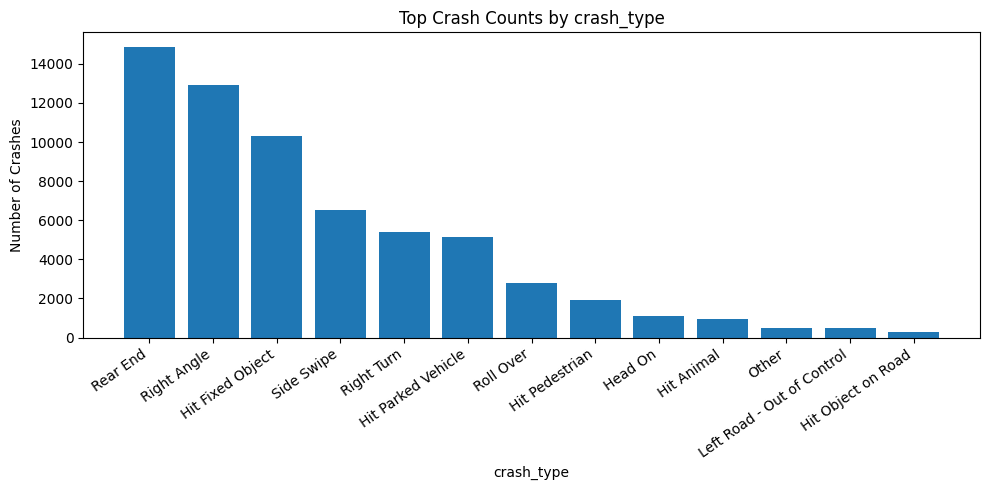

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_crash_type.png


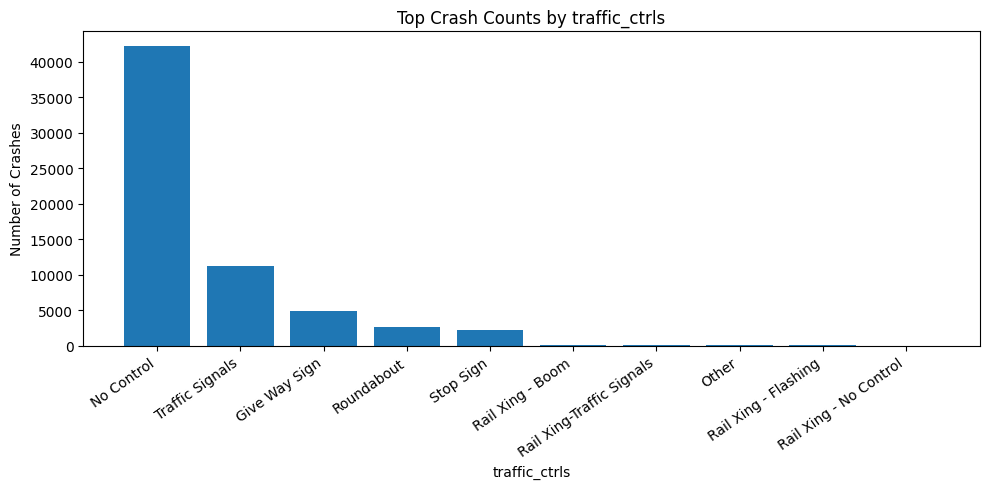

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_traffic_ctrls.png


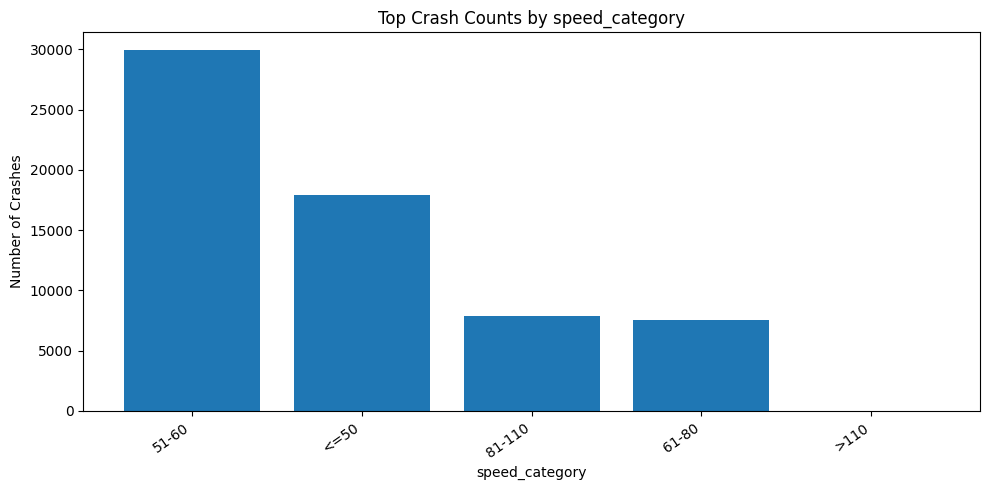

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_speed_category.png


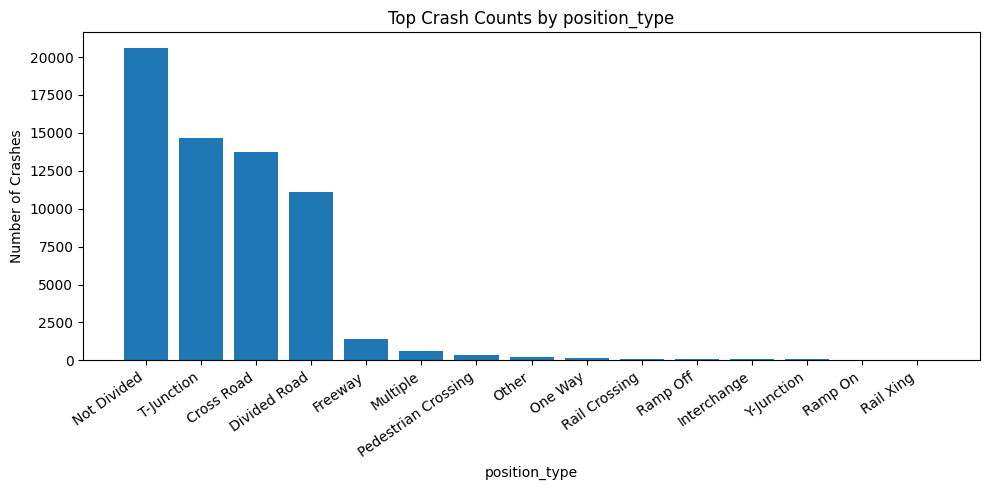

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_position_type.png


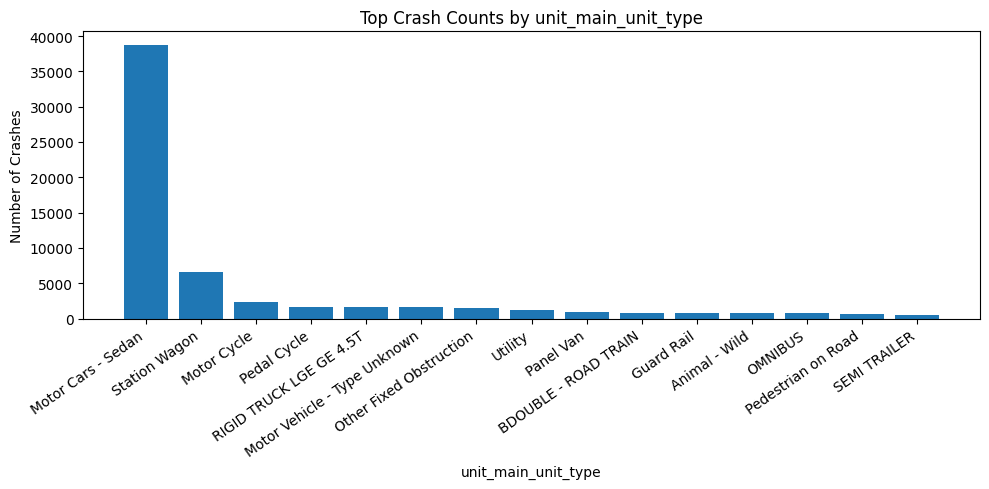

Saved figure: /content/road_crash_outputs/figures/fig_eda_total_crashes_by_unit_main_unit_type.png


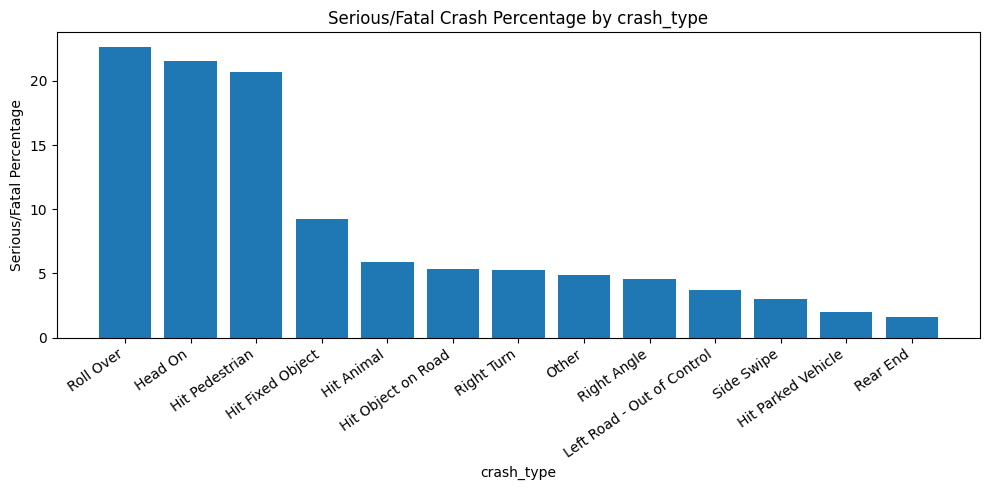

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_crash_type.png


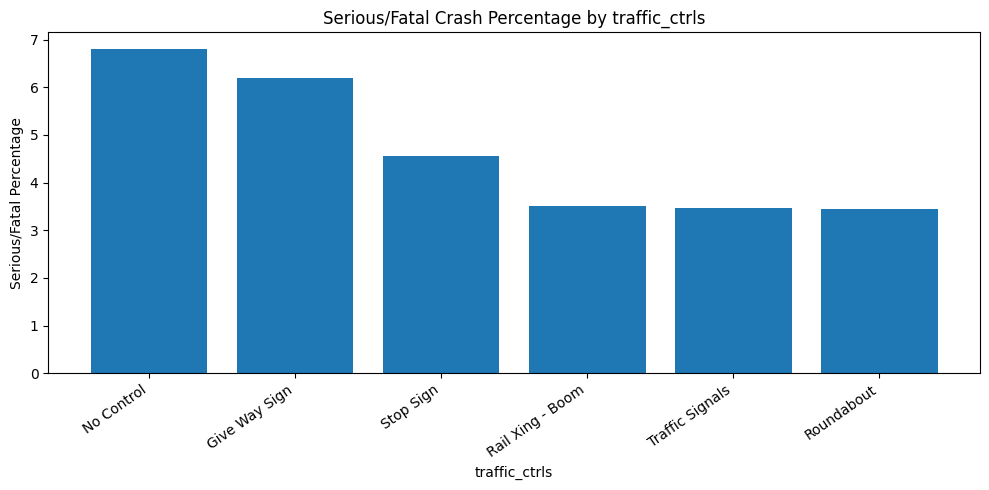

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_traffic_ctrls.png


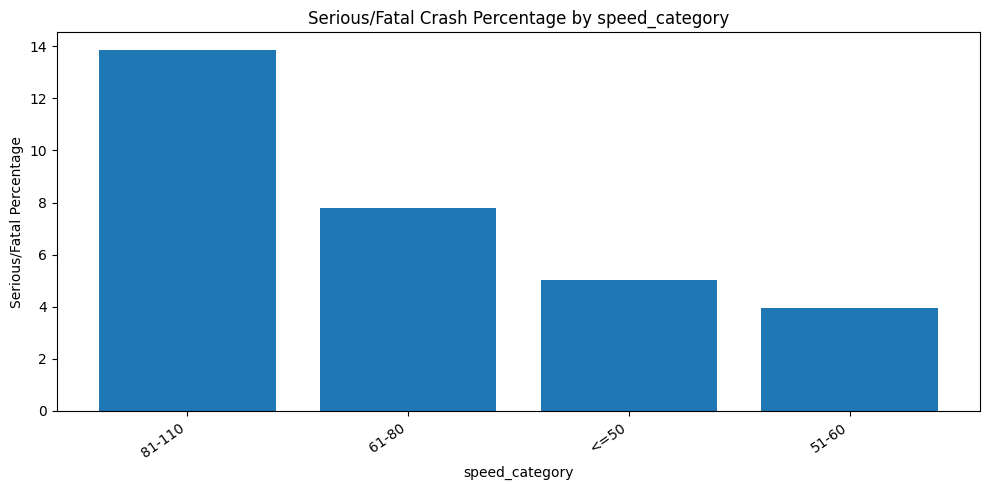

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_speed_category.png


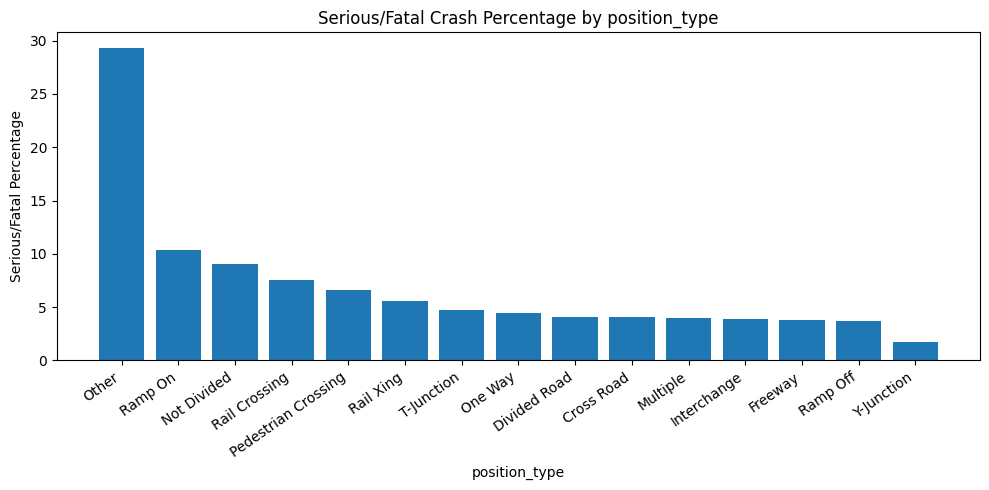

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_position_type.png


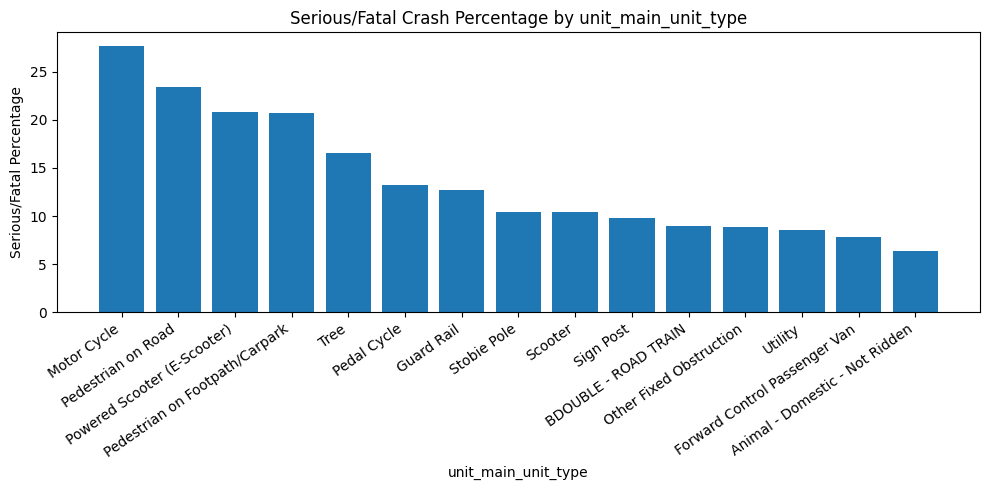

Saved figure: /content/road_crash_outputs/figures/fig_eda_serious_fatal_percentage_by_unit_main_unit_type.png

Saved Serious/Fatal percentage table: /content/road_crash_outputs/tables/eda_speed_category_serious_fatal_percentage.csv

Speed category risk summary saved to:
/content/road_crash_outputs/tables/eda_speed_category_risk_summary.csv


,speed_category,total_records,serious_fatal_count,serious_fatal_percentage,included_in_risk_interpretation
3,81-110,7891,1092,13.84,True
2,61-80,7525,587,7.80,True
0,<=50,17895,896,5.01,True
1,51-60,29928,1185,3.96,True
4,>110,0,0,NaN,False


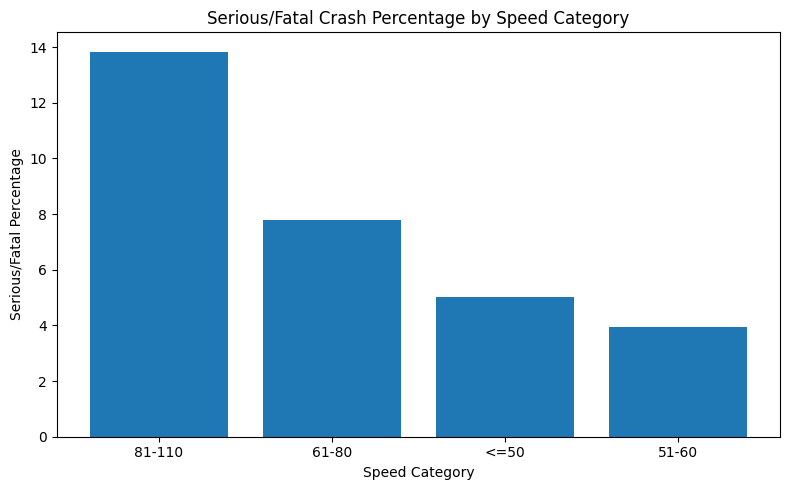

Saved figure: /content/road_crash_outputs/figures/fig_eda_speed_category_serious_fatal_percentage.png

Vehicle/user indicator risk summary saved to:
/content/road_crash_outputs/tables/eda_vehicle_user_indicator_risk_summary.csv


,variable,value,total_records,serious_fatal_count,serious_fatal_percentage
0,has_motorcycle,0,63239,3760,5.95
1,has_pedestrian,0,61400,3361,5.47
2,has_pedestrian,1,1839,399,21.70
3,has_bicycle,0,56130,2403,4.28
4,has_bicycle,1,7109,1357,19.09
5,has_heavy_vehicle,0,55676,3589,6.45
6,has_heavy_vehicle,1,7563,171,2.26



Highest-risk traffic characteristic table saved to:
/content/road_crash_outputs/tables/eda_highest_risk_traffic_characteristics.csv


,variable,highest_risk_category,total_records,serious_fatal_count,serious_fatal_percentage
0,crash_type,Roll Over,2812,637,22.65
1,traffic_ctrls,No Control,42195,2872,6.81
2,speed_category,81-110,7891,1092,13.84
3,area_speed,100,4050,676,16.69
4,position_type,Other,191,56,29.32
5,horizontal_align,"CURVED, VIEW OBSCURED",2580,349,13.53
6,vertical_align,NaN,246,27,10.98
7,entity_code,Pedestrian,1074,259,24.12
8,unit_resp,1,36622,2778,7.59
9,unit_main_unit_type,Motor Cycle,2310,640,27.71



Report-ready crash type and traffic interpretation saved to:
/content/road_crash_outputs/report_materials/eda_crash_type_traffic_characteristics_interpretation.csv


,section,report_ready_interpretation
0,Crash type and traffic characteristic analysis,Crash type and traffic characteristic analysis...



Report note:
Use this section to explain crash type, speed category, traffic controls, and vehicle/user involvement.
Do not only discuss which category has the most crashes.
Also discuss which category has the highest Serious/Fatal percentage.

Cell 17 completed successfully.
Next: Run Cell 18 for supervisor-required advanced outlier detection using LOF and Isolation Forest.


In [23]:
# ============================================================
# Cell 17: EDA - Crash type and traffic characteristic analysis
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 17: EDA - Crash type and traffic characteristic analysis")
print("=" * 70)

# ------------------------------------------------------------
# This cell supports the report section:
# "Crash Type and Traffic Characteristics"
#
# It analyses severity patterns by:
# 1. Crash type
# 2. Traffic controls
# 3. Speed category
# 4. Position type
# 5. Road alignment
# 6. Vehicle/user involvement indicators
# ------------------------------------------------------------

eda_traffic_df = df_model_ready.copy()

serious_fatal_labels = ["3: SI", "4: Fatal"]

# ------------------------------------------------------------
# Helper function 1:
# Create severity count and percentage tables
# ------------------------------------------------------------
def create_traffic_severity_tables(df, group_col, output_prefix):
    if group_col not in df.columns:
        print(f"Column not found: {group_col}")
        return None, None

    count_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL]
    )

    percentage_table = pd.crosstab(
        df[group_col],
        df[TARGET_COL],
        normalize="index"
    ) * 100

    percentage_table = percentage_table.round(2)

    count_path = f"{TABLE_DIR}/{output_prefix}_severity_count_table.csv"
    percentage_path = f"{TABLE_DIR}/{output_prefix}_severity_percentage_table.csv"

    count_table.to_csv(count_path)
    percentage_table.to_csv(percentage_path)

    print(f"\nSaved count table: {count_path}")
    print(f"Saved percentage table: {percentage_path}")

    return count_table, percentage_table


# ------------------------------------------------------------
# Helper function 2:
# Calculate Serious/Fatal percentage by category
# ------------------------------------------------------------
def calculate_serious_fatal_percentage(df, group_col, output_prefix, min_count=50):
    if group_col not in df.columns:
        print(f"Column not found: {group_col}")
        return None

    risk_table = (
        df
        .groupby(group_col, dropna=False)[TARGET_COL]
        .agg(
            total_records="count",
            serious_fatal_count=lambda x: x.isin(serious_fatal_labels).sum(),
            serious_fatal_percentage=lambda x: x.isin(serious_fatal_labels).mean() * 100
        )
        .reset_index()
    )

    risk_table["serious_fatal_percentage"] = (
        risk_table["serious_fatal_percentage"].round(2)
    )

    risk_table["included_in_risk_interpretation"] = (
        risk_table["total_records"] >= min_count
    )

    risk_table = risk_table.sort_values(
        ["included_in_risk_interpretation", "serious_fatal_percentage"],
        ascending=[False, False]
    )

    risk_path = f"{TABLE_DIR}/{output_prefix}_serious_fatal_percentage.csv"
    risk_table.to_csv(risk_path, index=False)

    print(f"\nSaved Serious/Fatal percentage table: {risk_path}")

    return risk_table


# ------------------------------------------------------------
# 1. Traffic and crash-related variables
# ------------------------------------------------------------
traffic_columns = [
    "crash_type",
    "traffic_ctrls",
    "speed_category",
    "area_speed",
    "position_type",
    "horizontal_align",
    "vertical_align",
    "entity_code",
    "unit_resp",
    "unit_main_unit_type",
    "unit_main_unit_movement",
    "has_motorcycle",
    "has_pedestrian",
    "has_bicycle",
    "has_heavy_vehicle"
]

available_traffic_columns = [
    col for col in traffic_columns
    if col in eda_traffic_df.columns
]

print("\nAvailable crash type and traffic characteristic columns:")
print(available_traffic_columns)


# ------------------------------------------------------------
# 2. Generate severity and Serious/Fatal risk tables
# ------------------------------------------------------------
traffic_summary_tables = {}

for col in available_traffic_columns:
    output_prefix = f"eda_traffic_{clean_column_name(col)}"

    count_table, percentage_table = create_traffic_severity_tables(
        eda_traffic_df,
        col,
        output_prefix
    )

    risk_table = calculate_serious_fatal_percentage(
        eda_traffic_df,
        col,
        output_prefix,
        min_count=50
    )

    traffic_summary_tables[col] = {
        "count_table": count_table,
        "percentage_table": percentage_table,
        "risk_table": risk_table
    }

    print(f"\nSerious/Fatal percentage by {col}:")
    display(risk_table)


# ------------------------------------------------------------
# 3. Plot total crashes by main categorical traffic variables
# ------------------------------------------------------------
main_plot_columns = [
    "crash_type",
    "traffic_ctrls",
    "speed_category",
    "position_type",
    "unit_main_unit_type"
]

for col in main_plot_columns:
    if col in eda_traffic_df.columns:
        plot_data = (
            eda_traffic_df
            .groupby(col, dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
            .head(15)
        )

        plt.figure(figsize=(10, 5))
        plt.bar(
            plot_data[col].astype(str),
            plot_data["count"]
        )
        plt.title(f"Top Crash Counts by {col}")
        plt.xlabel(col)
        plt.ylabel("Number of Crashes")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()

        fig_path = f"{FIG_DIR}/fig_eda_total_crashes_by_{clean_column_name(col)}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved figure:", fig_path)


# ------------------------------------------------------------
# 4. Plot Serious/Fatal percentage by main variables
# Only categories with at least 50 records are shown.
# ------------------------------------------------------------
for col in main_plot_columns:
    if col in traffic_summary_tables:
        risk_table = traffic_summary_tables[col]["risk_table"]

        if risk_table is not None:
            plot_risk = risk_table[
                risk_table["included_in_risk_interpretation"] == True
            ].copy()

            plot_risk = plot_risk.sort_values(
                "serious_fatal_percentage",
                ascending=False
            ).head(15)

            if len(plot_risk) > 0:
                plt.figure(figsize=(10, 5))
                plt.bar(
                    plot_risk[col].astype(str),
                    plot_risk["serious_fatal_percentage"]
                )
                plt.title(f"Serious/Fatal Crash Percentage by {col}")
                plt.xlabel(col)
                plt.ylabel("Serious/Fatal Percentage")
                plt.xticks(rotation=35, ha="right")
                plt.tight_layout()

                fig_path = f"{FIG_DIR}/fig_eda_serious_fatal_percentage_by_{clean_column_name(col)}.png"
                plt.savefig(fig_path, dpi=300, bbox_inches="tight")
                plt.show()

                print("Saved figure:", fig_path)


# ------------------------------------------------------------
# 5. Speed-specific analysis
# ------------------------------------------------------------
if "speed_category" in eda_traffic_df.columns:
    speed_risk_table = calculate_serious_fatal_percentage(
        eda_traffic_df,
        "speed_category",
        "eda_speed_category",
        min_count=50
    )

    speed_risk_path = f"{TABLE_DIR}/eda_speed_category_risk_summary.csv"
    speed_risk_table.to_csv(speed_risk_path, index=False)

    print("\nSpeed category risk summary saved to:")
    print(speed_risk_path)

    display(speed_risk_table)

    plt.figure(figsize=(8, 5))
    plt.bar(
        speed_risk_table["speed_category"].astype(str),
        speed_risk_table["serious_fatal_percentage"]
    )
    plt.title("Serious/Fatal Crash Percentage by Speed Category")
    plt.xlabel("Speed Category")
    plt.ylabel("Serious/Fatal Percentage")
    plt.tight_layout()

    speed_fig_path = f"{FIG_DIR}/fig_eda_speed_category_serious_fatal_percentage.png"
    plt.savefig(speed_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", speed_fig_path)


# ------------------------------------------------------------
# 6. Vehicle/user involvement indicator analysis
# ------------------------------------------------------------
vehicle_indicator_cols = [
    "has_motorcycle",
    "has_pedestrian",
    "has_bicycle",
    "has_heavy_vehicle"
]

vehicle_indicator_summary_list = []

for col in vehicle_indicator_cols:
    if col in eda_traffic_df.columns:
        temp = (
            eda_traffic_df
            .groupby(col)[TARGET_COL]
            .agg(
                total_records="count",
                serious_fatal_count=lambda x: x.isin(serious_fatal_labels).sum(),
                serious_fatal_percentage=lambda x: x.isin(serious_fatal_labels).mean() * 100
            )
            .reset_index()
        )

        temp["variable"] = col
        temp["value"] = temp[col]
        temp["serious_fatal_percentage"] = temp["serious_fatal_percentage"].round(2)

        temp = temp[
            [
                "variable",
                "value",
                "total_records",
                "serious_fatal_count",
                "serious_fatal_percentage"
            ]
        ]

        vehicle_indicator_summary_list.append(temp)

if len(vehicle_indicator_summary_list) > 0:
    vehicle_indicator_summary = pd.concat(
        vehicle_indicator_summary_list,
        ignore_index=True
    )

    vehicle_indicator_summary_path = f"{TABLE_DIR}/eda_vehicle_user_indicator_risk_summary.csv"
    vehicle_indicator_summary.to_csv(vehicle_indicator_summary_path, index=False)

    print("\nVehicle/user indicator risk summary saved to:")
    print(vehicle_indicator_summary_path)

    display(vehicle_indicator_summary)


# ------------------------------------------------------------
# 7. Identify highest-risk category for each traffic variable
# ------------------------------------------------------------
highest_risk_traffic_records = []

for col in available_traffic_columns:
    risk_table = traffic_summary_tables[col]["risk_table"]

    if risk_table is not None:
        valid_risk_table = risk_table[
            risk_table["included_in_risk_interpretation"] == True
        ].copy()

        if len(valid_risk_table) > 0:
            top_row = valid_risk_table.sort_values(
                "serious_fatal_percentage",
                ascending=False
            ).iloc[0]

            highest_risk_traffic_records.append({
                "variable": col,
                "highest_risk_category": top_row[col],
                "total_records": top_row["total_records"],
                "serious_fatal_count": top_row["serious_fatal_count"],
                "serious_fatal_percentage": top_row["serious_fatal_percentage"]
            })

highest_risk_traffic_table = pd.DataFrame(highest_risk_traffic_records)

highest_risk_traffic_path = f"{TABLE_DIR}/eda_highest_risk_traffic_characteristics.csv"
highest_risk_traffic_table.to_csv(highest_risk_traffic_path, index=False)

print("\nHighest-risk traffic characteristic table saved to:")
print(highest_risk_traffic_path)

display(highest_risk_traffic_table)


# ------------------------------------------------------------
# 8. Report-ready interpretation
# ------------------------------------------------------------
interpretation_parts = []

interpretation_parts.append(
    "Crash type and traffic characteristic analysis was conducted to examine how severity varies across crash type, "
    "traffic controls, speed category, road position, alignment, and road-user involvement indicators. "
    "The analysis reports both crash frequency and Serious/Fatal percentage because the most frequent categories are not always the highest-risk categories."
)

if "crash_type" in highest_risk_traffic_table["variable"].values:
    row = highest_risk_traffic_table[
        highest_risk_traffic_table["variable"] == "crash_type"
    ].iloc[0]

    interpretation_parts.append(
        f"For crash type, the highest Serious/Fatal percentage among sufficiently represented groups was observed for '{row['highest_risk_category']}' "
        f"with {row['serious_fatal_percentage']}% Serious/Fatal crashes."
    )

if "speed_category" in highest_risk_traffic_table["variable"].values:
    row = highest_risk_traffic_table[
        highest_risk_traffic_table["variable"] == "speed_category"
    ].iloc[0]

    interpretation_parts.append(
        f"For speed category, '{row['highest_risk_category']}' showed the highest Serious/Fatal percentage "
        f"at {row['serious_fatal_percentage']}%."
    )

if "unit_main_unit_type" in highest_risk_traffic_table["variable"].values:
    row = highest_risk_traffic_table[
        highest_risk_traffic_table["variable"] == "unit_main_unit_type"
    ].iloc[0]

    interpretation_parts.append(
        f"For main unit type, '{row['highest_risk_category']}' showed a Serious/Fatal percentage of "
        f"{row['serious_fatal_percentage']}%."
    )

interpretation_parts.append(
    "These results support the inclusion of crash_type, traffic controls, speed-related features, road alignment features, and road-user involvement indicators in the modelling stage."
)

traffic_interpretation = pd.DataFrame({
    "section": ["Crash type and traffic characteristic analysis"],
    "report_ready_interpretation": [" ".join(interpretation_parts)]
})

traffic_interpretation_path = f"{REPORT_DIR}/eda_crash_type_traffic_characteristics_interpretation.csv"
traffic_interpretation.to_csv(traffic_interpretation_path, index=False)

print("\nReport-ready crash type and traffic interpretation saved to:")
print(traffic_interpretation_path)

display(traffic_interpretation)


# ------------------------------------------------------------
# 9. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Use this section to explain crash type, speed category, traffic controls, and vehicle/user involvement.")
print("Do not only discuss which category has the most crashes.")
print("Also discuss which category has the highest Serious/Fatal percentage.")

print("\nCell 17 completed successfully.")
print("Next: Run Cell 18 for supervisor-required advanced outlier detection using LOF and Isolation Forest.")

Cell 18: Advanced outlier detection - LOF and Isolation Forest
Number of numeric features used for outlier detection: 33
Processed numeric matrix shape: (63239, 33)

Advanced outlier detection results saved to:
/content/road_crash_outputs/outlier_detection/advanced_outlier_detection_results.csv


,row_index,report_id,csef_severity,lof_outlier,lof_score,isolation_forest_outlier,isolation_forest_score,outlier_detected_by_both,outlier_detected_by_any
0,0,2020-1-19/09/2025,1: PDO,0,-1.216815,0,0.091239,0,0
1,1,2020-2-19/09/2025,1: PDO,0,-1.165091,0,0.102973,0,0
2,2,2020-3-19/09/2025,2: MI,1,-1.307600,0,0.081390,0,1
3,3,2020-4-19/09/2025,2: MI,0,-1.000249,0,0.013759,0,0
4,4,2020-5-19/09/2025,2: MI,1,-1.353123,0,0.017819,0,1



Advanced outlier detection summary saved to:
/content/road_crash_outputs/outlier_detection/advanced_outlier_detection_summary.csv


,method,contamination_setting,outlier_count,outlier_percentage,interpretation
0,Local Outlier Factor,0.03,1898,3.00,Detects locally unusual records based on neigh...
1,Isolation Forest,0.03,1898,3.00,Detects records that are easier to isolate usi...
2,Detected by both methods,Not applicable,494,0.78,Most conservative outlier group because both m...
3,Detected by at least one method,Not applicable,3302,5.22,Broad outlier group because at least one metho...



Outlier distribution by severity saved to:
/content/road_crash_outputs/outlier_detection/outlier_distribution_by_severity.csv


,method,outlier_status,csef_severity,count
0,Local Outlier Factor,Normal,1: PDO,42645
1,Local Outlier Factor,Normal,2: MI,15227
2,Local Outlier Factor,Normal,3: SI,3085
3,Local Outlier Factor,Normal,4: Fatal,384
4,Local Outlier Factor,Outlier,1: PDO,1123
5,Local Outlier Factor,Outlier,2: MI,484
6,Local Outlier Factor,Outlier,3: SI,238
7,Local Outlier Factor,Outlier,4: Fatal,53
8,Isolation Forest,Normal,1: PDO,42796
9,Isolation Forest,Normal,2: MI,15189



Outlier Serious/Fatal risk summary saved to:
/content/road_crash_outputs/outlier_detection/outlier_serious_fatal_risk_summary.csv


,method,outlier_status,total_records,serious_fatal_count,serious_fatal_percentage
0,Local Outlier Factor,Normal,61341,3469,5.66
1,Local Outlier Factor,Outlier,1898,291,15.33
2,Isolation Forest,Normal,61341,3356,5.47
3,Isolation Forest,Outlier,1898,404,21.29
4,Detected by both methods,Normal,62745,3646,5.81
5,Detected by both methods,Outlier,494,114,23.08
6,Detected by at least one method,Normal,59937,3179,5.30
7,Detected by at least one method,Outlier,3302,581,17.60



Outlier numeric feature profile saved to:
/content/road_crash_outputs/outlier_detection/outlier_numeric_feature_profile.csv


,method,feature,normal_mean,outlier_mean,absolute_mean_difference
66,Detected by both methods,postcode,5127.464133,5233.253036,105.788904
80,Detected by both methods,unit_age_min,34.226383,44.047035,9.820652
78,Detected by both methods,unit_age_mean,40.587403,49.332353,8.744950
79,Detected by both methods,unit_age_median,40.469354,49.190184,8.720831
83,Detected by both methods,unit_veh_year_min,2007.673362,1999.446541,8.226821
82,Detected by both methods,unit_veh_year_mean,2010.419163,2002.681676,7.737487
81,Detected by both methods,unit_age_max,47.090213,54.822086,7.731873
84,Detected by both methods,unit_veh_year_max,2013.122166,2005.702306,7.419860
97,Detected by both methods,unit_vehicle_age_max,14.366545,20.961620,6.595076
96,Detected by both methods,unit_vehicle_age_mean,11.625662,18.112188,6.486526


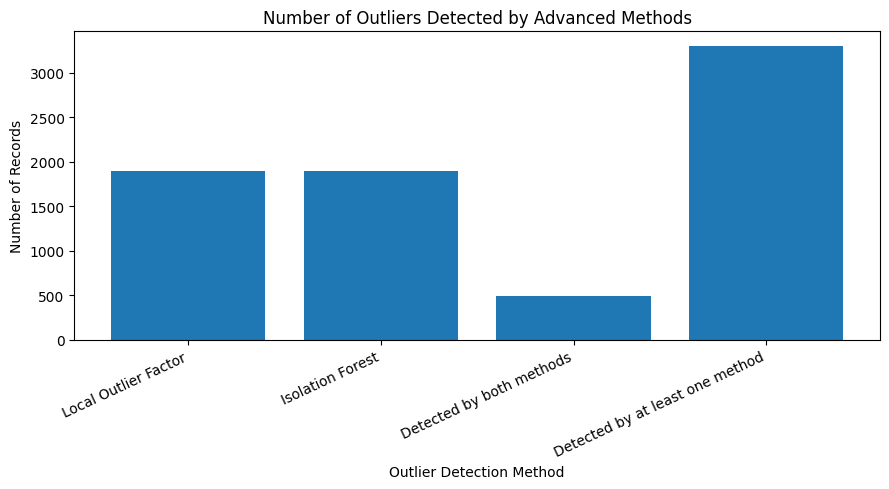


Outlier count comparison figure saved to:
/content/road_crash_outputs/outlier_detection/fig_outlier_count_comparison.png


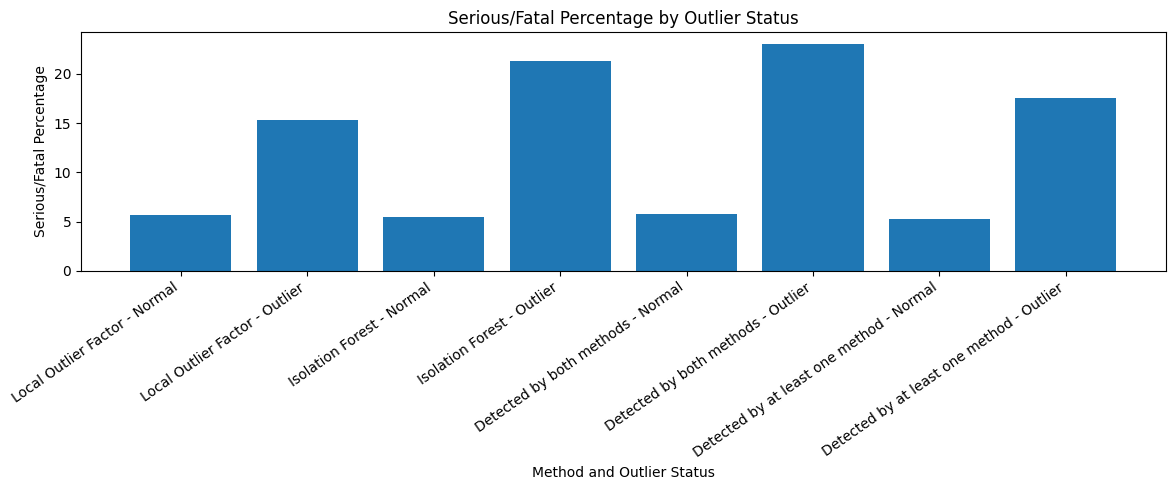


Outlier Serious/Fatal percentage figure saved to:
/content/road_crash_outputs/outlier_detection/fig_outlier_serious_fatal_percentage.png

Outlier method explanation saved to:
/content/road_crash_outputs/outlier_detection/outlier_method_explanation_for_report.csv


,method,what_it_does,why_used_in_this_project,supervisor_requirement_addressed,decision_about_removal
0,Local Outlier Factor,Detects observations that have much lower loca...,Useful for identifying crash records with unus...,Advanced outlier detection beyond IQR.,"Outliers are flagged and analysed, not automat..."
1,Isolation Forest,Detects observations that are easier to isolat...,Useful for identifying globally unusual crash ...,Advanced outlier detection beyond IQR.,"Outliers are flagged and analysed, not automat..."



Report-ready outlier interpretation saved to:
/content/road_crash_outputs/report_materials/advanced_outlier_detection_interpretation.csv


,section,report_ready_interpretation
0,Advanced outlier detection,Advanced outlier detection was conducted using...



Report note:
Use this section to replace the previous IQR-only outlier discussion.
Mention clearly that LOF and Isolation Forest were used.
Do not say outliers were automatically removed.
Explain that unusual crash records may represent real high-risk events.

Cell 18 completed successfully.
Next: Run Cell 19 for train-test split and class imbalance-aware evaluation setup.


In [24]:
# ============================================================
# Cell 18: Advanced outlier detection using LOF and Isolation Forest
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 18: Advanced outlier detection - LOF and Isolation Forest")
print("=" * 70)

# ------------------------------------------------------------
# Supervisor requirement:
# Do not rely only on IQR.
# Use advanced outlier detection methods:
# 1. Local Outlier Factor
# 2. Isolation Forest
#
# Important:
# Outliers are NOT removed automatically.
# In crash data, unusual records may represent real high-risk events.
# ------------------------------------------------------------

outlier_df = df_model_ready.copy()

# ------------------------------------------------------------
# 1. Select numeric features only
# ------------------------------------------------------------
outlier_numeric_features = [
    col for col in numeric_features
    if col in X.columns
]

print("Number of numeric features used for outlier detection:", len(outlier_numeric_features))

if len(outlier_numeric_features) == 0:
    raise ValueError("No numeric features found for outlier detection.")

X_outlier_numeric = X[outlier_numeric_features].copy()

# ------------------------------------------------------------
# 2. Impute and standardise numeric features
# ------------------------------------------------------------
outlier_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

X_outlier_processed = outlier_preprocessor.fit_transform(X_outlier_numeric)

print("Processed numeric matrix shape:", X_outlier_processed.shape)

# ------------------------------------------------------------
# 3. Local Outlier Factor
# ------------------------------------------------------------
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03
)

lof_labels = lof_model.fit_predict(X_outlier_processed)

# LOF output:
# -1 = outlier
#  1 = normal
lof_outlier_flag = (lof_labels == -1).astype(int)

# Higher negative_outlier_factor_ means less abnormal;
# more negative means more abnormal.
lof_scores = lof_model.negative_outlier_factor_

# ------------------------------------------------------------
# 4. Isolation Forest
# ------------------------------------------------------------
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_labels = iso_model.fit_predict(X_outlier_processed)

# Isolation Forest output:
# -1 = outlier
#  1 = normal
iso_outlier_flag = (iso_labels == -1).astype(int)

# Lower score means more abnormal
iso_scores = iso_model.decision_function(X_outlier_processed)

# ------------------------------------------------------------
# 5. Create outlier result table
# ------------------------------------------------------------
outlier_results = pd.DataFrame({
    "row_index": X.index,
    TARGET_COL: y.values,
    "lof_outlier": lof_outlier_flag,
    "lof_score": lof_scores,
    "isolation_forest_outlier": iso_outlier_flag,
    "isolation_forest_score": iso_scores
})

if "report_id" in df_model_ready.columns:
    outlier_results.insert(
        1,
        "report_id",
        df_model_ready.loc[X.index, "report_id"].values
    )

outlier_results["outlier_detected_by_both"] = (
    (outlier_results["lof_outlier"] == 1) &
    (outlier_results["isolation_forest_outlier"] == 1)
).astype(int)

outlier_results["outlier_detected_by_any"] = (
    (outlier_results["lof_outlier"] == 1) |
    (outlier_results["isolation_forest_outlier"] == 1)
).astype(int)

outlier_results_path = f"{OUTLIER_DIR}/advanced_outlier_detection_results.csv"
outlier_results.to_csv(outlier_results_path, index=False)

print("\nAdvanced outlier detection results saved to:")
print(outlier_results_path)

display(outlier_results.head())

# ------------------------------------------------------------
# 6. Outlier summary table
# ------------------------------------------------------------
total_records = len(outlier_results)

lof_count = int(outlier_results["lof_outlier"].sum())
iso_count = int(outlier_results["isolation_forest_outlier"].sum())
both_count = int(outlier_results["outlier_detected_by_both"].sum())
any_count = int(outlier_results["outlier_detected_by_any"].sum())

outlier_summary = pd.DataFrame({
    "method": [
        "Local Outlier Factor",
        "Isolation Forest",
        "Detected by both methods",
        "Detected by at least one method"
    ],
    "contamination_setting": [
        "0.03",
        "0.03",
        "Not applicable",
        "Not applicable"
    ],
    "outlier_count": [
        lof_count,
        iso_count,
        both_count,
        any_count
    ],
    "outlier_percentage": [
        round(lof_count / total_records * 100, 2),
        round(iso_count / total_records * 100, 2),
        round(both_count / total_records * 100, 2),
        round(any_count / total_records * 100, 2)
    ],
    "interpretation": [
        "Detects locally unusual records based on neighbour density.",
        "Detects records that are easier to isolate using random trees.",
        "Most conservative outlier group because both methods agree.",
        "Broad outlier group because at least one method flags the record."
    ]
})

outlier_summary_path = f"{OUTLIER_DIR}/advanced_outlier_detection_summary.csv"
outlier_summary.to_csv(outlier_summary_path, index=False)

print("\nAdvanced outlier detection summary saved to:")
print(outlier_summary_path)

display(outlier_summary)

# ------------------------------------------------------------
# 7. Outlier distribution by crash severity
# ------------------------------------------------------------
outlier_severity_summary = []

for method_col, method_name in [
    ("lof_outlier", "Local Outlier Factor"),
    ("isolation_forest_outlier", "Isolation Forest"),
    ("outlier_detected_by_both", "Detected by both methods"),
    ("outlier_detected_by_any", "Detected by at least one method")
]:
    temp = (
        outlier_results
        .groupby([method_col, TARGET_COL])
        .size()
        .reset_index(name="count")
    )

    temp["method"] = method_name
    temp["outlier_status"] = temp[method_col].map({
        0: "Normal",
        1: "Outlier"
    })

    temp = temp[
        [
            "method",
            "outlier_status",
            TARGET_COL,
            "count"
        ]
    ]

    outlier_severity_summary.append(temp)

outlier_severity_summary = pd.concat(
    outlier_severity_summary,
    ignore_index=True
)

outlier_severity_path = f"{OUTLIER_DIR}/outlier_distribution_by_severity.csv"
outlier_severity_summary.to_csv(outlier_severity_path, index=False)

print("\nOutlier distribution by severity saved to:")
print(outlier_severity_path)

display(outlier_severity_summary)

# ------------------------------------------------------------
# 8. Serious/Fatal percentage among normal vs outlier records
# ------------------------------------------------------------
serious_fatal_labels = ["3: SI", "4: Fatal"]

outlier_risk_records = []

for method_col, method_name in [
    ("lof_outlier", "Local Outlier Factor"),
    ("isolation_forest_outlier", "Isolation Forest"),
    ("outlier_detected_by_both", "Detected by both methods"),
    ("outlier_detected_by_any", "Detected by at least one method")
]:
    temp = (
        outlier_results
        .groupby(method_col)[TARGET_COL]
        .agg(
            total_records="count",
            serious_fatal_count=lambda x: x.isin(serious_fatal_labels).sum(),
            serious_fatal_percentage=lambda x: x.isin(serious_fatal_labels).mean() * 100
        )
        .reset_index()
    )

    temp["method"] = method_name
    temp["outlier_status"] = temp[method_col].map({
        0: "Normal",
        1: "Outlier"
    })

    temp["serious_fatal_percentage"] = temp["serious_fatal_percentage"].round(2)

    temp = temp[
        [
            "method",
            "outlier_status",
            "total_records",
            "serious_fatal_count",
            "serious_fatal_percentage"
        ]
    ]

    outlier_risk_records.append(temp)

outlier_risk_summary = pd.concat(
    outlier_risk_records,
    ignore_index=True
)

outlier_risk_summary_path = f"{OUTLIER_DIR}/outlier_serious_fatal_risk_summary.csv"
outlier_risk_summary.to_csv(outlier_risk_summary_path, index=False)

print("\nOutlier Serious/Fatal risk summary saved to:")
print(outlier_risk_summary_path)

display(outlier_risk_summary)

# ------------------------------------------------------------
# 9. Feature profile of outliers
# Compare numeric feature mean values for normal vs outlier records.
# ------------------------------------------------------------
profile_records = []

for method_col, method_name in [
    ("lof_outlier", "Local Outlier Factor"),
    ("isolation_forest_outlier", "Isolation Forest"),
    ("outlier_detected_by_both", "Detected by both methods")
]:
    normal_idx = outlier_results[method_col] == 0
    outlier_idx = outlier_results[method_col] == 1

    for feature in outlier_numeric_features:
        normal_mean = X_outlier_numeric.loc[normal_idx.values, feature].mean()
        outlier_mean = X_outlier_numeric.loc[outlier_idx.values, feature].mean()

        profile_records.append({
            "method": method_name,
            "feature": feature,
            "normal_mean": normal_mean,
            "outlier_mean": outlier_mean,
            "absolute_mean_difference": abs(outlier_mean - normal_mean)
        })

outlier_feature_profile = pd.DataFrame(profile_records)

outlier_feature_profile = outlier_feature_profile.sort_values(
    ["method", "absolute_mean_difference"],
    ascending=[True, False]
)

outlier_feature_profile_path = f"{OUTLIER_DIR}/outlier_numeric_feature_profile.csv"
outlier_feature_profile.to_csv(outlier_feature_profile_path, index=False)

print("\nOutlier numeric feature profile saved to:")
print(outlier_feature_profile_path)

display(outlier_feature_profile.head(30))

# ------------------------------------------------------------
# 10. Plot outlier count comparison
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.bar(
    outlier_summary["method"],
    outlier_summary["outlier_count"]
)
plt.title("Number of Outliers Detected by Advanced Methods")
plt.xlabel("Outlier Detection Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

outlier_count_fig_path = f"{OUTLIER_DIR}/fig_outlier_count_comparison.png"
plt.savefig(outlier_count_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nOutlier count comparison figure saved to:")
print(outlier_count_fig_path)

# ------------------------------------------------------------
# 11. Plot Serious/Fatal percentage by outlier status
# ------------------------------------------------------------
plot_risk = outlier_risk_summary.copy()
plot_risk["plot_label"] = (
    plot_risk["method"] + " - " + plot_risk["outlier_status"]
)

plt.figure(figsize=(12, 5))
plt.bar(
    plot_risk["plot_label"],
    plot_risk["serious_fatal_percentage"]
)
plt.title("Serious/Fatal Percentage by Outlier Status")
plt.xlabel("Method and Outlier Status")
plt.ylabel("Serious/Fatal Percentage")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

outlier_risk_fig_path = f"{OUTLIER_DIR}/fig_outlier_serious_fatal_percentage.png"
plt.savefig(outlier_risk_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nOutlier Serious/Fatal percentage figure saved to:")
print(outlier_risk_fig_path)

# ------------------------------------------------------------
# 12. Report-ready method explanation table
# ------------------------------------------------------------
outlier_method_explanation = pd.DataFrame({
    "method": [
        "Local Outlier Factor",
        "Isolation Forest"
    ],
    "what_it_does": [
        "Detects observations that have much lower local density than their nearby neighbours.",
        "Detects observations that are easier to isolate through random tree partitioning."
    ],
    "why_used_in_this_project": [
        "Useful for identifying crash records with unusual numeric patterns compared with similar records.",
        "Useful for identifying globally unusual crash records across multiple numeric features."
    ],
    "supervisor_requirement_addressed": [
        "Advanced outlier detection beyond IQR.",
        "Advanced outlier detection beyond IQR."
    ],
    "decision_about_removal": [
        "Outliers are flagged and analysed, not automatically removed.",
        "Outliers are flagged and analysed, not automatically removed."
    ]
})

outlier_method_explanation_path = f"{OUTLIER_DIR}/outlier_method_explanation_for_report.csv"
outlier_method_explanation.to_csv(outlier_method_explanation_path, index=False)

print("\nOutlier method explanation saved to:")
print(outlier_method_explanation_path)

display(outlier_method_explanation)

# ------------------------------------------------------------
# 13. Report-ready interpretation
# ------------------------------------------------------------
interpretation_text = (
    f"Advanced outlier detection was conducted using Local Outlier Factor and Isolation Forest. "
    f"LOF identified {lof_count} records ({round(lof_count / total_records * 100, 2)}%) as outliers, "
    f"while Isolation Forest identified {iso_count} records ({round(iso_count / total_records * 100, 2)}%). "
    f"A total of {both_count} records were flagged by both methods, representing the most conservative outlier group. "
    f"Outliers were not automatically removed because extreme crash records may represent genuine high-risk situations rather than data errors. "
    f"Instead, the outlier groups were profiled and compared against crash severity to understand whether unusual records were associated with serious or fatal outcomes."
)

outlier_interpretation = pd.DataFrame({
    "section": ["Advanced outlier detection"],
    "report_ready_interpretation": [interpretation_text]
})

outlier_interpretation_path = f"{REPORT_DIR}/advanced_outlier_detection_interpretation.csv"
outlier_interpretation.to_csv(outlier_interpretation_path, index=False)

print("\nReport-ready outlier interpretation saved to:")
print(outlier_interpretation_path)

display(outlier_interpretation)

# ------------------------------------------------------------
# 14. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Use this section to replace the previous IQR-only outlier discussion.")
print("Mention clearly that LOF and Isolation Forest were used.")
print("Do not say outliers were automatically removed.")
print("Explain that unusual crash records may represent real high-risk events.")

print("\nCell 18 completed successfully.")
print("Next: Run Cell 19 for train-test split and class imbalance-aware evaluation setup.")

In [25]:
# ============================================================
# Cell 19: Train-test split and class imbalance-aware evaluation setup
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 19: Train-test split and evaluation setup")
print("=" * 70)

# ------------------------------------------------------------
# This cell prepares the modelling stage.
#
# Key supervisor-aligned points:
# 1. Use stratified train-test split because the target is imbalanced.
# 2. Evaluate with macro F1, balanced accuracy, recall, precision.
# 3. Do not rely only on accuracy.
# 4. Save class distribution tables for the report.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Train-test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X,
    y,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target length:", len(y_train))
print("Testing target length :", len(y_test))


# ------------------------------------------------------------
# 2. Save train-test split summary
# ------------------------------------------------------------
split_summary = pd.DataFrame({
    "dataset_part": ["Training set", "Testing set", "Total"],
    "records": [len(y_train), len(y_test), len(y)],
    "percentage": [
        round(len(y_train) / len(y) * 100, 2),
        round(len(y_test) / len(y) * 100, 2),
        100.00
    ]
})

split_summary_path = f"{TABLE_DIR}/train_test_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False)

print("\nTrain-test split summary saved to:")
print(split_summary_path)

display(split_summary)


# ------------------------------------------------------------
# 3. Class distribution helper
# ------------------------------------------------------------
def create_class_distribution_table(y_values, dataset_name):
    table = (
        pd.Series(y_values)
        .value_counts()
        .rename_axis("severity_class")
        .reset_index(name="count")
    )

    table["percentage"] = (
        table["count"] / table["count"].sum() * 100
    ).round(2)

    severity_order = ["1: PDO", "2: MI", "3: SI", "4: Fatal"]

    table["severity_order"] = table["severity_class"].apply(
        lambda x: severity_order.index(x) if x in severity_order else 999
    )

    table = (
        table
        .sort_values("severity_order")
        .drop(columns=["severity_order"])
        .reset_index(drop=True)
    )

    table.insert(0, "dataset_part", dataset_name)

    return table


train_class_distribution = create_class_distribution_table(
    y_train,
    "Training set"
)

test_class_distribution = create_class_distribution_table(
    y_test,
    "Testing set"
)

full_class_distribution = create_class_distribution_table(
    y,
    "Full dataset"
)

split_class_distribution = pd.concat(
    [
        full_class_distribution,
        train_class_distribution,
        test_class_distribution
    ],
    ignore_index=True
)

split_class_distribution_path = f"{TABLE_DIR}/train_test_class_distribution.csv"
split_class_distribution.to_csv(split_class_distribution_path, index=False)

print("\nTrain-test class distribution saved to:")
print(split_class_distribution_path)

display(split_class_distribution)


# ------------------------------------------------------------
# 4. Cross-validation setup
# ------------------------------------------------------------
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nCross-validation strategy:")
print("StratifiedKFold with 3 folds, shuffle=True")


# ------------------------------------------------------------
# 5. Evaluation scoring setup
# ------------------------------------------------------------
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

scoring_table = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro precision",
        "Macro recall",
        "Macro F1-score",
        "Weighted F1-score"
    ],
    "sklearn_scoring_name": [
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted"
    ],
    "why_used": [
        "Shows overall correct predictions, but can be misleading with class imbalance.",
        "Accounts for class imbalance by averaging recall across classes.",
        "Gives equal importance to each class when calculating precision.",
        "Gives equal importance to each class when calculating recall.",
        "Main comparison metric because it balances precision and recall equally across all classes.",
        "Considers class frequency and shows overall weighted performance."
    ],
    "importance_for_this_project": [
        "Reported for completeness only.",
        "Important because Fatal and Serious Injury classes are rare.",
        "Important because minority class false alarms should be considered.",
        "Important because missing Serious/Fatal crashes is costly.",
        "Primary model selection metric for imbalanced severity classification.",
        "Useful secondary metric for overall model behaviour."
    ]
})

scoring_table_path = f"{TABLE_DIR}/evaluation_metric_explanation.csv"
scoring_table.to_csv(scoring_table_path, index=False)

print("\nEvaluation metric explanation saved to:")
print(scoring_table_path)

display(scoring_table)


# ------------------------------------------------------------
# 6. Helper function for single model evaluation on test set
# ------------------------------------------------------------
def evaluate_predictions(model_name, y_true, y_pred, y_true_encoded=None, y_proba=None):
    """
    Evaluates a trained model using class-imbalance-aware metrics.
    ROC-AUC is calculated only when class probabilities are available.
    """

    result = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_true, y_pred), 4),
        "macro_precision": round(
            precision_score(y_true, y_pred, average="macro", zero_division=0),
            4
        ),
        "macro_recall": round(
            recall_score(y_true, y_pred, average="macro", zero_division=0),
            4
        ),
        "macro_f1": round(
            f1_score(y_true, y_pred, average="macro", zero_division=0),
            4
        ),
        "weighted_f1": round(
            f1_score(y_true, y_pred, average="weighted", zero_division=0),
            4
        )
    }

    # Multi-class ROC-AUC if probability estimates are available
    if y_proba is not None and y_true_encoded is not None:
        try:
            result["roc_auc_ovr_weighted"] = round(
                roc_auc_score(
                    y_true_encoded,
                    y_proba,
                    multi_class="ovr",
                    average="weighted"
                ),
                4
            )
        except Exception:
            result["roc_auc_ovr_weighted"] = np.nan
    else:
        result["roc_auc_ovr_weighted"] = np.nan

    return result


# ------------------------------------------------------------
# 7. Helper function for classification report table
# ------------------------------------------------------------
def save_classification_report_table(model_name, y_true, y_pred):
    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose().reset_index()
    report_df = report_df.rename(columns={"index": "class_or_average"})
    report_df.insert(0, "model", model_name)

    safe_model_name = clean_column_name(model_name)
    report_path = f"{MODEL_DIR}/classification_report_{safe_model_name}.csv"
    report_df.to_csv(report_path, index=False)

    print(f"Classification report saved for {model_name}:")
    print(report_path)

    return report_df


# ------------------------------------------------------------
# 8. Helper function for confusion matrix plot
# ------------------------------------------------------------
def save_confusion_matrix_plot(model_name, y_true, y_pred):
    labels = list(target_encoder.classes_)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels]
    )

    safe_model_name = clean_column_name(model_name)

    cm_table_path = f"{MODEL_DIR}/confusion_matrix_{safe_model_name}.csv"
    cm_df.to_csv(cm_table_path)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(
        ax=ax,
        cmap=None,
        values_format="d",
        colorbar=False
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    cm_fig_path = f"{MODEL_DIR}/confusion_matrix_{safe_model_name}.png"
    plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Confusion matrix table saved for {model_name}:")
    print(cm_table_path)
    print(f"Confusion matrix figure saved for {model_name}:")
    print(cm_fig_path)

    return cm_df


# ------------------------------------------------------------
# 9. Helper function for cross-validation result table
# ------------------------------------------------------------
def run_cross_validation(model_name, pipeline, X_train_data, y_train_data):
    cv_results = cross_validate(
        pipeline,
        X_train_data,
        y_train_data,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    summary = {
        "model": model_name
    }

    for metric_name in scoring.keys():
        scores = cv_results[f"test_{metric_name}"]
        summary[f"{metric_name}_mean"] = round(scores.mean(), 4)
        summary[f"{metric_name}_std"] = round(scores.std(), 4)

    cv_summary_df = pd.DataFrame([summary])

    safe_model_name = clean_column_name(model_name)
    cv_path = f"{MODEL_DIR}/cross_validation_{safe_model_name}.csv"
    cv_summary_df.to_csv(cv_path, index=False)

    print(f"Cross-validation summary saved for {model_name}:")
    print(cv_path)

    return cv_summary_df


# ------------------------------------------------------------
# 10. Model result storage
# ------------------------------------------------------------
model_test_results = []
classification_report_tables = []
cross_validation_tables = []

print("\nEvaluation helper functions created successfully.")
print("Model results will be stored in:")
print(MODEL_DIR)


# ------------------------------------------------------------
# 11. Report-ready interpretation
# ------------------------------------------------------------
split_interpretation = pd.DataFrame({
    "section": ["Train-test split and evaluation setup"],
    "report_ready_interpretation": [
        (
            "The dataset was divided into training and testing sets using an 80:20 stratified split. "
            "Stratification was used because the crash severity classes are highly imbalanced, and it helps preserve "
            "the original class proportions in both training and testing sets. Model evaluation focuses on macro F1-score, "
            "balanced accuracy, macro recall, and weighted F1-score rather than accuracy alone. This is important because "
            "accuracy can hide poor performance on rare but important classes such as Serious Injury and Fatal crashes."
        )
    ]
})

split_interpretation_path = f"{REPORT_DIR}/train_test_evaluation_setup_interpretation.csv"
split_interpretation.to_csv(split_interpretation_path, index=False)

print("\nReport-ready train-test interpretation saved to:")
print(split_interpretation_path)

display(split_interpretation)


print("\nCell 19 completed successfully.")
print("Next: Run Cell 20 to train baseline and required classifiers: Dummy, Naive Bayes, Logistic Regression, SVM, Decision Tree, and Random Forest.")

Cell 19: Train-test split and evaluation setup
Training feature shape: (50591, 65)
Testing feature shape : (12648, 65)
Training target length: 50591
Testing target length : 12648

Train-test split summary saved to:
/content/road_crash_outputs/tables/train_test_split_summary.csv


,dataset_part,records,percentage
0,Training set,50591,80.0
1,Testing set,12648,20.0
2,Total,63239,100.0



Train-test class distribution saved to:
/content/road_crash_outputs/tables/train_test_class_distribution.csv


,dataset_part,severity_class,count,percentage
0,Full dataset,1: PDO,43768,69.21
1,Full dataset,2: MI,15711,24.84
2,Full dataset,3: SI,3323,5.25
3,Full dataset,4: Fatal,437,0.69
4,Training set,1: PDO,35014,69.21
5,Training set,2: MI,12569,24.84
6,Training set,3: SI,2658,5.25
7,Training set,4: Fatal,350,0.69
8,Testing set,1: PDO,8754,69.21
9,Testing set,2: MI,3142,24.84



Cross-validation strategy:
StratifiedKFold with 3 folds, shuffle=True

Evaluation metric explanation saved to:
/content/road_crash_outputs/tables/evaluation_metric_explanation.csv


,metric,sklearn_scoring_name,why_used,importance_for_this_project
0,Accuracy,accuracy,"Shows overall correct predictions, but can be ...",Reported for completeness only.
1,Balanced accuracy,balanced_accuracy,Accounts for class imbalance by averaging reca...,Important because Fatal and Serious Injury cla...
2,Macro precision,precision_macro,Gives equal importance to each class when calc...,Important because minority class false alarms ...
3,Macro recall,recall_macro,Gives equal importance to each class when calc...,Important because missing Serious/Fatal crashe...
4,Macro F1-score,f1_macro,Main comparison metric because it balances pre...,Primary model selection metric for imbalanced ...
5,Weighted F1-score,f1_weighted,Considers class frequency and shows overall we...,Useful secondary metric for overall model beha...



Evaluation helper functions created successfully.
Model results will be stored in:
/content/road_crash_outputs/model_results

Report-ready train-test interpretation saved to:
/content/road_crash_outputs/report_materials/train_test_evaluation_setup_interpretation.csv


,section,report_ready_interpretation
0,Train-test split and evaluation setup,The dataset was divided into training and test...



Cell 19 completed successfully.
Next: Run Cell 20 to train baseline and required classifiers: Dummy, Naive Bayes, Logistic Regression, SVM, Decision Tree, and Random Forest.


Cell 20: Train required classifiers

Model selection explanation saved to:
/content/road_crash_outputs/tables/model_selection_explanation.csv


,model,reason_for_inclusion,imbalance_handling,preprocessing_used
0,Dummy Baseline,Provides a minimum baseline by always predicti...,No class balancing; used only as baseline.,"Imputation, rare grouping, one-hot encoding, s..."
1,Naive Bayes,Required simple probabilistic classifier cover...,No direct class weighting in GaussianNB.,"Imputation, rare grouping, one-hot encoding, s..."
2,Logistic Regression,Provides an interpretable linear classificatio...,class_weight='balanced',"Imputation, rare grouping, one-hot encoding, s..."
3,Support Vector Machine,Required margin-based classifier covered in th...,class_weight='balanced',"Imputation, rare grouping, one-hot encoding, s..."
4,Decision Tree,Provides interpretable nonlinear classificatio...,class_weight='balanced',"Imputation, rare grouping, one-hot encoding, s..."
5,Random Forest,Provides stronger ensemble learning model and ...,class_weight='balanced',"Imputation, rare grouping, one-hot encoding, s..."



Training model: Dummy Baseline
Running cross-validation for Dummy Baseline...
Cross-validation summary saved for Dummy Baseline:
/content/road_crash_outputs/model_results/cross_validation_dummy_baseline.csv
Fitting Dummy Baseline on full training set...
Classification report saved for Dummy Baseline:
/content/road_crash_outputs/model_results/classification_report_dummy_baseline.csv


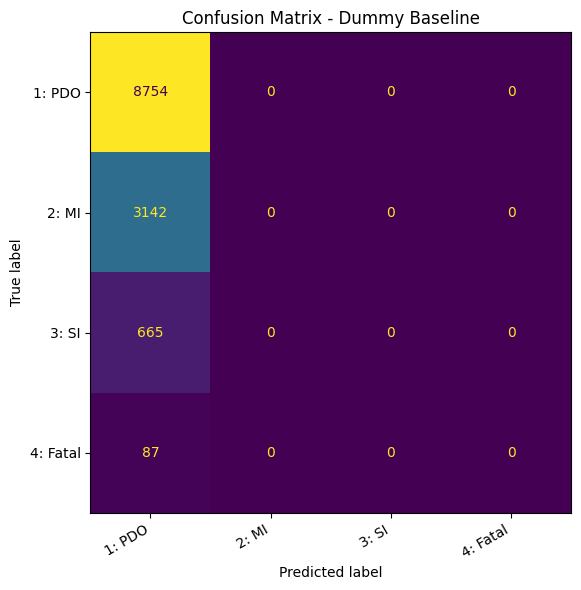

Confusion matrix table saved for Dummy Baseline:
/content/road_crash_outputs/model_results/confusion_matrix_dummy_baseline.csv
Confusion matrix figure saved for Dummy Baseline:
/content/road_crash_outputs/model_results/confusion_matrix_dummy_baseline.png

Completed model: Dummy Baseline
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Dummy Baseline,0.6921,0.25,0.173,0.25,0.2045,0.5662,0.5,8.97



Training model: Naive Bayes
Running cross-validation for Naive Bayes...
Cross-validation summary saved for Naive Bayes:
/content/road_crash_outputs/model_results/cross_validation_naive_bayes.csv
Fitting Naive Bayes on full training set...
Classification report saved for Naive Bayes:
/content/road_crash_outputs/model_results/classification_report_naive_bayes.csv


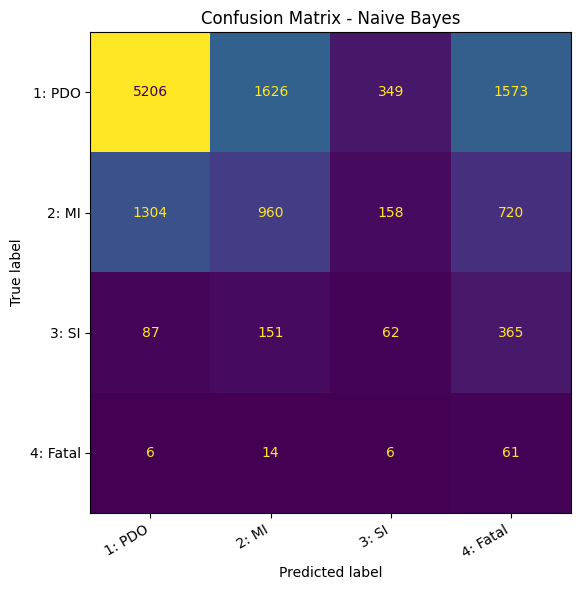

Confusion matrix table saved for Naive Bayes:
/content/road_crash_outputs/model_results/confusion_matrix_naive_bayes.csv
Confusion matrix figure saved for Naive Bayes:
/content/road_crash_outputs/model_results/confusion_matrix_naive_bayes.png

Completed model: Naive Bayes
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Naive Bayes,0.4972,0.4237,0.3169,0.4237,0.2868,0.5558,0.6573,6.09



Training model: Logistic Regression
Running cross-validation for Logistic Regression...
Cross-validation summary saved for Logistic Regression:
/content/road_crash_outputs/model_results/cross_validation_logistic_regression.csv
Fitting Logistic Regression on full training set...
Classification report saved for Logistic Regression:
/content/road_crash_outputs/model_results/classification_report_logistic_regression.csv


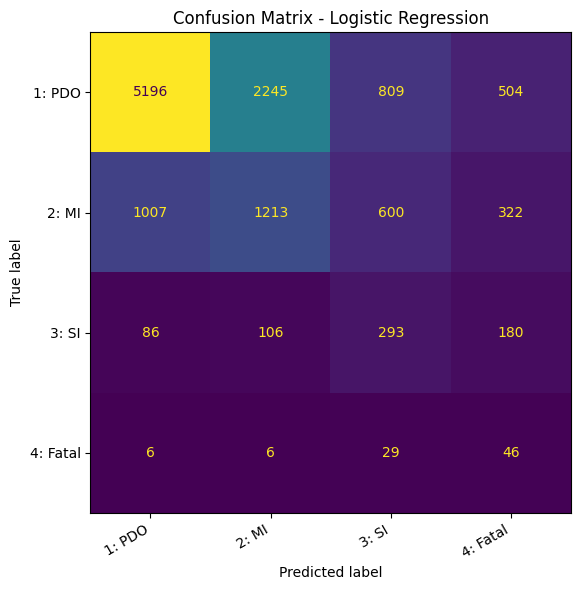

Confusion matrix table saved for Logistic Regression:
/content/road_crash_outputs/model_results/confusion_matrix_logistic_regression.csv
Confusion matrix figure saved for Logistic Regression:
/content/road_crash_outputs/model_results/confusion_matrix_logistic_regression.png

Completed model: Logistic Regression
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Logistic Regression,0.5335,0.4872,0.3445,0.4872,0.3443,0.5811,0.6938,41.63



Training model: Support Vector Machine
Running cross-validation for Support Vector Machine...
Cross-validation summary saved for Support Vector Machine:
/content/road_crash_outputs/model_results/cross_validation_support_vector_machine.csv
Fitting Support Vector Machine on full training set...
Classification report saved for Support Vector Machine:
/content/road_crash_outputs/model_results/classification_report_support_vector_machine.csv


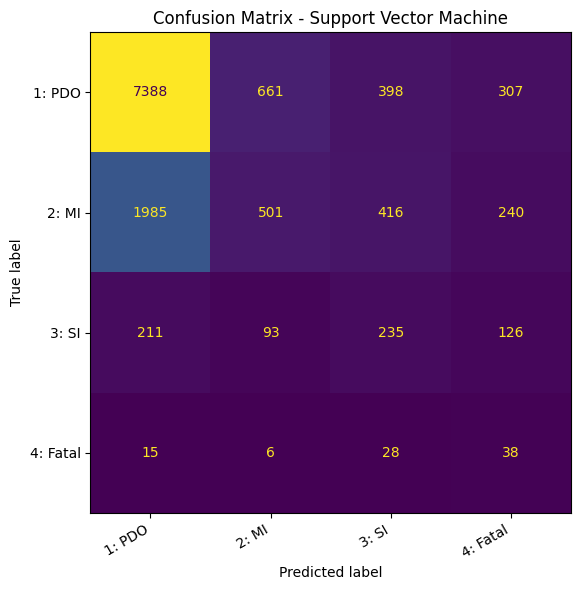

Confusion matrix table saved for Support Vector Machine:
/content/road_crash_outputs/model_results/confusion_matrix_support_vector_machine.csv
Confusion matrix figure saved for Support Vector Machine:
/content/road_crash_outputs/model_results/confusion_matrix_support_vector_machine.png

Completed model: Support Vector Machine
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Support Vector Machine,0.6453,0.4484,0.3597,0.4484,0.3494,0.6286,NaN,62.34



Training model: Decision Tree
Running cross-validation for Decision Tree...
Cross-validation summary saved for Decision Tree:
/content/road_crash_outputs/model_results/cross_validation_decision_tree.csv
Fitting Decision Tree on full training set...
Classification report saved for Decision Tree:
/content/road_crash_outputs/model_results/classification_report_decision_tree.csv


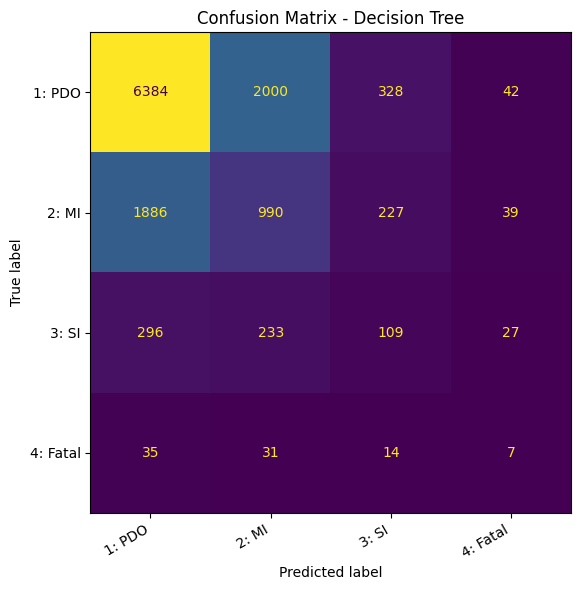

Confusion matrix table saved for Decision Tree:
/content/road_crash_outputs/model_results/confusion_matrix_decision_tree.csv
Confusion matrix figure saved for Decision Tree:
/content/road_crash_outputs/model_results/confusion_matrix_decision_tree.png

Completed model: Decision Tree
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Decision Tree,0.5922,0.3222,0.317,0.3222,0.3192,0.5951,0.5682,12.46



Training model: Random Forest
Running cross-validation for Random Forest...
Cross-validation summary saved for Random Forest:
/content/road_crash_outputs/model_results/cross_validation_random_forest.csv
Fitting Random Forest on full training set...
Classification report saved for Random Forest:
/content/road_crash_outputs/model_results/classification_report_random_forest.csv


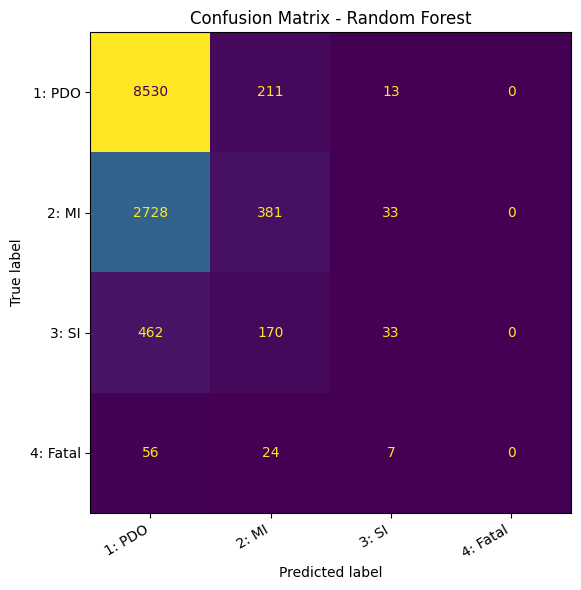

Confusion matrix table saved for Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_random_forest.csv
Confusion matrix figure saved for Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_random_forest.png

Completed model: Random Forest
Test results:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Random Forest,0.7071,0.2863,0.3982,0.2863,0.2782,0.628,0.723,46.21



Final model test performance comparison saved to:
/content/road_crash_outputs/model_results/model_test_performance_comparison.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds
0,Support Vector Machine,0.6453,0.4484,0.3597,0.4484,0.3494,0.6286,NaN,62.34
1,Logistic Regression,0.5335,0.4872,0.3445,0.4872,0.3443,0.5811,0.6938,41.63
2,Decision Tree,0.5922,0.3222,0.3170,0.3222,0.3192,0.5951,0.5682,12.46
3,Naive Bayes,0.4972,0.4237,0.3169,0.4237,0.2868,0.5558,0.6573,6.09
4,Random Forest,0.7071,0.2863,0.3982,0.2863,0.2782,0.6280,0.7230,46.21
5,Dummy Baseline,0.6921,0.2500,0.1730,0.2500,0.2045,0.5662,0.5000,8.97



Final cross-validation comparison saved to:
/content/road_crash_outputs/model_results/model_cross_validation_comparison.csv


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Support Vector Machine,0.6513,0.0033,0.4574,0.0122,0.3693,0.0042,0.4574,0.0122,0.3572,0.0032,0.6357,0.0030
1,Logistic Regression,0.5354,0.0031,0.4893,0.0194,0.3450,0.0017,0.4893,0.0194,0.3447,0.0023,0.5833,0.0027
2,Decision Tree,0.5954,0.0019,0.3188,0.0032,0.3138,0.0025,0.3188,0.0032,0.3160,0.0028,0.5993,0.0025
3,Random Forest,0.7072,0.0006,0.2864,0.0011,0.4252,0.0119,0.2864,0.0011,0.2786,0.0018,0.6274,0.0007
4,Naive Bayes,0.4587,0.0108,0.4300,0.0076,0.3222,0.0034,0.4300,0.0076,0.2743,0.0104,0.5295,0.0078
5,Dummy Baseline,0.6921,0.0000,0.2500,0.0000,0.1730,0.0000,0.2500,0.0000,0.2045,0.0000,0.5662,0.0000



All classification reports saved to:
/content/road_crash_outputs/model_results/all_model_classification_reports.csv


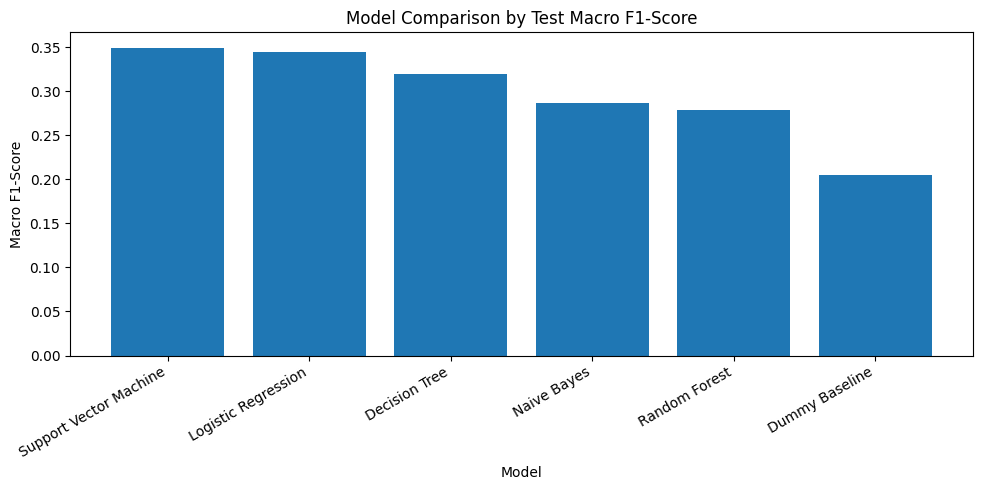


Macro F1 model comparison figure saved to:
/content/road_crash_outputs/model_results/fig_model_comparison_macro_f1.png


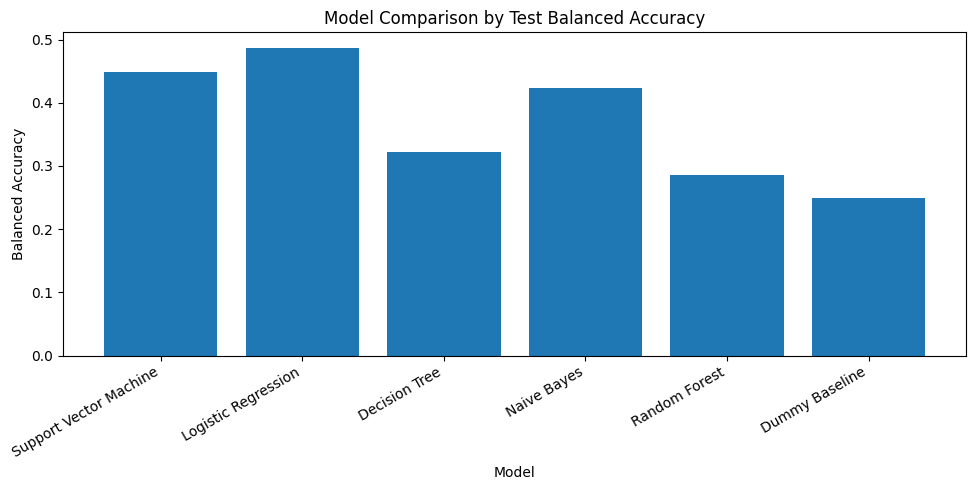


Balanced accuracy model comparison figure saved to:
/content/road_crash_outputs/model_results/fig_model_comparison_balanced_accuracy.png

Best untuned model summary saved to:
/content/road_crash_outputs/model_results/best_untuned_model_summary.csv


,item,value
0,Best untuned model based on test macro F1,Support Vector Machine
1,Best test macro F1,0.3494
2,Main model selection metric,Macro F1-score



Report-ready model training interpretation saved to:
/content/road_crash_outputs/report_materials/baseline_required_classifier_interpretation.csv


,section,report_ready_interpretation
0,Baseline and required classifier comparison,Six classifiers were trained and compared: Dum...



Cell 20 completed successfully.
Next: Run Cell 21 for PCA / TruncatedSVD experiment.


In [26]:
# ============================================================
# Cell 20: Train baseline and required classifiers
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 20: Train required classifiers")
print("=" * 70)

# ------------------------------------------------------------
# Supervisor requirement:
# Add Naive Bayes and SVM.
#
# Models included:
# 1. Dummy Baseline
# 2. Naive Bayes
# 3. Logistic Regression
# 4. Support Vector Machine
# 5. Decision Tree
# 6. Random Forest
# ------------------------------------------------------------

# ------------------------------------------------------------
# Helper: convert sparse matrix to dense matrix
# Needed for GaussianNB because it does not accept sparse input.
# ------------------------------------------------------------
def sparse_to_dense(X_input):
    if sparse.issparse(X_input):
        return X_input.toarray()
    return X_input


dense_transformer = FunctionTransformer(
    sparse_to_dense,
    accept_sparse=True
)


# ------------------------------------------------------------
# 1. Define model pipelines
# ------------------------------------------------------------
model_pipelines = {
    "Dummy Baseline": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DummyClassifier(
                strategy="most_frequent",
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "Naive Bayes": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("to_dense", dense_transformer),
            ("classifier", GaussianNB())
        ]
    ),

    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),

    "Support Vector Machine": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=5000
            ))
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    )
}


# ------------------------------------------------------------
# 2. Save model explanation table for report
# ------------------------------------------------------------
model_explanation_table = pd.DataFrame({
    "model": [
        "Dummy Baseline",
        "Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine",
        "Decision Tree",
        "Random Forest"
    ],
    "reason_for_inclusion": [
        "Provides a minimum baseline by always predicting the majority class.",
        "Required simple probabilistic classifier covered in the unit.",
        "Provides an interpretable linear classification baseline.",
        "Required margin-based classifier covered in the unit; suitable with standardised features.",
        "Provides interpretable nonlinear classification rules.",
        "Provides stronger ensemble learning model and handles nonlinear feature relationships."
    ],
    "imbalance_handling": [
        "No class balancing; used only as baseline.",
        "No direct class weighting in GaussianNB.",
        "class_weight='balanced'",
        "class_weight='balanced'",
        "class_weight='balanced'",
        "class_weight='balanced'"
    ],
    "preprocessing_used": [
        "Imputation, rare grouping, one-hot encoding, standardisation",
        "Imputation, rare grouping, one-hot encoding, standardisation, dense conversion",
        "Imputation, rare grouping, one-hot encoding, standardisation",
        "Imputation, rare grouping, one-hot encoding, standardisation",
        "Imputation, rare grouping, one-hot encoding, standardisation",
        "Imputation, rare grouping, one-hot encoding, standardisation"
    ]
})

model_explanation_path = f"{TABLE_DIR}/model_selection_explanation.csv"
model_explanation_table.to_csv(model_explanation_path, index=False)

print("\nModel selection explanation saved to:")
print(model_explanation_path)

display(model_explanation_table)


# ------------------------------------------------------------
# 3. Train, cross-validate, and test each model
# ------------------------------------------------------------
trained_models = {}

for model_name, pipeline in model_pipelines.items():
    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    start_time = time.time()

    # Cross-validation on training set
    print(f"Running cross-validation for {model_name}...")
    cv_summary = run_cross_validation(
        model_name,
        pipeline,
        X_train,
        y_train
    )

    cross_validation_tables.append(cv_summary)

    # Fit on full training set
    print(f"Fitting {model_name} on full training set...")
    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

    # Predict on test set
    y_pred = pipeline.predict(X_test)

    # Predict probabilities if available
    y_proba = None
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        try:
            y_proba = pipeline.predict_proba(X_test)
        except Exception:
            y_proba = None

    # Test evaluation
    test_result = evaluate_predictions(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        y_true_encoded=y_test_encoded,
        y_proba=y_proba
    )

    end_time = time.time()
    test_result["training_and_testing_time_seconds"] = round(end_time - start_time, 2)

    model_test_results.append(test_result)

    # Save classification report
    report_df = save_classification_report_table(
        model_name,
        y_test,
        y_pred
    )

    classification_report_tables.append(report_df)

    # Save confusion matrix
    cm_df = save_confusion_matrix_plot(
        model_name,
        y_test,
        y_pred
    )

    print(f"\nCompleted model: {model_name}")
    print("Test results:")
    display(pd.DataFrame([test_result]))


# ------------------------------------------------------------
# 4. Combine test result table
# ------------------------------------------------------------
model_test_results_df = pd.DataFrame(model_test_results)

model_test_results_df = model_test_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

model_test_results_path = f"{MODEL_DIR}/model_test_performance_comparison.csv"
model_test_results_df.to_csv(model_test_results_path, index=False)

print("\nFinal model test performance comparison saved to:")
print(model_test_results_path)

display(model_test_results_df)


# ------------------------------------------------------------
# 5. Combine cross-validation results
# ------------------------------------------------------------
cross_validation_results_df = pd.concat(
    cross_validation_tables,
    ignore_index=True
)

cross_validation_results_df = cross_validation_results_df.sort_values(
    "f1_macro_mean",
    ascending=False
).reset_index(drop=True)

cross_validation_results_path = f"{MODEL_DIR}/model_cross_validation_comparison.csv"
cross_validation_results_df.to_csv(cross_validation_results_path, index=False)

print("\nFinal cross-validation comparison saved to:")
print(cross_validation_results_path)

display(cross_validation_results_df)


# ------------------------------------------------------------
# 6. Combine classification reports
# ------------------------------------------------------------
classification_reports_all = pd.concat(
    classification_report_tables,
    ignore_index=True
)

classification_reports_all_path = f"{MODEL_DIR}/all_model_classification_reports.csv"
classification_reports_all.to_csv(classification_reports_all_path, index=False)

print("\nAll classification reports saved to:")
print(classification_reports_all_path)


# ------------------------------------------------------------
# 7. Plot model comparison by macro F1
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    model_test_results_df["model"],
    model_test_results_df["macro_f1"]
)
plt.title("Model Comparison by Test Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

macro_f1_fig_path = f"{MODEL_DIR}/fig_model_comparison_macro_f1.png"
plt.savefig(macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nMacro F1 model comparison figure saved to:")
print(macro_f1_fig_path)


# ------------------------------------------------------------
# 8. Plot model comparison by balanced accuracy
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    model_test_results_df["model"],
    model_test_results_df["balanced_accuracy"]
)
plt.title("Model Comparison by Test Balanced Accuracy")
plt.xlabel("Model")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

balanced_acc_fig_path = f"{MODEL_DIR}/fig_model_comparison_balanced_accuracy.png"
plt.savefig(balanced_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nBalanced accuracy model comparison figure saved to:")
print(balanced_acc_fig_path)


# ------------------------------------------------------------
# 9. Identify best untuned model
# ------------------------------------------------------------
best_untuned_model_name = model_test_results_df.iloc[0]["model"]
best_untuned_macro_f1 = model_test_results_df.iloc[0]["macro_f1"]

best_model_summary = pd.DataFrame({
    "item": [
        "Best untuned model based on test macro F1",
        "Best test macro F1",
        "Main model selection metric"
    ],
    "value": [
        best_untuned_model_name,
        best_untuned_macro_f1,
        "Macro F1-score"
    ]
})

best_model_summary_path = f"{MODEL_DIR}/best_untuned_model_summary.csv"
best_model_summary.to_csv(best_model_summary_path, index=False)

print("\nBest untuned model summary saved to:")
print(best_model_summary_path)

display(best_model_summary)


# ------------------------------------------------------------
# 10. Report-ready interpretation
# ------------------------------------------------------------
interpretation_text = (
    f"Six classifiers were trained and compared: Dummy Baseline, Naive Bayes, Logistic Regression, "
    f"Support Vector Machine, Decision Tree, and Random Forest. The Dummy Baseline was used to show "
    f"minimum expected performance, while Naive Bayes and SVM were added to align the modelling work "
    f"with the techniques covered in the unit. Because the target variable is imbalanced, the main "
    f"comparison metric was macro F1-score rather than accuracy. Based on the untuned test results, "
    f"the best model was {best_untuned_model_name} with a macro F1-score of {best_untuned_macro_f1}. "
    f"Further hyperparameter optimisation is required before selecting the final model."
)

model_training_interpretation = pd.DataFrame({
    "section": ["Baseline and required classifier comparison"],
    "report_ready_interpretation": [interpretation_text]
})

model_training_interpretation_path = f"{REPORT_DIR}/baseline_required_classifier_interpretation.csv"
model_training_interpretation.to_csv(model_training_interpretation_path, index=False)

print("\nReport-ready model training interpretation saved to:")
print(model_training_interpretation_path)

display(model_training_interpretation)


print("\nCell 20 completed successfully.")
print("Next: Run Cell 21 for PCA / TruncatedSVD experiment.")

## 4. Classification modelling

The model predicts **CSEF Severity**. Direct outcome variables are removed to prevent target leakage.

Cell 21: PCA / TruncatedSVD dimensionality reduction experiment
Checking transformed feature dimension...
Original feature count before preprocessing: 65
Processed feature count after encoding: 199
Number of TruncatedSVD components used: 50

PCA/TruncatedSVD method explanation saved to:
/content/road_crash_outputs/pca_analysis/pca_truncatedsvd_method_explanation.csv


,item,explanation
0,Why dimensionality reduction was needed,One-hot encoding can create a high-dimensional...
1,Why TruncatedSVD was used instead of standard PCA,Standard PCA is designed mainly for dense matr...
2,Number of components,50 components were used to reduce the processe...
3,Models tested with dimensionality reduction,Logistic Regression + TruncatedSVD and SVM + T...
4,How this addresses supervisor feedback,The experiment explicitly tests dimensionality...



Training model: Logistic Regression + TruncatedSVD
Running cross-validation for Logistic Regression + TruncatedSVD...
Cross-validation summary saved for Logistic Regression + TruncatedSVD:
/content/road_crash_outputs/model_results/cross_validation_logistic_regression_truncatedsvd.csv
Fitting Logistic Regression + TruncatedSVD on full training set...
Explained variance table saved to:
/content/road_crash_outputs/pca_analysis/svd_explained_variance_logistic_regression_truncatedsvd.csv
Classification report saved for Logistic Regression + TruncatedSVD:
/content/road_crash_outputs/model_results/classification_report_logistic_regression_truncatedsvd.csv


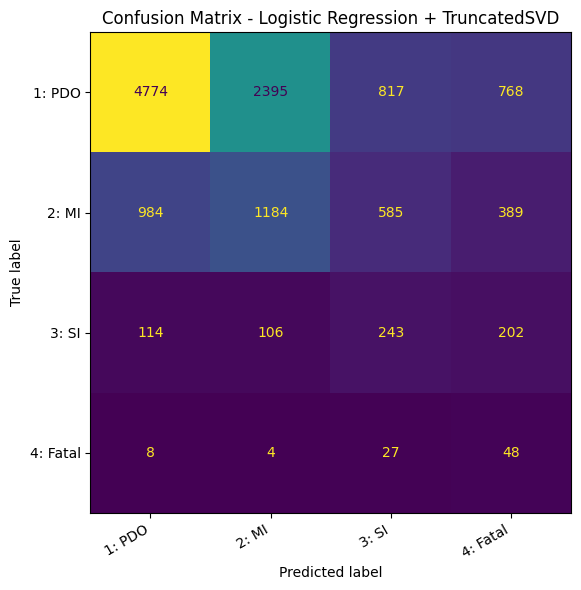

Confusion matrix table saved for Logistic Regression + TruncatedSVD:
/content/road_crash_outputs/model_results/confusion_matrix_logistic_regression_truncatedsvd.csv
Confusion matrix figure saved for Logistic Regression + TruncatedSVD:
/content/road_crash_outputs/model_results/confusion_matrix_logistic_regression_truncatedsvd.png

Completed model: Logistic Regression + TruncatedSVD


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance
0,Logistic Regression + TruncatedSVD,0.4941,0.4598,0.3281,0.4598,0.3178,0.5491,0.6677,17.46,TruncatedSVD,50,0.9151



Training model: SVM + TruncatedSVD
Running cross-validation for SVM + TruncatedSVD...
Cross-validation summary saved for SVM + TruncatedSVD:
/content/road_crash_outputs/model_results/cross_validation_svm_truncatedsvd.csv
Fitting SVM + TruncatedSVD on full training set...
Explained variance table saved to:
/content/road_crash_outputs/pca_analysis/svd_explained_variance_svm_truncatedsvd.csv
Classification report saved for SVM + TruncatedSVD:
/content/road_crash_outputs/model_results/classification_report_svm_truncatedsvd.csv


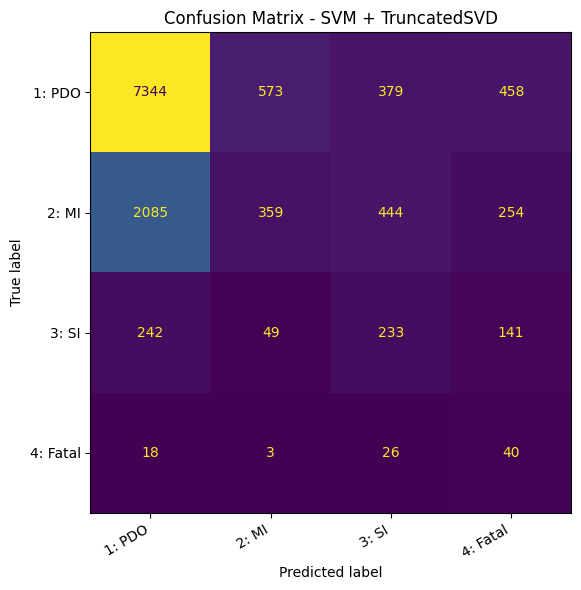

Confusion matrix table saved for SVM + TruncatedSVD:
/content/road_crash_outputs/model_results/confusion_matrix_svm_truncatedsvd.csv
Confusion matrix figure saved for SVM + TruncatedSVD:
/content/road_crash_outputs/model_results/confusion_matrix_svm_truncatedsvd.png

Completed model: SVM + TruncatedSVD


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance
0,SVM + TruncatedSVD,0.6306,0.4408,0.3457,0.4408,0.3297,0.609,NaN,22.64,TruncatedSVD,50,0.9151



PCA/TruncatedSVD test performance saved to:
/content/road_crash_outputs/pca_analysis/pca_truncatedsvd_test_performance.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance
0,SVM + TruncatedSVD,0.6306,0.4408,0.3457,0.4408,0.3297,0.6090,NaN,22.64,TruncatedSVD,50,0.9151
1,Logistic Regression + TruncatedSVD,0.4941,0.4598,0.3281,0.4598,0.3178,0.5491,0.6677,17.46,TruncatedSVD,50,0.9151



PCA/TruncatedSVD cross-validation performance saved to:
/content/road_crash_outputs/pca_analysis/pca_truncatedsvd_cross_validation_performance.csv


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,SVM + TruncatedSVD,0.6351,0.0016,0.4489,0.0113,0.3518,0.0035,0.4489,0.0113,0.333,0.0013,0.6140,0.0019
1,Logistic Regression + TruncatedSVD,0.4991,0.0017,0.4872,0.0121,0.3334,0.0016,0.4872,0.0121,0.325,0.0021,0.5535,0.0015



PCA/SVD vs non-PCA model comparison saved to:
/content/road_crash_outputs/pca_analysis/pca_vs_non_pca_model_comparison.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance
0,Support Vector Machine,0.6453,0.4484,0.3597,0.4484,0.3494,0.6286,NaN,62.34,NaN,NaN,NaN
1,Logistic Regression,0.5335,0.4872,0.3445,0.4872,0.3443,0.5811,0.6938,41.63,NaN,NaN,NaN
2,SVM + TruncatedSVD,0.6306,0.4408,0.3457,0.4408,0.3297,0.6090,NaN,22.64,TruncatedSVD,50.0,0.9151
3,Logistic Regression + TruncatedSVD,0.4941,0.4598,0.3281,0.4598,0.3178,0.5491,0.6677,17.46,TruncatedSVD,50.0,0.9151


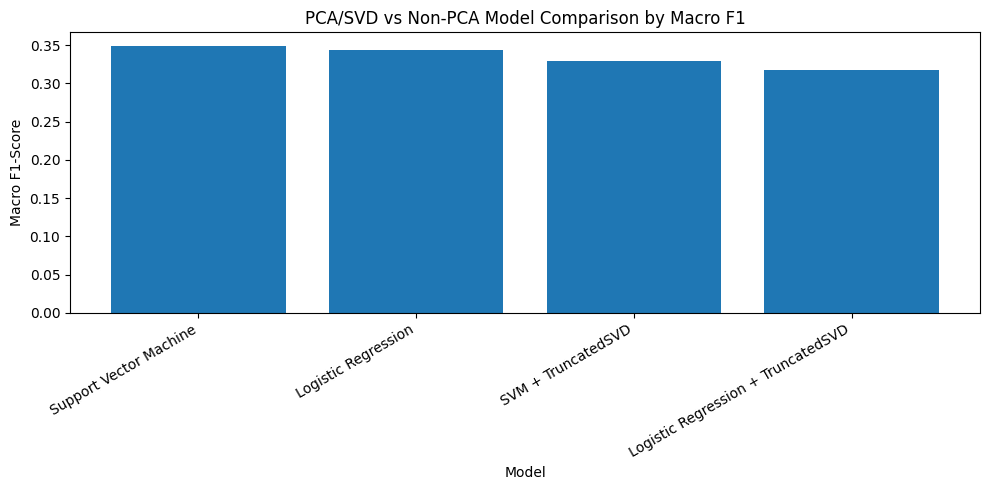


PCA/SVD comparison figure saved to:
/content/road_crash_outputs/pca_analysis/fig_pca_svd_comparison_macro_f1.png


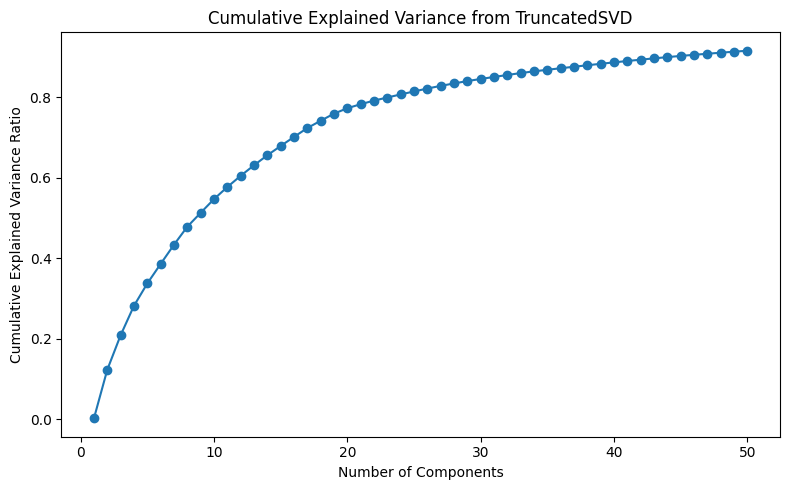


Cumulative explained variance figure saved to:
/content/road_crash_outputs/pca_analysis/fig_truncatedsvd_cumulative_explained_variance.png

Updated model test comparison saved to:
/content/road_crash_outputs/model_results/model_test_performance_comparison_updated_with_pca_svd.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance
0,Support Vector Machine,0.6453,0.4484,0.3597,0.4484,0.3494,0.6286,NaN,62.34,NaN,NaN,NaN
1,Logistic Regression,0.5335,0.4872,0.3445,0.4872,0.3443,0.5811,0.6938,41.63,NaN,NaN,NaN
2,SVM + TruncatedSVD,0.6306,0.4408,0.3457,0.4408,0.3297,0.6090,NaN,22.64,TruncatedSVD,50.0,0.9151
3,Decision Tree,0.5922,0.3222,0.3170,0.3222,0.3192,0.5951,0.5682,12.46,NaN,NaN,NaN
4,Logistic Regression + TruncatedSVD,0.4941,0.4598,0.3281,0.4598,0.3178,0.5491,0.6677,17.46,TruncatedSVD,50.0,0.9151
5,Naive Bayes,0.4972,0.4237,0.3169,0.4237,0.2868,0.5558,0.6573,6.09,NaN,NaN,NaN
6,Random Forest,0.7071,0.2863,0.3982,0.2863,0.2782,0.6280,0.7230,46.21,NaN,NaN,NaN
7,Dummy Baseline,0.6921,0.2500,0.1730,0.2500,0.2045,0.5662,0.5000,8.97,NaN,NaN,NaN



Updated cross-validation comparison saved to:
/content/road_crash_outputs/model_results/model_cross_validation_comparison_updated_with_pca_svd.csv


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Support Vector Machine,0.6513,0.0033,0.4574,0.0122,0.3693,0.0042,0.4574,0.0122,0.3572,0.0032,0.6357,0.0030
1,Logistic Regression,0.5354,0.0031,0.4893,0.0194,0.3450,0.0017,0.4893,0.0194,0.3447,0.0023,0.5833,0.0027
2,SVM + TruncatedSVD,0.6351,0.0016,0.4489,0.0113,0.3518,0.0035,0.4489,0.0113,0.3330,0.0013,0.6140,0.0019
3,Logistic Regression + TruncatedSVD,0.4991,0.0017,0.4872,0.0121,0.3334,0.0016,0.4872,0.0121,0.3250,0.0021,0.5535,0.0015
4,Decision Tree,0.5954,0.0019,0.3188,0.0032,0.3138,0.0025,0.3188,0.0032,0.3160,0.0028,0.5993,0.0025
5,Random Forest,0.7072,0.0006,0.2864,0.0011,0.4252,0.0119,0.2864,0.0011,0.2786,0.0018,0.6274,0.0007
6,Naive Bayes,0.4587,0.0108,0.4300,0.0076,0.3222,0.0034,0.4300,0.0076,0.2743,0.0104,0.5295,0.0078
7,Dummy Baseline,0.6921,0.0000,0.2500,0.0000,0.1730,0.0000,0.2500,0.0000,0.2045,0.0000,0.5662,0.0000



Report-ready PCA/SVD interpretation saved to:
/content/road_crash_outputs/report_materials/pca_truncatedsvd_interpretation.csv


,section,report_ready_interpretation
0,PCA / TruncatedSVD dimensionality reduction ex...,A PCA-style dimensionality reduction experimen...



Report note:
In the report, explain that TruncatedSVD was used as a PCA-style method because one-hot encoding created sparse features.
Compare SVM/Logistic Regression with and without TruncatedSVD.
Do not claim PCA improved the model unless the table shows improvement.

Cell 21 completed successfully.
Next: Run Cell 22 for hyperparameter optimisation and best parameter reporting.


In [27]:
# ============================================================
# Cell 21: PCA / TruncatedSVD dimensionality reduction experiment
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 21: PCA / TruncatedSVD dimensionality reduction experiment")
print("=" * 70)

# ------------------------------------------------------------
# Supervisor requirement:
# Include PCA and standardisation.
#
# Important practical note:
# After OneHotEncoder, the processed feature matrix is usually sparse.
# Standard PCA does not work efficiently with sparse matrices.
# Therefore, TruncatedSVD is used here as the PCA-style dimensionality
# reduction method for sparse one-hot encoded data.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Check processed feature dimension
# ------------------------------------------------------------
print("Checking transformed feature dimension...")

X_train_processed_check = preprocessor.fit_transform(X_train)

processed_feature_count = X_train_processed_check.shape[1]

print("Original feature count before preprocessing:", X_train.shape[1])
print("Processed feature count after encoding:", processed_feature_count)

# Choose safe number of components
svd_components = min(50, processed_feature_count - 1)

if svd_components < 2:
    raise ValueError("Not enough processed features for TruncatedSVD/PCA experiment.")

print("Number of TruncatedSVD components used:", svd_components)


# ------------------------------------------------------------
# 2. Define PCA-style dimensionality reduction pipelines
# ------------------------------------------------------------
pca_experiment_pipelines = {
    "Logistic Regression + TruncatedSVD": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("svd", TruncatedSVD(
                n_components=svd_components,
                random_state=RANDOM_STATE
            )),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),

    "SVM + TruncatedSVD": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("svd", TruncatedSVD(
                n_components=svd_components,
                random_state=RANDOM_STATE
            )),
            ("classifier", LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=5000
            ))
        ]
    )
}


# ------------------------------------------------------------
# 3. Save PCA/SVD method explanation for report
# ------------------------------------------------------------
pca_method_explanation = pd.DataFrame({
    "item": [
        "Why dimensionality reduction was needed",
        "Why TruncatedSVD was used instead of standard PCA",
        "Number of components",
        "Models tested with dimensionality reduction",
        "How this addresses supervisor feedback"
    ],
    "explanation": [
        "One-hot encoding can create a high-dimensional feature matrix, especially when categorical variables have many levels.",
        "Standard PCA is designed mainly for dense matrices. TruncatedSVD can be applied directly to sparse one-hot encoded matrices and is commonly used as a PCA-style alternative.",
        f"{svd_components} components were used to reduce the processed feature space.",
        "Logistic Regression + TruncatedSVD and SVM + TruncatedSVD were evaluated.",
        "The experiment explicitly tests dimensionality reduction together with standardised preprocessing."
    ]
})

pca_method_explanation_path = f"{PCA_DIR}/pca_truncatedsvd_method_explanation.csv"
pca_method_explanation.to_csv(pca_method_explanation_path, index=False)

print("\nPCA/TruncatedSVD method explanation saved to:")
print(pca_method_explanation_path)

display(pca_method_explanation)


# ------------------------------------------------------------
# 4. Train, cross-validate, and test PCA/SVD models
# ------------------------------------------------------------
pca_test_results = []
pca_cv_results = []
pca_classification_reports = []

for model_name, pipeline in pca_experiment_pipelines.items():
    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    start_time = time.time()

    # Cross-validation
    print(f"Running cross-validation for {model_name}...")
    cv_summary = run_cross_validation(
        model_name,
        pipeline,
        X_train,
        y_train
    )

    pca_cv_results.append(cv_summary)
    cross_validation_tables.append(cv_summary)

    # Fit model
    print(f"Fitting {model_name} on full training set...")
    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

    # Explained variance
    explained_variance_ratio = pipeline.named_steps["svd"].explained_variance_ratio_
    cumulative_explained_variance = explained_variance_ratio.cumsum()

    variance_table = pd.DataFrame({
        "component": range(1, len(explained_variance_ratio) + 1),
        "explained_variance_ratio": explained_variance_ratio,
        "cumulative_explained_variance": cumulative_explained_variance
    })

    safe_model_name = clean_column_name(model_name)
    variance_table_path = f"{PCA_DIR}/svd_explained_variance_{safe_model_name}.csv"
    variance_table.to_csv(variance_table_path, index=False)

    print("Explained variance table saved to:")
    print(variance_table_path)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability if available
    y_proba = None
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        try:
            y_proba = pipeline.predict_proba(X_test)
        except Exception:
            y_proba = None

    # Test evaluation
    test_result = evaluate_predictions(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        y_true_encoded=y_test_encoded,
        y_proba=y_proba
    )

    end_time = time.time()
    test_result["training_and_testing_time_seconds"] = round(end_time - start_time, 2)
    test_result["dimensionality_reduction"] = "TruncatedSVD"
    test_result["n_components"] = svd_components
    test_result["cumulative_explained_variance"] = round(
        cumulative_explained_variance[-1],
        4
    )

    pca_test_results.append(test_result)
    model_test_results.append(test_result)

    # Classification report
    report_df = save_classification_report_table(
        model_name,
        y_test,
        y_pred
    )

    pca_classification_reports.append(report_df)
    classification_report_tables.append(report_df)

    # Confusion matrix
    save_confusion_matrix_plot(
        model_name,
        y_test,
        y_pred
    )

    print(f"\nCompleted model: {model_name}")
    display(pd.DataFrame([test_result]))


# ------------------------------------------------------------
# 5. Save PCA/SVD experiment result table
# ------------------------------------------------------------
pca_test_results_df = pd.DataFrame(pca_test_results)

pca_test_results_df = pca_test_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

pca_test_results_path = f"{PCA_DIR}/pca_truncatedsvd_test_performance.csv"
pca_test_results_df.to_csv(pca_test_results_path, index=False)

print("\nPCA/TruncatedSVD test performance saved to:")
print(pca_test_results_path)

display(pca_test_results_df)


# ------------------------------------------------------------
# 6. Save PCA/SVD cross-validation result table
# ------------------------------------------------------------
pca_cv_results_df = pd.concat(
    pca_cv_results,
    ignore_index=True
)

pca_cv_results_df = pca_cv_results_df.sort_values(
    "f1_macro_mean",
    ascending=False
).reset_index(drop=True)

pca_cv_results_path = f"{PCA_DIR}/pca_truncatedsvd_cross_validation_performance.csv"
pca_cv_results_df.to_csv(pca_cv_results_path, index=False)

print("\nPCA/TruncatedSVD cross-validation performance saved to:")
print(pca_cv_results_path)

display(pca_cv_results_df)


# ------------------------------------------------------------
# 7. Compare non-PCA and PCA/SVD versions
# ------------------------------------------------------------
all_results_for_pca_compare = pd.DataFrame(model_test_results)

compare_model_names = [
    "Logistic Regression",
    "Support Vector Machine",
    "Logistic Regression + TruncatedSVD",
    "SVM + TruncatedSVD"
]

pca_comparison_table = all_results_for_pca_compare[
    all_results_for_pca_compare["model"].isin(compare_model_names)
].copy()

pca_comparison_table = pca_comparison_table.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

pca_comparison_path = f"{PCA_DIR}/pca_vs_non_pca_model_comparison.csv"
pca_comparison_table.to_csv(pca_comparison_path, index=False)

print("\nPCA/SVD vs non-PCA model comparison saved to:")
print(pca_comparison_path)

display(pca_comparison_table)


# ------------------------------------------------------------
# 8. Plot PCA/SVD comparison by macro F1
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    pca_comparison_table["model"],
    pca_comparison_table["macro_f1"]
)
plt.title("PCA/SVD vs Non-PCA Model Comparison by Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

pca_macro_f1_fig_path = f"{PCA_DIR}/fig_pca_svd_comparison_macro_f1.png"
plt.savefig(pca_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nPCA/SVD comparison figure saved to:")
print(pca_macro_f1_fig_path)


# ------------------------------------------------------------
# 9. Plot cumulative explained variance
# ------------------------------------------------------------
best_pca_model_name = pca_test_results_df.iloc[0]["model"]
best_pca_safe_name = clean_column_name(best_pca_model_name)

best_pca_pipeline = trained_models[best_pca_model_name]
best_variance_ratio = best_pca_pipeline.named_steps["svd"].explained_variance_ratio_
best_cumulative_variance = best_variance_ratio.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(best_cumulative_variance) + 1),
    best_cumulative_variance,
    marker="o"
)
plt.title("Cumulative Explained Variance from TruncatedSVD")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.tight_layout()

svd_variance_fig_path = f"{PCA_DIR}/fig_truncatedsvd_cumulative_explained_variance.png"
plt.savefig(svd_variance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nCumulative explained variance figure saved to:")
print(svd_variance_fig_path)


# ------------------------------------------------------------
# 10. Update full model result tables after PCA/SVD experiment
# ------------------------------------------------------------
model_test_results_df = pd.DataFrame(model_test_results)

model_test_results_df = model_test_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

model_test_results_path = f"{MODEL_DIR}/model_test_performance_comparison_updated_with_pca_svd.csv"
model_test_results_df.to_csv(model_test_results_path, index=False)

print("\nUpdated model test comparison saved to:")
print(model_test_results_path)

display(model_test_results_df)

cross_validation_results_df = pd.concat(
    cross_validation_tables,
    ignore_index=True
)

cross_validation_results_df = cross_validation_results_df.sort_values(
    "f1_macro_mean",
    ascending=False
).reset_index(drop=True)

cross_validation_results_path = f"{MODEL_DIR}/model_cross_validation_comparison_updated_with_pca_svd.csv"
cross_validation_results_df.to_csv(cross_validation_results_path, index=False)

print("\nUpdated cross-validation comparison saved to:")
print(cross_validation_results_path)

display(cross_validation_results_df)


# ------------------------------------------------------------
# 11. Report-ready interpretation
# ------------------------------------------------------------
best_pca_macro_f1 = pca_test_results_df.iloc[0]["macro_f1"]
best_pca_balanced_acc = pca_test_results_df.iloc[0]["balanced_accuracy"]
best_pca_explained_variance = pca_test_results_df.iloc[0]["cumulative_explained_variance"]

best_overall_after_pca = model_test_results_df.iloc[0]["model"]
best_overall_macro_f1_after_pca = model_test_results_df.iloc[0]["macro_f1"]

pca_interpretation_text = (
    f"A PCA-style dimensionality reduction experiment was conducted using TruncatedSVD because the preprocessing pipeline "
    f"produced a sparse one-hot encoded matrix. TruncatedSVD reduced the encoded feature space to {svd_components} components. "
    f"The best dimensionality-reduced model was {best_pca_model_name}, with a test macro F1-score of {best_pca_macro_f1} "
    f"and balanced accuracy of {best_pca_balanced_acc}. The selected SVD components captured a cumulative explained variance "
    f"of {best_pca_explained_variance}. After including the dimensionality reduction experiment, the best overall model was "
    f"{best_overall_after_pca} with a macro F1-score of {best_overall_macro_f1_after_pca}."
)

pca_interpretation = pd.DataFrame({
    "section": ["PCA / TruncatedSVD dimensionality reduction experiment"],
    "report_ready_interpretation": [pca_interpretation_text]
})

pca_interpretation_path = f"{REPORT_DIR}/pca_truncatedsvd_interpretation.csv"
pca_interpretation.to_csv(pca_interpretation_path, index=False)

print("\nReport-ready PCA/SVD interpretation saved to:")
print(pca_interpretation_path)

display(pca_interpretation)


# ------------------------------------------------------------
# 12. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("In the report, explain that TruncatedSVD was used as a PCA-style method because one-hot encoding created sparse features.")
print("Compare SVM/Logistic Regression with and without TruncatedSVD.")
print("Do not claim PCA improved the model unless the table shows improvement.")

print("\nCell 21 completed successfully.")
print("Next: Run Cell 22 for hyperparameter optimisation and best parameter reporting.")

Cell 22: Hyperparameter optimisation and best-parameter reporting

Hyperparameter tuning: Tuned Naive Bayes
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Classification report saved for Tuned Naive Bayes:
/content/road_crash_outputs/model_results/classification_report_tuned_naive_bayes.csv


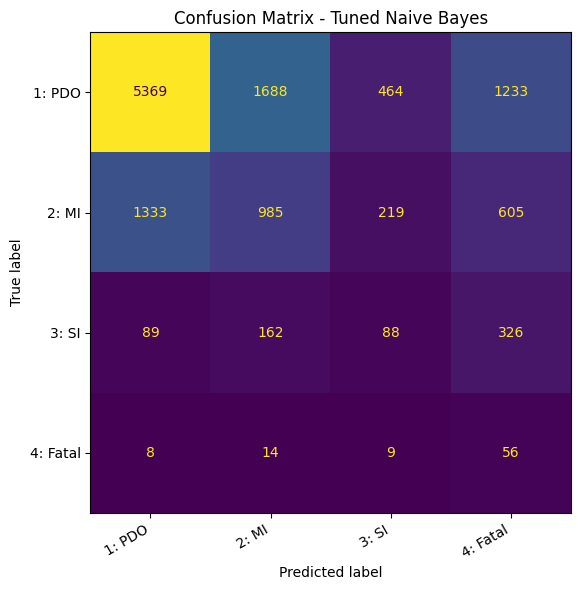

Confusion matrix table saved for Tuned Naive Bayes:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_naive_bayes.csv
Confusion matrix figure saved for Tuned Naive Bayes:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_naive_bayes.png

Full hyperparameter search results saved to:
/content/road_crash_outputs/model_results/hyperparameter_search_results_tuned_naive_bayes.csv

Best CV macro F1: 0.2942
Best parameters:
{'classifier__var_smoothing': 1e-06}

Test result:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Naive Bayes,0.5138,0.4257,0.3184,0.4257,0.2974,0.5663,0.663,27.61,grid,0.2942,"{""classifier__var_smoothing"": 1e-06}"



Hyperparameter tuning: Tuned Logistic Regression
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Classification report saved for Tuned Logistic Regression:
/content/road_crash_outputs/model_results/classification_report_tuned_logistic_regression.csv


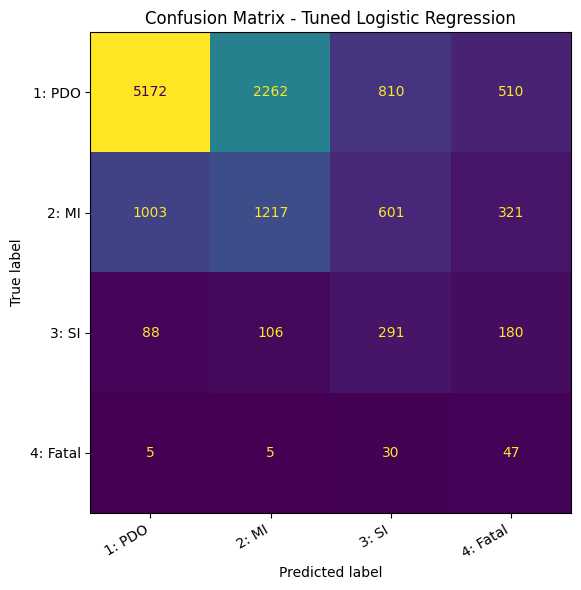

Confusion matrix table saved for Tuned Logistic Regression:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_logistic_regression.csv
Confusion matrix figure saved for Tuned Logistic Regression:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_logistic_regression.png

Full hyperparameter search results saved to:
/content/road_crash_outputs/model_results/hyperparameter_search_results_tuned_logistic_regression.csv

Best CV macro F1: 0.345
Best parameters:
{'classifier__C': 0.1, 'classifier__multi_class': 'auto', 'classifier__solver': 'lbfgs'}

Test result:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Logistic Regression,0.5319,0.489,0.3441,0.489,0.3438,0.5797,0.6938,98.89,grid,0.345,"{""classifier__C"": 0.1, ""classifier__multi_clas..."



Hyperparameter tuning: Tuned Support Vector Machine
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Classification report saved for Tuned Support Vector Machine:
/content/road_crash_outputs/model_results/classification_report_tuned_support_vector_machine.csv


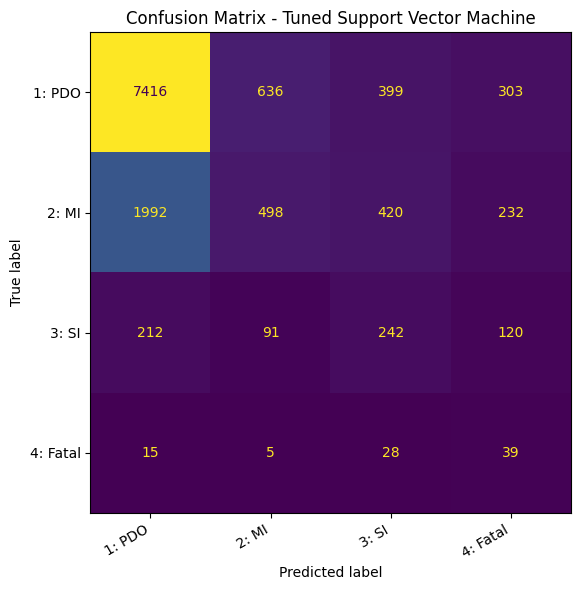

Confusion matrix table saved for Tuned Support Vector Machine:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_support_vector_machine.csv
Confusion matrix figure saved for Tuned Support Vector Machine:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_support_vector_machine.png

Full hyperparameter search results saved to:
/content/road_crash_outputs/model_results/hyperparameter_search_results_tuned_support_vector_machine.csv

Best CV macro F1: 0.3575
Best parameters:
{'classifier__C': 0.01, 'classifier__loss': 'squared_hinge'}

Test result:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Support Vector Machine,0.6479,0.4545,0.3632,0.4545,0.3525,0.63,NaN,195.38,grid,0.3575,"{""classifier__C"": 0.01, ""classifier__loss"": ""s..."



Hyperparameter tuning: Tuned Decision Tree
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Classification report saved for Tuned Decision Tree:
/content/road_crash_outputs/model_results/classification_report_tuned_decision_tree.csv


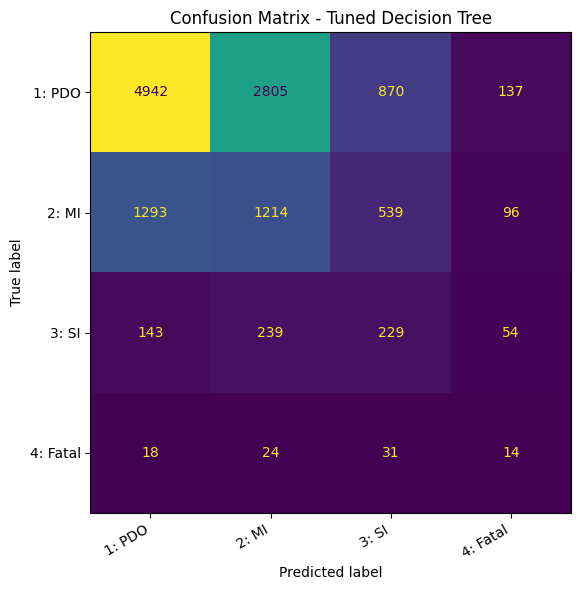

Confusion matrix table saved for Tuned Decision Tree:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_decision_tree.csv
Confusion matrix figure saved for Tuned Decision Tree:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_decision_tree.png

Full hyperparameter search results saved to:
/content/road_crash_outputs/model_results/hyperparameter_search_results_tuned_decision_tree.csv

Best CV macro F1: 0.3221
Best parameters:
{'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}

Test result:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Decision Tree,0.5059,0.3641,0.31,0.3641,0.312,0.5436,0.6115,114.28,random,0.3221,"{""classifier__min_samples_split"": 20, ""classif..."



Hyperparameter tuning: Tuned Random Forest
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Classification report saved for Tuned Random Forest:
/content/road_crash_outputs/model_results/classification_report_tuned_random_forest.csv


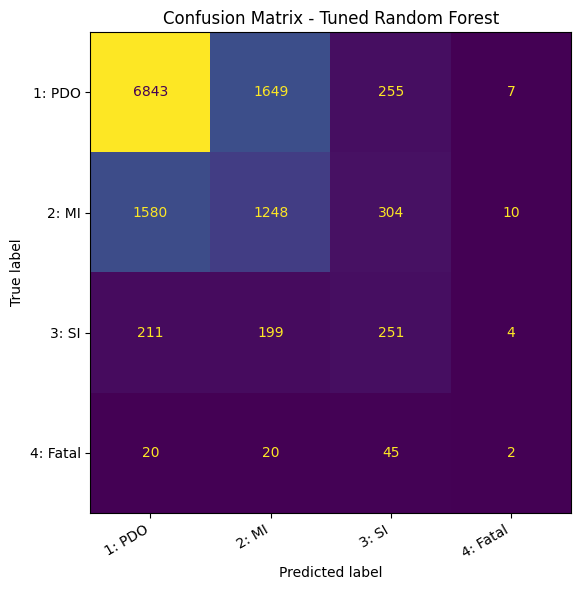

Confusion matrix table saved for Tuned Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_random_forest.csv
Confusion matrix figure saved for Tuned Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_tuned_random_forest.png

Full hyperparameter search results saved to:
/content/road_crash_outputs/model_results/hyperparameter_search_results_tuned_random_forest.csv

Best CV macro F1: 0.3889
Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}

Test result:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Random Forest,0.6597,0.3948,0.3929,0.3948,0.3879,0.6608,0.7236,437.72,random,0.3889,"{""classifier__n_estimators"": 200, ""classifier_..."



Best hyperparameter summary saved to:
/content/road_crash_outputs/model_results/best_hyperparameter_summary.csv


,model,search_type,scoring,cv_folds,best_cv_macro_f1,best_params,tuning_time_seconds,cv_results_file
0,Tuned Random Forest,random,f1_macro,3,0.3889,"{""classifier__n_estimators"": 200, ""classifier_...",437.72,/content/road_crash_outputs/model_results/hype...
1,Tuned Support Vector Machine,grid,f1_macro,3,0.3575,"{""classifier__C"": 0.01, ""classifier__loss"": ""s...",195.38,/content/road_crash_outputs/model_results/hype...
2,Tuned Logistic Regression,grid,f1_macro,3,0.3450,"{""classifier__C"": 0.1, ""classifier__multi_clas...",98.89,/content/road_crash_outputs/model_results/hype...
3,Tuned Decision Tree,random,f1_macro,3,0.3221,"{""classifier__min_samples_split"": 20, ""classif...",114.28,/content/road_crash_outputs/model_results/hype...
4,Tuned Naive Bayes,grid,f1_macro,3,0.2942,"{""classifier__var_smoothing"": 1e-06}",27.61,/content/road_crash_outputs/model_results/hype...



Tuned model test performance saved to:
/content/road_crash_outputs/model_results/tuned_model_test_performance.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,search_type,best_cv_macro_f1,best_params
0,Tuned Random Forest,0.6597,0.3948,0.3929,0.3948,0.3879,0.6608,0.7236,437.72,random,0.3889,"{""classifier__n_estimators"": 200, ""classifier_..."
1,Tuned Support Vector Machine,0.6479,0.4545,0.3632,0.4545,0.3525,0.6300,NaN,195.38,grid,0.3575,"{""classifier__C"": 0.01, ""classifier__loss"": ""s..."
2,Tuned Logistic Regression,0.5319,0.4890,0.3441,0.4890,0.3438,0.5797,0.6938,98.89,grid,0.3450,"{""classifier__C"": 0.1, ""classifier__multi_clas..."
3,Tuned Decision Tree,0.5059,0.3641,0.3100,0.3641,0.3120,0.5436,0.6115,114.28,random,0.3221,"{""classifier__min_samples_split"": 20, ""classif..."
4,Tuned Naive Bayes,0.5138,0.4257,0.3184,0.4257,0.2974,0.5663,0.6630,27.61,grid,0.2942,"{""classifier__var_smoothing"": 1e-06}"



Final full model comparison with tuned models saved to:
/content/road_crash_outputs/model_results/final_model_test_performance_comparison_with_tuned_models.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted,training_and_testing_time_seconds,dimensionality_reduction,n_components,cumulative_explained_variance,search_type,best_cv_macro_f1,best_params
0,Tuned Random Forest,0.6597,0.3948,0.3929,0.3948,0.3879,0.6608,0.7236,437.72,NaN,NaN,NaN,random,0.3889,"{""classifier__n_estimators"": 200, ""classifier_..."
1,Tuned Support Vector Machine,0.6479,0.4545,0.3632,0.4545,0.3525,0.6300,NaN,195.38,NaN,NaN,NaN,grid,0.3575,"{""classifier__C"": 0.01, ""classifier__loss"": ""s..."
2,Support Vector Machine,0.6453,0.4484,0.3597,0.4484,0.3494,0.6286,NaN,62.34,NaN,NaN,NaN,NaN,NaN,NaN
3,Logistic Regression,0.5335,0.4872,0.3445,0.4872,0.3443,0.5811,0.6938,41.63,NaN,NaN,NaN,NaN,NaN,NaN
4,Tuned Logistic Regression,0.5319,0.4890,0.3441,0.4890,0.3438,0.5797,0.6938,98.89,NaN,NaN,NaN,grid,0.3450,"{""classifier__C"": 0.1, ""classifier__multi_clas..."
5,SVM + TruncatedSVD,0.6306,0.4408,0.3457,0.4408,0.3297,0.6090,NaN,22.64,TruncatedSVD,50.0,0.9151,NaN,NaN,NaN
6,Decision Tree,0.5922,0.3222,0.3170,0.3222,0.3192,0.5951,0.5682,12.46,NaN,NaN,NaN,NaN,NaN,NaN
7,Logistic Regression + TruncatedSVD,0.4941,0.4598,0.3281,0.4598,0.3178,0.5491,0.6677,17.46,TruncatedSVD,50.0,0.9151,NaN,NaN,NaN
8,Tuned Decision Tree,0.5059,0.3641,0.3100,0.3641,0.3120,0.5436,0.6115,114.28,NaN,NaN,NaN,random,0.3221,"{""classifier__min_samples_split"": 20, ""classif..."
9,Tuned Naive Bayes,0.5138,0.4257,0.3184,0.4257,0.2974,0.5663,0.6630,27.61,NaN,NaN,NaN,grid,0.2942,"{""classifier__var_smoothing"": 1e-06}"



Tuned model classification reports saved to:
/content/road_crash_outputs/model_results/tuned_model_classification_reports.csv


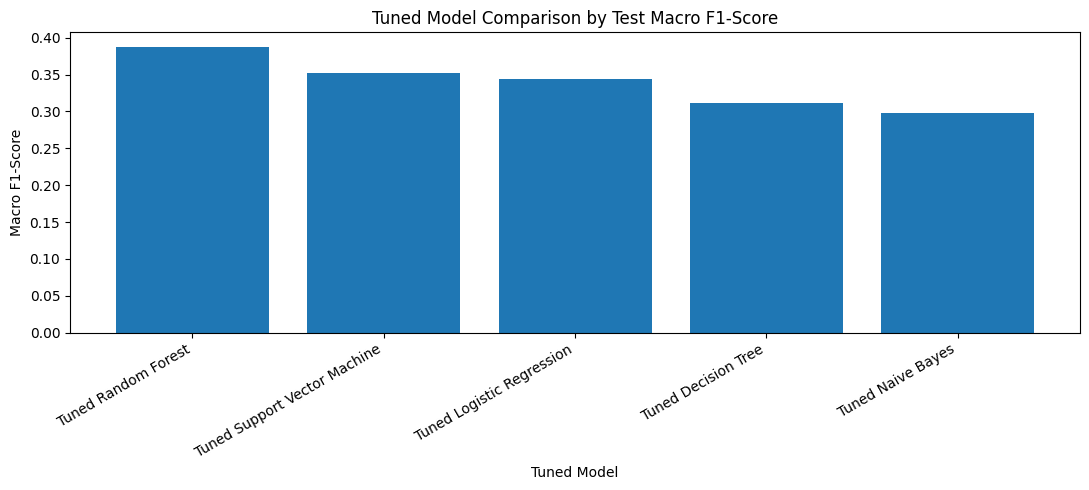


Tuned model macro F1 figure saved to:
/content/road_crash_outputs/model_results/fig_tuned_model_comparison_macro_f1.png


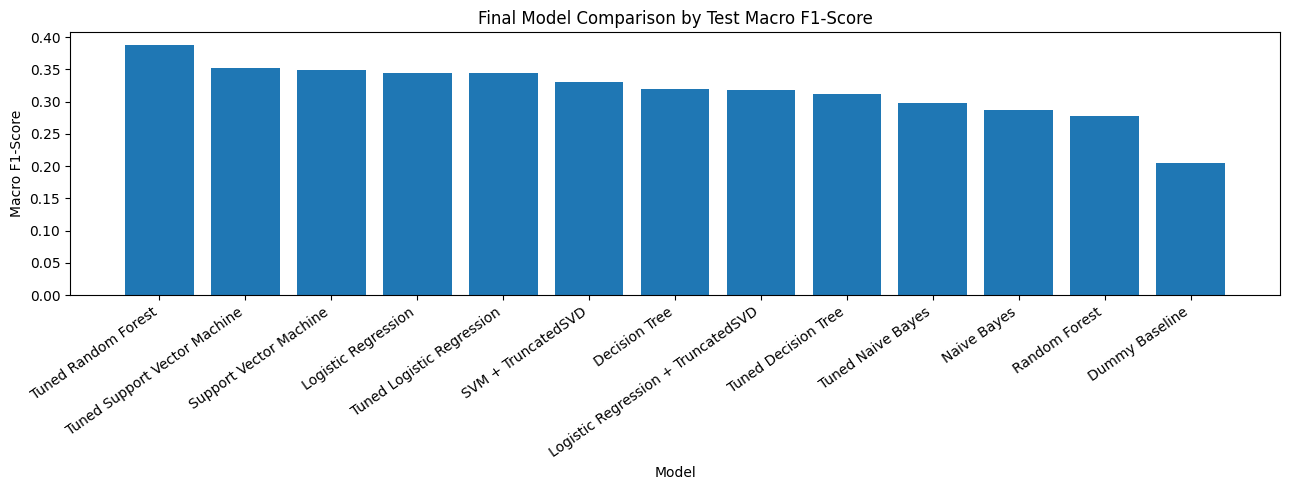


Final all-model macro F1 figure saved to:
/content/road_crash_outputs/model_results/fig_final_all_model_comparison_macro_f1.png

Final best model summary saved to:
/content/road_crash_outputs/model_results/final_best_model_summary.csv


,item,value
0,Final best model,Tuned Random Forest
1,Selection metric,Macro F1-score
2,Test macro F1,0.3879
3,Test balanced accuracy,0.3948
4,Test weighted F1,0.6608



Report-ready hyperparameter interpretation saved to:
/content/road_crash_outputs/report_materials/hyperparameter_optimisation_interpretation.csv


,section,report_ready_interpretation
0,Hyperparameter optimisation,Hyperparameter optimisation was performed usin...



Report note:
Use 'best_hyperparameter_summary.csv' in the report.
This directly answers the supervisor comment asking for exact best hyperparameter values.
Use macro F1-score as the main model selection metric.
Do not select the final model using accuracy only.

Cell 22 completed successfully.
Next: Run Cell 23 for final model interpretation and feature importance.


In [28]:
# ============================================================
# Cell 22: Hyperparameter optimisation and best-parameter reporting
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 22: Hyperparameter optimisation and best-parameter reporting")
print("=" * 70)

# ------------------------------------------------------------
# Supervisor requirement:
# Report exact best hyperparameter values.
#
# This cell tunes:
# 1. Naive Bayes
# 2. Logistic Regression
# 3. Support Vector Machine
# 4. Decision Tree
# 5. Random Forest
#
# Main scoring metric:
# Macro F1-score, because the target classes are imbalanced.
# ------------------------------------------------------------

tuned_models = {}
tuning_results = []
tuned_test_results = []
tuned_classification_reports = []

# ------------------------------------------------------------
# Helper function: run hyperparameter tuning
# ------------------------------------------------------------
def run_hyperparameter_tuning(
    model_name,
    pipeline,
    param_grid,
    search_type="grid",
    n_iter=10
):
    print("\n" + "=" * 70)
    print(f"Hyperparameter tuning: {model_name}")
    print("=" * 70)

    start_time = time.time()

    if search_type == "random":
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="f1_macro",
            cv=cv_strategy,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )
    else:
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="f1_macro",
            cv=cv_strategy,
            n_jobs=-1,
            verbose=1
        )

    search.fit(X_train, y_train)

    end_time = time.time()

    best_model = search.best_estimator_
    tuned_models[model_name] = best_model
    trained_models[model_name] = best_model

    # Predict on test set
    y_pred = best_model.predict(X_test)

    # Probability if available
    y_proba = None
    if hasattr(best_model.named_steps["classifier"], "predict_proba"):
        try:
            y_proba = best_model.predict_proba(X_test)
        except Exception:
            y_proba = None

    # Evaluate test performance
    test_result = evaluate_predictions(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        y_true_encoded=y_test_encoded,
        y_proba=y_proba
    )

    test_result["training_and_testing_time_seconds"] = round(end_time - start_time, 2)
    test_result["search_type"] = search_type
    test_result["best_cv_macro_f1"] = round(search.best_score_, 4)
    test_result["best_params"] = json.dumps(search.best_params_)

    tuned_test_results.append(test_result)
    model_test_results.append(test_result)

    # Save classification report
    report_df = save_classification_report_table(
        model_name,
        y_test,
        y_pred
    )

    tuned_classification_reports.append(report_df)
    classification_report_tables.append(report_df)

    # Save confusion matrix
    save_confusion_matrix_plot(
        model_name,
        y_test,
        y_pred
    )

    # Save full CV search results
    safe_model_name = clean_column_name(model_name)

    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_path = f"{MODEL_DIR}/hyperparameter_search_results_{safe_model_name}.csv"
    cv_results_df.to_csv(cv_results_path, index=False)

    print("\nFull hyperparameter search results saved to:")
    print(cv_results_path)

    # Save best parameter summary
    tuning_result = {
        "model": model_name,
        "search_type": search_type,
        "scoring": "f1_macro",
        "cv_folds": cv_strategy.get_n_splits(),
        "best_cv_macro_f1": round(search.best_score_, 4),
        "best_params": json.dumps(search.best_params_),
        "tuning_time_seconds": round(end_time - start_time, 2),
        "cv_results_file": cv_results_path
    }

    tuning_results.append(tuning_result)

    print("\nBest CV macro F1:", round(search.best_score_, 4))
    print("Best parameters:")
    print(search.best_params_)

    print("\nTest result:")
    display(pd.DataFrame([test_result]))

    return best_model, search


# ------------------------------------------------------------
# 1. Tuned Naive Bayes
# ------------------------------------------------------------
nb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("to_dense", dense_transformer),
        ("classifier", GaussianNB())
    ]
)

nb_param_grid = {
    "classifier__var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}

best_nb_model, nb_search = run_hyperparameter_tuning(
    model_name="Tuned Naive Bayes",
    pipeline=nb_pipeline,
    param_grid=nb_param_grid,
    search_type="grid"
)


# ------------------------------------------------------------
# 2. Tuned Logistic Regression
# ------------------------------------------------------------
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs"],
    "classifier__multi_class": ["auto"]
}

best_lr_model, lr_search = run_hyperparameter_tuning(
    model_name="Tuned Logistic Regression",
    pipeline=lr_pipeline,
    param_grid=lr_param_grid,
    search_type="grid"
)


# ------------------------------------------------------------
# 3. Tuned Support Vector Machine
# LinearSVC is used to keep runtime manageable in Colab.
# ------------------------------------------------------------
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=7000
        ))
    ]
)

svm_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__loss": ["squared_hinge"]
}

best_svm_model, svm_search = run_hyperparameter_tuning(
    model_name="Tuned Support Vector Machine",
    pipeline=svm_pipeline,
    param_grid=svm_param_grid,
    search_type="grid"
)


# ------------------------------------------------------------
# 4. Tuned Decision Tree
# ------------------------------------------------------------
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]
)

dt_param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8]
}

best_dt_model, dt_search = run_hyperparameter_tuning(
    model_name="Tuned Decision Tree",
    pipeline=dt_pipeline,
    param_grid=dt_param_grid,
    search_type="random",
    n_iter=20
)


# ------------------------------------------------------------
# 5. Tuned Random Forest
# RandomizedSearchCV is used because Random Forest has more combinations.
# ------------------------------------------------------------
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [10, 20, 30, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

best_rf_model, rf_search = run_hyperparameter_tuning(
    model_name="Tuned Random Forest",
    pipeline=rf_pipeline,
    param_grid=rf_param_grid,
    search_type="random",
    n_iter=15
)


# ------------------------------------------------------------
# 6. Save best hyperparameter summary table
# ------------------------------------------------------------
hyperparameter_summary_df = pd.DataFrame(tuning_results)

hyperparameter_summary_df = hyperparameter_summary_df.sort_values(
    "best_cv_macro_f1",
    ascending=False
).reset_index(drop=True)

hyperparameter_summary_path = f"{MODEL_DIR}/best_hyperparameter_summary.csv"
hyperparameter_summary_df.to_csv(hyperparameter_summary_path, index=False)

print("\nBest hyperparameter summary saved to:")
print(hyperparameter_summary_path)

display(hyperparameter_summary_df)


# ------------------------------------------------------------
# 7. Save tuned model test performance table
# ------------------------------------------------------------
tuned_test_results_df = pd.DataFrame(tuned_test_results)

tuned_test_results_df = tuned_test_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

tuned_test_results_path = f"{MODEL_DIR}/tuned_model_test_performance.csv"
tuned_test_results_df.to_csv(tuned_test_results_path, index=False)

print("\nTuned model test performance saved to:")
print(tuned_test_results_path)

display(tuned_test_results_df)


# ------------------------------------------------------------
# 8. Update full model comparison table
# ------------------------------------------------------------
model_test_results_df = pd.DataFrame(model_test_results)

model_test_results_df = model_test_results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

full_model_comparison_path = f"{MODEL_DIR}/final_model_test_performance_comparison_with_tuned_models.csv"
model_test_results_df.to_csv(full_model_comparison_path, index=False)

print("\nFinal full model comparison with tuned models saved to:")
print(full_model_comparison_path)

display(model_test_results_df)


# ------------------------------------------------------------
# 9. Combine tuned classification reports
# ------------------------------------------------------------
tuned_classification_reports_all = pd.concat(
    tuned_classification_reports,
    ignore_index=True
)

tuned_classification_reports_path = f"{MODEL_DIR}/tuned_model_classification_reports.csv"
tuned_classification_reports_all.to_csv(tuned_classification_reports_path, index=False)

print("\nTuned model classification reports saved to:")
print(tuned_classification_reports_path)


# ------------------------------------------------------------
# 10. Plot tuned model comparison by macro F1
# ------------------------------------------------------------
plt.figure(figsize=(11, 5))
plt.bar(
    tuned_test_results_df["model"],
    tuned_test_results_df["macro_f1"]
)
plt.title("Tuned Model Comparison by Test Macro F1-Score")
plt.xlabel("Tuned Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

tuned_macro_f1_fig_path = f"{MODEL_DIR}/fig_tuned_model_comparison_macro_f1.png"
plt.savefig(tuned_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nTuned model macro F1 figure saved to:")
print(tuned_macro_f1_fig_path)


# ------------------------------------------------------------
# 11. Plot all model comparison by macro F1
# ------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.bar(
    model_test_results_df["model"],
    model_test_results_df["macro_f1"]
)
plt.title("Final Model Comparison by Test Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

final_macro_f1_fig_path = f"{MODEL_DIR}/fig_final_all_model_comparison_macro_f1.png"
plt.savefig(final_macro_f1_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nFinal all-model macro F1 figure saved to:")
print(final_macro_f1_fig_path)


# ------------------------------------------------------------
# 12. Select final best model based on macro F1
# ------------------------------------------------------------
final_best_model_name = model_test_results_df.iloc[0]["model"]
final_best_macro_f1 = model_test_results_df.iloc[0]["macro_f1"]
final_best_balanced_accuracy = model_test_results_df.iloc[0]["balanced_accuracy"]
final_best_weighted_f1 = model_test_results_df.iloc[0]["weighted_f1"]

final_best_model_summary = pd.DataFrame({
    "item": [
        "Final best model",
        "Selection metric",
        "Test macro F1",
        "Test balanced accuracy",
        "Test weighted F1"
    ],
    "value": [
        final_best_model_name,
        "Macro F1-score",
        final_best_macro_f1,
        final_best_balanced_accuracy,
        final_best_weighted_f1
    ]
})

final_best_model_summary_path = f"{MODEL_DIR}/final_best_model_summary.csv"
final_best_model_summary.to_csv(final_best_model_summary_path, index=False)

print("\nFinal best model summary saved to:")
print(final_best_model_summary_path)

display(final_best_model_summary)


# ------------------------------------------------------------
# 13. Report-ready hyperparameter interpretation
# ------------------------------------------------------------
best_tuned_row = tuned_test_results_df.iloc[0]

hyperparameter_interpretation_text = (
    f"Hyperparameter optimisation was performed using macro F1-score as the scoring metric because the crash severity classes "
    f"are highly imbalanced. GridSearchCV was used for Naive Bayes, Logistic Regression, and SVM, while RandomizedSearchCV was "
    f"used for Decision Tree and Random Forest to reduce computational cost. The best tuned model on the test set was "
    f"{best_tuned_row['model']} with a macro F1-score of {best_tuned_row['macro_f1']} and balanced accuracy of "
    f"{best_tuned_row['balanced_accuracy']}. The exact best hyperparameter values for all tuned models were saved in the "
    f"best hyperparameter summary table. After comparing tuned and untuned models, the final selected model was "
    f"{final_best_model_name} based on test macro F1-score."
)

hyperparameter_interpretation = pd.DataFrame({
    "section": ["Hyperparameter optimisation"],
    "report_ready_interpretation": [hyperparameter_interpretation_text]
})

hyperparameter_interpretation_path = f"{REPORT_DIR}/hyperparameter_optimisation_interpretation.csv"
hyperparameter_interpretation.to_csv(hyperparameter_interpretation_path, index=False)

print("\nReport-ready hyperparameter interpretation saved to:")
print(hyperparameter_interpretation_path)

display(hyperparameter_interpretation)


# ------------------------------------------------------------
# 14. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Use 'best_hyperparameter_summary.csv' in the report.")
print("This directly answers the supervisor comment asking for exact best hyperparameter values.")
print("Use macro F1-score as the main model selection metric.")
print("Do not select the final model using accuracy only.")

print("\nCell 22 completed successfully.")
print("Next: Run Cell 23 for final model interpretation and feature importance.")

Cell 23: Final model interpretation and feature importance
Final selected model: Tuned Random Forest
Final model pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['postcode', 'total_units',
                                                   'year', 'area_speed',
                                                   'unit_resp', 'crash_hour',
                                                   'month_num', 'is_weekend',
                                                   'is_raining', 'is_wet_road',
                                                   

,step_name,step_object
0,preprocessor,ColumnTransformer
1,classifier,RandomForestClassifier



Final selected model evaluation saved to:
/content/road_crash_outputs/model_results/final_selected_model_evaluation.csv


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_weighted
0,Tuned Random Forest,0.6597,0.3948,0.3929,0.3948,0.3879,0.6608,0.7236


Classification report saved for Final Selected Model - Tuned Random Forest:
/content/road_crash_outputs/model_results/classification_report_final_selected_model_tuned_random_forest.csv


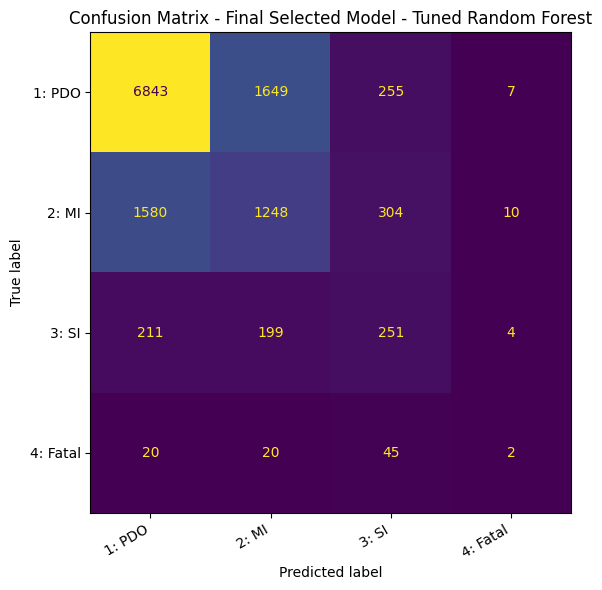

Confusion matrix table saved for Final Selected Model - Tuned Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_final_selected_model_tuned_random_forest.csv
Confusion matrix figure saved for Final Selected Model - Tuned Random Forest:
/content/road_crash_outputs/model_results/confusion_matrix_final_selected_model_tuned_random_forest.png

Final classification report:


,model,class_or_average,precision,recall,f1-score,support
0,Final Selected Model - Tuned Random Forest,1: PDO,0.790733,0.781700,0.786190,8754.000000
1,Final Selected Model - Tuned Random Forest,2: MI,0.400513,0.397199,0.398849,3142.000000
2,Final Selected Model - Tuned Random Forest,3: SI,0.293567,0.377444,0.330263,665.000000
3,Final Selected Model - Tuned Random Forest,4: Fatal,0.086957,0.022989,0.036364,87.000000
4,Final Selected Model - Tuned Random Forest,accuracy,0.659709,0.659709,0.659709,0.659709
5,Final Selected Model - Tuned Random Forest,macro avg,0.392942,0.394833,0.387917,12648.000000
6,Final Selected Model - Tuned Random Forest,weighted avg,0.662814,0.659709,0.660838,12648.000000



Final confusion matrix:


,Predicted 1: PDO,Predicted 2: MI,Predicted 3: SI,Predicted 4: Fatal
Actual 1: PDO,6843,1649,255,7
Actual 2: MI,1580,1248,304,10
Actual 3: SI,211,199,251,4
Actual 4: Fatal,20,20,45,2



Final model minority-class performance saved to:
/content/road_crash_outputs/model_results/final_model_minority_class_performance.csv


,model,class_or_average,precision,recall,f1-score,support
2,Final Selected Model - Tuned Random Forest,3: SI,0.293567,0.377444,0.330263,665.0
3,Final Selected Model - Tuned Random Forest,4: Fatal,0.086957,0.022989,0.036364,87.0



Number of processed feature names: 199

Final model-specific feature importance saved to:
/content/road_crash_outputs/model_results/final_model_specific_feature_importance.csv


,feature,importance,importance_type
0,postcode,0.046345,Tree-based feature importance
1,unit_age_max,0.033700,Tree-based feature importance
2,unit_age_mean,0.033056,Tree-based feature importance
3,unit_age_median,0.031339,Tree-based feature importance
4,unit_age_min,0.030955,Tree-based feature importance
5,area_speed,0.030579,Tree-based feature importance
6,crash_hour,0.027455,Tree-based feature importance
7,unit_vehicle_age_mean,0.024468,Tree-based feature importance
8,unit_veh_year_mean,0.024025,Tree-based feature importance
9,unit_veh_year_max,0.023621,Tree-based feature importance


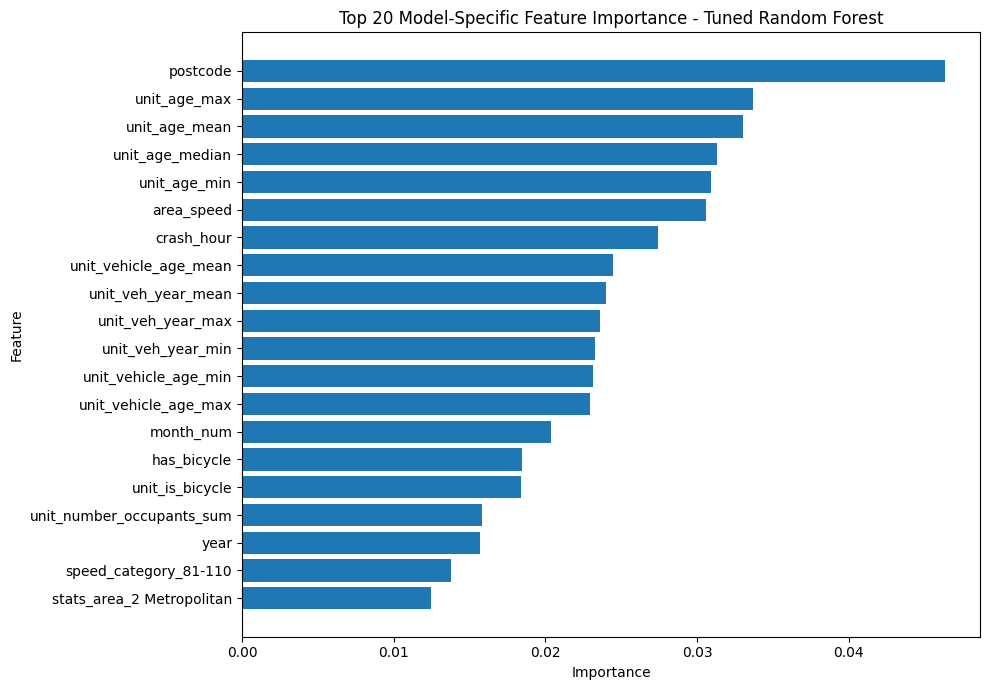


Model-specific feature importance figure saved to:
/content/road_crash_outputs/model_results/fig_final_model_specific_feature_importance.png

Running permutation importance on original input features...
This may take a few minutes in Google Colab.

Final model permutation importance saved to:
/content/road_crash_outputs/model_results/final_model_permutation_importance.csv


,feature,importance_mean,importance_std
0,crash_type,0.022022,0.005632
1,has_bicycle,0.017284,0.002622
2,unit_is_bicycle,0.013818,0.004413
3,unit_number_occupants_sum,0.012305,0.002209
4,unit_resp,0.009621,0.001338
5,speed_category,0.007386,0.003089
6,drugs_involved,0.007301,0.003562
7,postcode,0.006911,0.004863
8,season,0.006814,0.002777
9,unit_main_unit_movement,0.006311,0.005096


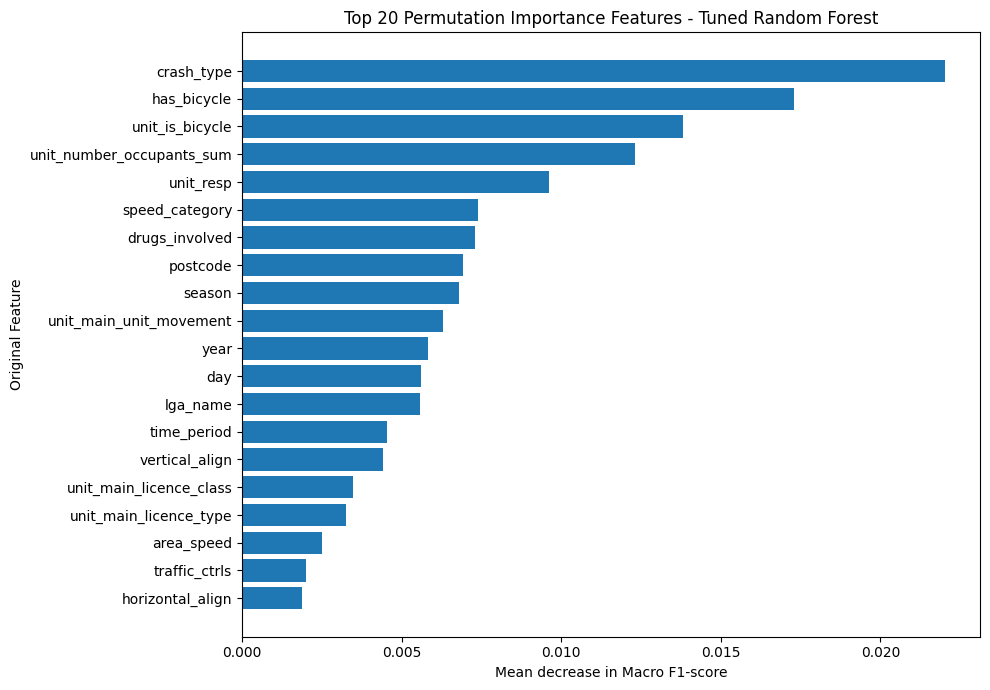


Permutation importance figure saved to:
/content/road_crash_outputs/model_results/fig_final_model_permutation_importance.png

Top 10 final model features for report saved to:
/content/road_crash_outputs/model_results/top_10_final_model_features_for_report.csv


,rank,feature,importance_mean,importance_std
0,1,crash_type,0.022022,0.005632
1,2,has_bicycle,0.017284,0.002622
2,3,unit_is_bicycle,0.013818,0.004413
3,4,unit_number_occupants_sum,0.012305,0.002209
4,5,unit_resp,0.009621,0.001338
5,6,speed_category,0.007386,0.003089
6,7,drugs_involved,0.007301,0.003562
7,8,postcode,0.006911,0.004863
8,9,season,0.006814,0.002777
9,10,unit_main_unit_movement,0.006311,0.005096



Feature importance method explanation saved to:
/content/road_crash_outputs/model_results/feature_importance_method_explanation.csv


,method,what_it_means,why_used,important_note
0,Model-specific feature importance,"Uses the internal fitted model structure, such...",Provides model-based interpretation where the ...,"For one-hot encoded features, importance may r..."
1,Permutation importance,Measures how much macro F1-score decreases whe...,Provides a model-agnostic interpretation that ...,Permutation importance is easier to explain in...



Report-ready final model interpretation saved to:
/content/road_crash_outputs/report_materials/final_model_interpretation_feature_importance.csv


,section,report_ready_interpretation
0,Final model interpretation and feature importance,The final selected model was Tuned Random Fore...



Final model interpretation summary table saved to:
/content/road_crash_outputs/model_results/final_model_interpretation_summary_table.csv


,item,value
0,Final selected model,Tuned Random Forest
1,Main selection metric,Macro F1-score
2,Test macro F1-score,0.3879
3,Test balanced accuracy,0.3948
4,Test weighted F1-score,0.6608
5,Top 5 important original features,"crash_type, has_bicycle, unit_is_bicycle, unit..."
6,Feature importance method recommended for report,Permutation importance



Report note:
Use permutation importance in the main report because it explains original features clearly.
Use model-specific importance as supporting evidence if it is available.
Discuss minority-class recall and F1-score, not only overall accuracy.
Connect the important features back to road safety recommendations.

Cell 23 completed successfully.
Next: Run Cell 24 to create final report-ready tables, figures list, and recommendation outputs.


In [29]:
# ============================================================
# Cell 23: Final model interpretation and feature importance
# Supervisor-aligned version
# ============================================================

print("=" * 70)
print("Cell 23: Final model interpretation and feature importance")
print("=" * 70)

# ------------------------------------------------------------
# Purpose of this cell:
# 1. Re-evaluate the final selected model.
# 2. Save final classification report and confusion matrix.
# 3. Extract model-specific feature importance where possible.
# 4. Run permutation importance on original features.
# 5. Create report-ready interpretation.
# ------------------------------------------------------------

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Select final model
# ------------------------------------------------------------
if "final_best_model_name" not in globals():
    if "model_test_results_df" in globals() and len(model_test_results_df) > 0:
        final_best_model_name = model_test_results_df.sort_values(
            "macro_f1",
            ascending=False
        ).iloc[0]["model"]
    else:
        raise ValueError("Final best model could not be identified. Please run Cell 22 first.")

if final_best_model_name not in trained_models:
    raise KeyError(f"Final model '{final_best_model_name}' not found in trained_models.")

final_model = trained_models[final_best_model_name]

print("Final selected model:", final_best_model_name)
print("Final model pipeline:")
print(final_model)


# ------------------------------------------------------------
# 2. Save final model pipeline steps
# ------------------------------------------------------------
final_model_steps = []

for step_name, step_object in final_model.steps:
    final_model_steps.append({
        "step_name": step_name,
        "step_object": step_object.__class__.__name__
    })

final_model_steps_df = pd.DataFrame(final_model_steps)

final_model_steps_path = f"{MODEL_DIR}/final_model_pipeline_steps.csv"
final_model_steps_df.to_csv(final_model_steps_path, index=False)

print("\nFinal model pipeline steps saved to:")
print(final_model_steps_path)

display(final_model_steps_df)


# ------------------------------------------------------------
# 3. Final model prediction and evaluation
# ------------------------------------------------------------
final_y_pred = final_model.predict(X_test)

final_y_proba = None
if hasattr(final_model.named_steps["classifier"], "predict_proba"):
    try:
        final_y_proba = final_model.predict_proba(X_test)
    except Exception:
        final_y_proba = None

final_model_evaluation = evaluate_predictions(
    model_name=final_best_model_name,
    y_true=y_test,
    y_pred=final_y_pred,
    y_true_encoded=y_test_encoded,
    y_proba=final_y_proba
)

final_model_evaluation_df = pd.DataFrame([final_model_evaluation])

final_model_evaluation_path = f"{MODEL_DIR}/final_selected_model_evaluation.csv"
final_model_evaluation_df.to_csv(final_model_evaluation_path, index=False)

print("\nFinal selected model evaluation saved to:")
print(final_model_evaluation_path)

display(final_model_evaluation_df)


# ------------------------------------------------------------
# 4. Save final classification report and confusion matrix
# ------------------------------------------------------------
final_classification_report_df = save_classification_report_table(
    f"Final Selected Model - {final_best_model_name}",
    y_test,
    final_y_pred
)

final_confusion_matrix_df = save_confusion_matrix_plot(
    f"Final Selected Model - {final_best_model_name}",
    y_test,
    final_y_pred
)

print("\nFinal classification report:")
display(final_classification_report_df)

print("\nFinal confusion matrix:")
display(final_confusion_matrix_df)


# ------------------------------------------------------------
# 5. Extract minority-class performance
# ------------------------------------------------------------
minority_classes = ["3: SI", "4: Fatal"]

minority_performance = final_classification_report_df[
    final_classification_report_df["class_or_average"].isin(minority_classes)
].copy()

minority_performance_path = f"{MODEL_DIR}/final_model_minority_class_performance.csv"
minority_performance.to_csv(minority_performance_path, index=False)

print("\nFinal model minority-class performance saved to:")
print(minority_performance_path)

display(minority_performance)


# ------------------------------------------------------------
# 6. Helper: Get feature names after preprocessing
# ------------------------------------------------------------
def get_feature_names_from_preprocessor(fitted_preprocessor):
    feature_names = []

    for transformer_name, transformer_obj, columns in fitted_preprocessor.transformers_:
        if transformer_name == "remainder":
            continue

        columns = list(columns)

        if transformer_name == "numeric":
            feature_names.extend(columns)

        elif transformer_name == "categorical":
            try:
                onehot = transformer_obj.named_steps["onehot"]
                cat_feature_names = onehot.get_feature_names_out(columns)
                feature_names.extend(cat_feature_names.tolist())
            except Exception:
                feature_names.extend(columns)

    return feature_names


fitted_preprocessor = final_model.named_steps["preprocessor"]
processed_feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)

print("\nNumber of processed feature names:", len(processed_feature_names))


# ------------------------------------------------------------
# 7. Helper: Model-specific feature importance
# ------------------------------------------------------------
def get_model_specific_feature_importance(model_pipeline, processed_feature_names):
    steps = model_pipeline.named_steps
    classifier = steps["classifier"]

    importance_values = None
    importance_type = None

    # Case 1: Model uses TruncatedSVD before classifier
    if "svd" in steps:
        svd = steps["svd"]

        if hasattr(classifier, "coef_"):
            coef = classifier.coef_

            if len(coef.shape) == 1:
                component_importance = np.abs(coef)
            else:
                component_importance = np.mean(np.abs(coef), axis=0)

            # Convert component-level importance back to original encoded feature space
            importance_values = np.dot(
                component_importance,
                np.abs(svd.components_)
            )

            importance_type = "Coefficient-weighted TruncatedSVD feature contribution"

    # Case 2: Tree-based model
    elif hasattr(classifier, "feature_importances_"):
        importance_values = classifier.feature_importances_
        importance_type = "Tree-based feature importance"

    # Case 3: Linear model or LinearSVC
    elif hasattr(classifier, "coef_"):
        coef = classifier.coef_

        if len(coef.shape) == 1:
            importance_values = np.abs(coef)
        else:
            importance_values = np.mean(np.abs(coef), axis=0)

        importance_type = "Mean absolute coefficient importance"

    # Case 4: Gaussian Naive Bayes
    elif hasattr(classifier, "theta_"):
        # Difference in class means across classes as a simple importance signal
        importance_values = np.ptp(classifier.theta_, axis=0)
        importance_type = "Naive Bayes class-mean range importance"

    if importance_values is None:
        return None

    if len(importance_values) != len(processed_feature_names):
        print("Feature importance length does not match processed feature names.")
        print("Importance length:", len(importance_values))
        print("Feature name length:", len(processed_feature_names))
        return None

    importance_df = pd.DataFrame({
        "feature": processed_feature_names,
        "importance": importance_values
    })

    importance_df["importance_type"] = importance_type

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    return importance_df


model_specific_importance_df = get_model_specific_feature_importance(
    final_model,
    processed_feature_names
)


# ------------------------------------------------------------
# 8. Save and plot model-specific feature importance
# ------------------------------------------------------------
if model_specific_importance_df is not None:
    model_specific_importance_path = f"{MODEL_DIR}/final_model_specific_feature_importance.csv"
    model_specific_importance_df.to_csv(model_specific_importance_path, index=False)

    print("\nFinal model-specific feature importance saved to:")
    print(model_specific_importance_path)

    display(model_specific_importance_df.head(30))

    top_model_importance = model_specific_importance_df.head(20).copy()

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_model_importance["feature"][::-1],
        top_model_importance["importance"][::-1]
    )
    plt.title(f"Top 20 Model-Specific Feature Importance - {final_best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    model_importance_fig_path = f"{MODEL_DIR}/fig_final_model_specific_feature_importance.png"
    plt.savefig(model_importance_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nModel-specific feature importance figure saved to:")
    print(model_importance_fig_path)

else:
    print("\nModel-specific feature importance could not be extracted for this model.")
    model_specific_importance_path = None


# ------------------------------------------------------------
# 9. Permutation importance on original input features
# ------------------------------------------------------------
print("\nRunning permutation importance on original input features...")
print("This may take a few minutes in Google Colab.")

PERMUTATION_SAMPLE_SIZE = min(1500, X_test.shape[0])

X_perm = X_test.sample(
    n=PERMUTATION_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

y_perm = y_test.loc[X_perm.index]

perm_result = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    scoring="f1_macro",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

permutation_importance_path = f"{MODEL_DIR}/final_model_permutation_importance.csv"
permutation_importance_df.to_csv(permutation_importance_path, index=False)

print("\nFinal model permutation importance saved to:")
print(permutation_importance_path)

display(permutation_importance_df.head(30))


# ------------------------------------------------------------
# 10. Plot permutation importance
# ------------------------------------------------------------
top_perm_importance = permutation_importance_df.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(
    top_perm_importance["feature"][::-1],
    top_perm_importance["importance_mean"][::-1]
)
plt.title(f"Top 20 Permutation Importance Features - {final_best_model_name}")
plt.xlabel("Mean decrease in Macro F1-score")
plt.ylabel("Original Feature")
plt.tight_layout()

permutation_importance_fig_path = f"{MODEL_DIR}/fig_final_model_permutation_importance.png"
plt.savefig(permutation_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nPermutation importance figure saved to:")
print(permutation_importance_fig_path)


# ------------------------------------------------------------
# 11. Create combined top-feature summary for report
# ------------------------------------------------------------
top_permutation_features = permutation_importance_df.head(10).copy()
top_permutation_features["rank"] = range(1, len(top_permutation_features) + 1)

top_permutation_features_report = top_permutation_features[
    [
        "rank",
        "feature",
        "importance_mean",
        "importance_std"
    ]
].copy()

top_permutation_features_report_path = f"{MODEL_DIR}/top_10_final_model_features_for_report.csv"
top_permutation_features_report.to_csv(top_permutation_features_report_path, index=False)

print("\nTop 10 final model features for report saved to:")
print(top_permutation_features_report_path)

display(top_permutation_features_report)


# ------------------------------------------------------------
# 12. Feature importance method explanation
# ------------------------------------------------------------
feature_importance_explanation = pd.DataFrame({
    "method": [
        "Model-specific feature importance",
        "Permutation importance"
    ],
    "what_it_means": [
        "Uses the internal fitted model structure, such as tree importance or coefficient magnitude, to estimate influential processed features.",
        "Measures how much macro F1-score decreases when one original input feature is randomly shuffled."
    ],
    "why_used": [
        "Provides model-based interpretation where the selected model supports it.",
        "Provides a model-agnostic interpretation that can be applied to the full pipeline."
    ],
    "important_note": [
        "For one-hot encoded features, importance may refer to specific encoded categories.",
        "Permutation importance is easier to explain in the report because it uses original input feature names."
    ]
})

feature_importance_explanation_path = f"{MODEL_DIR}/feature_importance_method_explanation.csv"
feature_importance_explanation.to_csv(feature_importance_explanation_path, index=False)

print("\nFeature importance method explanation saved to:")
print(feature_importance_explanation_path)

display(feature_importance_explanation)


# ------------------------------------------------------------
# 13. Report-ready final model interpretation
# ------------------------------------------------------------
top_5_features = permutation_importance_df.head(5)["feature"].tolist()
top_5_features_text = ", ".join(top_5_features)

macro_f1_value = final_model_evaluation["macro_f1"]
balanced_accuracy_value = final_model_evaluation["balanced_accuracy"]
weighted_f1_value = final_model_evaluation["weighted_f1"]

minority_text_parts = []

for _, row in minority_performance.iterrows():
    minority_text_parts.append(
        f"{row['class_or_average']} recall={round(row['recall'], 4)}, F1={round(row['f1-score'], 4)}"
    )

minority_text = "; ".join(minority_text_parts)

final_model_interpretation_text = (
    f"The final selected model was {final_best_model_name}. It achieved a test macro F1-score of {macro_f1_value}, "
    f"balanced accuracy of {balanced_accuracy_value}, and weighted F1-score of {weighted_f1_value}. "
    f"Macro F1-score was used as the main selection metric because the target classes are highly imbalanced. "
    f"For minority severity classes, the final model produced the following results: {minority_text}. "
    f"Permutation importance showed that the most influential original features were: {top_5_features_text}. "
    f"These features are important because they provide interpretable evidence about the crash, road, temporal, "
    f"environmental, and vehicle-level conditions associated with severity prediction."
)

final_model_interpretation = pd.DataFrame({
    "section": ["Final model interpretation and feature importance"],
    "report_ready_interpretation": [final_model_interpretation_text]
})

final_model_interpretation_path = f"{REPORT_DIR}/final_model_interpretation_feature_importance.csv"
final_model_interpretation.to_csv(final_model_interpretation_path, index=False)

print("\nReport-ready final model interpretation saved to:")
print(final_model_interpretation_path)

display(final_model_interpretation)


# ------------------------------------------------------------
# 14. Save final model interpretation summary table
# ------------------------------------------------------------
final_model_summary_table = pd.DataFrame({
    "item": [
        "Final selected model",
        "Main selection metric",
        "Test macro F1-score",
        "Test balanced accuracy",
        "Test weighted F1-score",
        "Top 5 important original features",
        "Feature importance method recommended for report"
    ],
    "value": [
        final_best_model_name,
        "Macro F1-score",
        macro_f1_value,
        balanced_accuracy_value,
        weighted_f1_value,
        top_5_features_text,
        "Permutation importance"
    ]
})

final_model_summary_table_path = f"{MODEL_DIR}/final_model_interpretation_summary_table.csv"
final_model_summary_table.to_csv(final_model_summary_table_path, index=False)

print("\nFinal model interpretation summary table saved to:")
print(final_model_summary_table_path)

display(final_model_summary_table)


# ------------------------------------------------------------
# 15. Report note
# ------------------------------------------------------------
print("\nReport note:")
print("Use permutation importance in the main report because it explains original features clearly.")
print("Use model-specific importance as supporting evidence if it is available.")
print("Discuss minority-class recall and F1-score, not only overall accuracy.")
print("Connect the important features back to road safety recommendations.")

print("\nCell 23 completed successfully.")
print("Next: Run Cell 24 to create final report-ready tables, figures list, and recommendation outputs.")

In [8]:
import pandas as pd
import os
import glob
import shutil
from google.colab import files

# Redefine project and directory variables to ensure they are accessible in this cell
PROJECT_TITLE = "South Australia Road Crash Severity Classification"
TARGET_COL = "csef_severity"

BASE_DIR = "/content"
OUTPUT_DIR = f"{BASE_DIR}/road_crash_outputs"

FIG_DIR = f"{OUTPUT_DIR}/figures"
TABLE_DIR = f"{OUTPUT_DIR}/tables"
REPORT_DIR = f"{OUTPUT_DIR}/report_materials"

OUTLIER_DIR = f"{OUTPUT_DIR}/outlier_detection"
MODEL_DIR = f"{OUTPUT_DIR}/model_results"
PCA_DIR = f"{OUTPUT_DIR}/pca_analysis"

# ============================================================
# Load variables from previous steps for report generation
# ============================================================
# These variables are generated by Cell 22 and Cell 23 and saved to CSVs.
# Loading them ensures Cell 24 is robust even if prior cells are not run sequentially.

# Load final best model summary to get required variables
final_best_model_summary_path_loaded = f"{MODEL_DIR}/final_best_model_summary.csv"
if os.path.exists(final_best_model_summary_path_loaded):
    final_best_model_summary_df = pd.read_csv(final_best_model_summary_path_loaded)
    final_best_model_name = final_best_model_summary_df[final_best_model_summary_df['item'] == 'Final best model']['value'].iloc[0]
    macro_f1_value = float(final_best_model_summary_df[final_best_model_summary_df['item'] == 'Test macro F1']['value'].iloc[0])
    balanced_accuracy_value = float(final_best_model_summary_df[final_best_model_summary_df['item'] == 'Test balanced accuracy']['value'].iloc[0])
    weighted_f1_value = float(final_best_model_summary_df[final_best_model_summary_df['item'] == 'Test weighted F1']['value'].iloc[0])
else:
    print(f"Warning: {final_best_model_summary_path_loaded} not found. Setting placeholders for model summary variables.")
    final_best_model_name = "Unknown_Model"
    macro_f1_value = 0.0
    balanced_accuracy_value = 0.0
    weighted_f1_value = 0.0

# Load top permutation features for recommendations
top_permutation_features_report_path_loaded = f"{MODEL_DIR}/top_10_final_model_features_for_report.csv"
if os.path.exists(top_permutation_features_report_path_loaded):
    top_permutation_features_report = pd.read_csv(top_permutation_features_report_path_loaded)
else:
    print(f"Warning: {top_permutation_features_report_path_loaded} not found. Setting placeholders for top features.")
    top_permutation_features_report = pd.DataFrame({"feature": ["Feature_A", "Feature_B", "Feature_C", "Feature_D", "Feature_E"]})


print("=" * 70)
print("Cell 24: Final report-ready outputs and recommendation package")
print("=" * 70)

# ------------------------------------------------------------
# Purpose of this cell:
# 1. Collect all important tables and figures for the report.
# 2. Create supervisor-comment checklist.
# 3. Create report-ready recommendation table.
# 4. Create final modelling summary table.
# 5. Create final output ZIP for download from Colab.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Create supervisor requirement checklist
# ------------------------------------------------------------
supervisor_fix_checklist = pd.DataFrame({
    "supervisor_comment": [
        "Introduction needs citations",
        "Research questions overlap with Assessment 2",
        "Use LOF and Isolation Forest instead of only IQR",
        "Best hyperparameters are missing",
        "Feature engineering needs more detail",
        "Naive Bayes and SVM are missing",
        "PCA and standardisation need to be included/explained",
        "Streamlit is not required"
    ],
    "fix_applied_in_notebook": [
        "Report writing note prepared; citations must be added manually in the report introduction.",
        "Assessment 2 comparison section should be added in report using generated modelling/EDA outputs.",
        "Cell 18 uses Local Outlier Factor and Isolation Forest.",
        "Cell 22 saves exact best parameters in best_hyperparameter_summary.csv.",
        "Cells 8, 9, 10, 11, and 13 save feature engineering and preprocessing explanation tables.",
        "Cell 20 trains Naive Bayes and Support Vector Machine.",
        "Cell 13 explains standardisation; Cell 21 runs TruncatedSVD as PCA-style dimensionality reduction.",
        "No Streamlit modelling/deployment section is included in this revised workflow."
    ],
    "main_output_file": [
        "Manual report section update required",
        "Use EDA/model comparison outputs",
        f"{OUTLIER_DIR}/advanced_outlier_detection_summary.csv",
        f"{MODEL_DIR}/best_hyperparameter_summary.csv",
        f"{TABLE_DIR}/crash_level_feature_engineering_explanation.csv",
        f"{MODEL_DIR}/model_test_performance_comparison_updated_with_pca_svd.csv",
        f"{PCA_DIR}/pca_truncatedsvd_test_performance.csv",
        "Not applicable"
    ],
    "status": [
        "Needs report writing update",
        "Needs report writing update",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

supervisor_fix_checklist_path = f"{REPORT_DIR}/supervisor_fix_checklist.csv"
supervisor_fix_checklist.to_csv(supervisor_fix_checklist_path, index=False)

print("\nSupervisor fix checklist saved to:")
print(supervisor_fix_checklist_path)

display(supervisor_fix_checklist)


# ------------------------------------------------------------
# 2. Create final model summary for report
# ------------------------------------------------------------
final_report_model_summary = pd.DataFrame({
    "item": [
        "Project title",
        "Target variable",
        "Final selected model",
        "Main selection metric",
        "Test macro F1-score",
        "Test balanced accuracy",
        "Test weighted F1-score",
        "Key reason for macro F1-score",
        "Leakage prevention rule"
    ],
    "value": [
        PROJECT_TITLE,
        TARGET_COL,
        final_best_model_name,
        "Macro F1-score",
        macro_f1_value,
        balanced_accuracy_value,
        weighted_f1_value,
        "Crash severity classes are imbalanced, so accuracy alone can be misleading.",
        "Crash outcome, casualty-derived, identifier, raw timestamp, and coordinate variables were excluded from model inputs."
    ]
})

final_report_model_summary_path = f"{REPORT_DIR}/final_report_model_summary.csv"
final_report_model_summary.to_csv(final_report_model_summary_path, index=False)

print("\nFinal report model summary saved to:")
print(final_report_model_summary_path)

display(final_report_model_summary)


# ------------------------------------------------------------
# 3. Create final recommendation table
# ------------------------------------------------------------
top_features_for_recommendation = top_permutation_features_report["feature"].head(5).tolist()

recommendation_table = pd.DataFrame({
    "recommendation_area": [
        "High-risk time periods",
        "Night-time road safety",
        "Speed management",
        "Weather and wet-road response",
        "Vehicle and road-user risk monitoring",
        "Data-driven resource allocation"
    ],
    "evidence_from_analysis": [
        "Temporal EDA and engineered features such as crash_hour, time_period, is_weekend, and season.",
        "Environmental EDA and the engineered feature is_night.",
        "Crash-type and traffic analysis using area_speed and speed_category.",
        "Environmental analysis using weather_cond, moisture_cond, is_raining, and is_wet_road.",
        "Units aggregation features such as has_motorcycle, has_pedestrian, has_bicycle, has_heavy_vehicle, and unit_main_unit_type.",
        "Final model performance, feature importance, and advanced outlier detection results."
    ],
    "recommended_action": [
        "Prioritise enforcement and safety messaging around time periods with higher crash or serious/fatal risk.",
        "Improve lighting, visibility, fatigue-awareness campaigns, and night-time enforcement in high-risk areas.",
        "Review speed zones and apply targeted speed-control measures in locations or contexts linked with severe outcomes.",
        "Use weather-responsive warnings, wet-road signage, and road-surface maintenance planning.",
        "Design targeted safety interventions for vulnerable or high-impact road-user groups.",
        "Use predictive modelling outputs to support evidence-based planning, not as a replacement for expert judgement."
    ],
    "related_model_or_eda_output": [
        f"{TABLE_DIR}/eda_temporal_time_period_severity_percentage_table.csv",
        f"{TABLE_DIR}/eda_environment_daynight_serious_fatal_risk_table.csv",
        f"{TABLE_DIR}/eda_speed_category_risk_summary.csv",
        f"{TABLE_DIR}/eda_highest_risk_environmental_conditions.csv",
        f"{TABLE_DIR}/eda_vehicle_user_indicator_risk_summary.csv",
        f"{MODEL_DIR}/top_10_final_model_features_for_report.csv"
    ]
})

recommendation_table_path = f"{REPORT_DIR}/final_recommendations_for_dit.csv"
recommendation_table.to_csv(recommendation_table_path, index=False)

print("\nFinal recommendation table saved to:")
print(recommendation_table_path)

display(recommendation_table)


# ------------------------------------------------------------
# 4. Create figure inventory
# ------------------------------------------------------------
figure_files = glob.glob(OUTPUT_DIR + "/**/*.png", recursive=True)

figure_inventory = pd.DataFrame({
    "figure_number": range(1, len(figure_files) + 1),
    "figure_file": [os.path.basename(f) for f in figure_files],
    "figure_path": figure_files,
    "suggested_report_use": [
        "Use in EDA, model evaluation, outlier detection, PCA/SVD, or feature importance section."
        for _ in figure_files
    ]
})

figure_inventory_path = f"{REPORT_DIR}/figure_inventory_for_report.csv"
figure_inventory.to_csv(figure_inventory_path, index=False)

print("\nFigure inventory saved to:")
print(figure_inventory_path)

display(figure_inventory.head(30))


# ------------------------------------------------------------
# 5. Create table inventory
# ------------------------------------------------------------
table_files = glob.glob(OUTPUT_DIR + "/**/*.csv", recursive=True)

table_inventory = pd.DataFrame({
    "table_number": range(1, len(table_files) + 1),
    "table_file": [os.path.basename(f) for f in table_files],
    "table_path": table_files,
    "suggested_report_use": [
        "Use as report table, appendix evidence, or reproducibility output."
        for _ in table_files
    ]
})

table_inventory_path = f"{REPORT_DIR}/table_inventory_for_report.csv"
table_inventory.to_csv(table_inventory_path, index=False)

print("\nTable inventory saved to:")
print(table_inventory_path)

display(table_inventory.head(30))


# ------------------------------------------------------------
# 6. Create report writing guide
# ------------------------------------------------------------
report_writing_guide = pd.DataFrame({
    "report_section": [
        "Introduction",
        "Assessment 2 comparison",
        "Dataset and preprocessing",
        "Feature engineering",
        "EDA",
        "Advanced outlier detection",
        "Modelling",
        "PCA / TruncatedSVD",
        "Hyperparameter optimisation",
        "Final model evaluation",
        "Feature importance",
        "Recommendations"
    ],
    "what_to_write": [
        "Add citations for road safety, crash severity prediction, machine learning, and class imbalance.",
        "Explain what was already done before and what is new in this report.",
        "Explain Crash as main table, Units aggregation, and Casualty exclusion for modelling.",
        "Use generated feature engineering tables to explain exact calculation rules.",
        "Discuss severity imbalance, temporal, environmental, crash type, speed, and vehicle/user patterns.",
        "Replace IQR-only discussion with LOF and Isolation Forest results.",
        "Compare Dummy, Naive Bayes, Logistic Regression, SVM, Decision Tree, and Random Forest.",
        "Explain why TruncatedSVD was used as PCA-style method for sparse encoded features.",
        "Report exact best parameters from best_hyperparameter_summary.csv.",
        "Use macro F1-score, balanced accuracy, confusion matrix, and minority-class performance.",
        "Use permutation importance because it explains original features clearly.",
        "Connect model/EDA findings to DIT road safety actions."
    ],
    "main_output_to_use": [
        "Manual citation update",
        "supervisor_fix_checklist.csv",
        "dataset_merge_summary.csv",
        "crash_level_feature_engineering_explanation.csv",
        "EDA tables and figures",
        "advanced_outlier_detection_summary.csv",
        "final_model_test_performance_comparison_with_tuned_models.csv",
        "pca_truncatedsvd_test_performance.csv",
        "best_hyperparameter_summary.csv",
        "final_selected_model_evaluation.csv",
        "top_10_final_model_features_for_report.csv",
        "final_recommendations_for_dit.csv"
    ]
})

report_writing_guide_path = f"{REPORT_DIR}/report_writing_guide.csv"
report_writing_guide.to_csv(report_writing_guide_path, index=False)

print("\nReport writing guide saved to:")
print(report_writing_guide_path)

display(report_writing_guide)


# ------------------------------------------------------------
# 7. Create final report-ready interpretation file
# ------------------------------------------------------------
interpretation_files = glob.glob(REPORT_DIR + "/*interpretation*.csv")

interpretation_texts = []

for file_path in interpretation_files:
    try:
        temp_df = pd.read_csv(file_path)
        if "section" in temp_df.columns and "report_ready_interpretation" in temp_df.columns:
            for _, row in temp_df.iterrows():
                interpretation_texts.append({
                    "source_file": os.path.basename(file_path),
                    "section": row["section"],
                    "report_ready_interpretation": row["report_ready_interpretation"]
                })
    except Exception:
        pass

all_interpretations_df = pd.DataFrame(interpretation_texts)

all_interpretations_path = f"{REPORT_DIR}/all_report_ready_interpretations_combined.csv"
all_interpretations_df.to_csv(all_interpretations_path, index=False)

print("\nCombined report-ready interpretations saved to:")
print(all_interpretations_path)

display(all_interpretations_df)


# ------------------------------------------------------------
# 8. Create final output summary
# ------------------------------------------------------------
final_output_summary = pd.DataFrame({
    "output_category": [
        "Tables",
        "Figures",
        "Report materials",
        "Model results",
        "Outlier results",
        "PCA/SVD results"
    ],
    "folder": [
        TABLE_DIR,
        FIG_DIR,
        REPORT_DIR,
        MODEL_DIR,
        OUTLIER_DIR,
        PCA_DIR
    ],
    "number_of_files": [
        len(glob.glob(TABLE_DIR + "/*")),
        len(glob.glob(FIG_DIR + "/*")),
        len(glob.glob(REPORT_DIR + "/*")),
        len(glob.glob(MODEL_DIR + "/*")),
        len(glob.glob(OUTLIER_DIR + "/*")),
        len(glob.glob(PCA_DIR + "/*"))
    ]
})

final_output_summary_path = f"{REPORT_DIR}/final_output_summary.csv"
final_output_summary.to_csv(final_output_summary_path, index=False)

print("\nFinal output summary saved to:")
print(final_output_summary_path)

display(final_output_summary)


# ------------------------------------------------------------
# 9. Create ZIP package for download
# ------------------------------------------------------------
zip_path = f"{BASE_DIR}/road_crash_supervisor_aligned_outputs.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("\nFinal output ZIP created:")
print(zip_path)


# ------------------------------------------------------------
# 10. Optional Colab download
# ------------------------------------------------------------
print("\nTo download the output ZIP in Colab, run this line if needed:")
print("files.download(zip_path)")

# Uncomment the next line if you want automatic download:
files.download(zip_path)


# ------------------------------------------------------------
# 11. Final notebook completion message
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("Notebook revision completed successfully.")
print("=" * 70)

print("\nMain outputs to use in your report:")
print("1.", supervisor_fix_checklist_path)
print("2.", final_report_model_summary_path)
print("3.", recommendation_table_path)
print("4.", report_writing_guide_path)
print("5.", all_interpretations_path)
print("6.", zip_path)

print("\nImportant final reminder:")
print("You still need to update the written report manually using these outputs.")
print("Especially add citations in the Introduction and add the Assessment 2 comparison section.")

Cell 24: Final report-ready outputs and recommendation package

Supervisor fix checklist saved to:
/content/road_crash_outputs/report_materials/supervisor_fix_checklist.csv


,supervisor_comment,fix_applied_in_notebook,main_output_file,status
0,Introduction needs citations,Report writing note prepared; citations must b...,Manual report section update required,Needs report writing update
1,Research questions overlap with Assessment 2,Assessment 2 comparison section should be adde...,Use EDA/model comparison outputs,Needs report writing update
2,Use LOF and Isolation Forest instead of only IQR,Cell 18 uses Local Outlier Factor and Isolatio...,/content/road_crash_outputs/outlier_detection/...,Completed
3,Best hyperparameters are missing,Cell 22 saves exact best parameters in best_hy...,/content/road_crash_outputs/model_results/best...,Completed
4,Feature engineering needs more detail,"Cells 8, 9, 10, 11, and 13 save feature engine...",/content/road_crash_outputs/tables/crash_level...,Completed
5,Naive Bayes and SVM are missing,Cell 20 trains Naive Bayes and Support Vector ...,/content/road_crash_outputs/model_results/mode...,Completed
6,PCA and standardisation need to be included/ex...,Cell 13 explains standardisation; Cell 21 runs...,/content/road_crash_outputs/pca_analysis/pca_t...,Completed
7,Streamlit is not required,No Streamlit modelling/deployment section is i...,Not applicable,Completed



Final report model summary saved to:
/content/road_crash_outputs/report_materials/final_report_model_summary.csv


,item,value
0,Project title,South Australia Road Crash Severity Classifica...
1,Target variable,csef_severity
2,Final selected model,Tuned Random Forest
3,Main selection metric,Macro F1-score
4,Test macro F1-score,0.3879
5,Test balanced accuracy,0.3948
6,Test weighted F1-score,0.6608
7,Key reason for macro F1-score,"Crash severity classes are imbalanced, so accu..."
8,Leakage prevention rule,"Crash outcome, casualty-derived, identifier, r..."



Final recommendation table saved to:
/content/road_crash_outputs/report_materials/final_recommendations_for_dit.csv


...

,output_category,folder,number_of_files
0,Tables,/content/road_crash_outputs/tables,129
1,Figures,/content/road_crash_outputs/figures,26
2,Report materials,/content/road_crash_outputs/report_materials,18
3,Model results,/content/road_crash_outputs/model_results,80
4,Outlier results,/content/road_crash_outputs/outlier_detection,8
5,PCA/SVD results,/content/road_crash_outputs/pca_analysis,8



Final output ZIP created:
/content/road_crash_supervisor_aligned_outputs.zip

To download the output ZIP in Colab, run this line if needed:
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook revision completed successfully.

Main outputs to use in your report:
1. /content/road_crash_outputs/report_materials/supervisor_fix_checklist.csv
2. /content/road_crash_outputs/report_materials/final_report_model_summary.csv
3. /content/road_crash_outputs/report_materials/final_recommendations_for_dit.csv
4. /content/road_crash_outputs/report_materials/report_writing_guide.csv
5. /content/road_crash_outputs/report_materials/all_report_ready_interpretations_combined.csv
6. /content/road_crash_supervisor_aligned_outputs.zip

Important final reminder:
You still need to update the written report manually using these outputs.
Especially add citations in the Introduction and add the Assessment 2 comparison section.
